#Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!ls /content/drive/MyDrive/'Sepsis Mortality Prediction'/

Mounted at /content/drive
'24 hour mortality prediction.ipynb'   Mortality_Prediction.gsheet
 finalized_df.csv		      'REMEDIES R21 Final Dataset.csv'
 finalized_df.gsheet		       Sepsis_Mortality_pred_complete.ipynb
 four_hour_full_processed.csv	       worst_values_with_mort.csv
'Mortality ML Prediction'	       worst_values_with_mort.gsheet
 Mortality_Prediction.csv


In [ ]:
import pandas as pd
from tqdm import tqdm

file_path = "/content/drive/MyDrive/Sepsis Mortality Prediction/REMEDIES R21 Final Dataset.csv"
remedies_df = pd.read_csv(file_path, encoding='ascii', delimiter=',')
remedies_df.head()

/tmp/ipykernel_3127/1393707169.py:5: DtypeWarning: Columns (34,114,115,155,161,190,274,278,302,327,414,455,472,478,488,572,573,610,616,624,633,645,664,733,737,761,785,905,932,933,946) have mixed types. Specify dtype option on import or set low_memory=False.
  remedies_df = pd.read_csv(file_path, encoding='ascii', delimiter=',')


,study_id,redcap_repeat_instrument,redcap_repeat_instance,icddrb_pid,crf1_ra_name,crf1_enroll_date,crf1_enroll_time,crf1_icu_admit_date,crf1_icu_admit_time,crf1_icddrb_admit_date,...,crf18_criteria___1,crf18_criteria___2,crf18_criteria___3,crf18_criteria___4,crf18_other,crf18_aeout,crf18_aerel,crf18_aebio,crf18_adverse_note,adverse_events_form_complete
0,1001,NaN,NaN,1959191.0,Shaima,2022-02-08,10:15,2022-02-07,12:44,2022-02-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1001,biosensor_information,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1001,biosensor_information,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1001,daily_am_pm_physical_exam,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1001,daily_am_pm_physical_exam,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#Patient Demographics

In [ ]:
# Check number of unique patients vs rows
n_rows = remedies_df.shape[0]
n_patients = remedies_df['study_id'].nunique()
print(n_rows)
print(n_patients)

# Look at frequency of rows per study_id
rows_per_id = remedies_df['study_id'].value_counts().head(20)
print(rows_per_id)

3992
100
study_id
1095    237
1068    230
1024    203
1036    160
1017    134
1086    128
1045    115
1001    112
1028    107
1071    105
1081     85
1057     80
1008     77
1009     76
1066     66
1096     65
1058     61
1040     60
1051     56
1037     56
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np

PATIENT_ID = 'study_id'

def first_valid(s):
    """First non-null value per patient — robust to missing values / row order
    (unlike .agg('first'), which can grab a NaN)."""
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan

def summarize_continuous(series, name, decimals=1):
    """Median [IQR] — appropriate for skewed counts (age, days ill, LOS)."""
    v = pd.to_numeric(series, errors='coerce').dropna()
    if len(v) == 0:
        return {'Characteristic': f'{name}, median [IQR]', 'Summary': 'No data', 'N_with_data': 0}
    q1, med, q3 = np.percentile(v, [25, 50, 75])
    return {'Characteristic': f'{name}, median [IQR]',
            'Summary': f'{med:.{decimals}f} [{q1:.{decimals}f}\u2013{q3:.{decimals}f}]',
            'N_with_data': int(len(v))}

def summarize_binary(series, name, positive=1):
    """n / N (%), with N = patients who actually have the value (excludes missing)."""
    v = pd.to_numeric(series, errors='coerce')
    n_valid = int(v.notna().sum()); n_pos = int((v == positive).sum())
    pct = 100*n_pos/n_valid if n_valid else np.nan
    return {'Characteristic': f'{name}, n (%)',
            'Summary': (f'{n_pos}/{n_valid} ({pct:.1f}%)' if n_valid else 'No data'),
            'N_with_data': n_valid}

def add_continuous(rows, df, col, name, dec=1):
    rows.append(summarize_continuous(df[col], name, dec) if col in df.columns
                else {'Characteristic': f'{name}, median [IQR]', 'Summary': 'column not found', 'N_with_data': 0})

def add_binary(rows, df, col, name, positive=1):
    rows.append(summarize_binary(df[col], name, positive) if col in df.columns
                else {'Characteristic': f'{name}, n (%)', 'Summary': 'column not found', 'N_with_data': 0})

static_cols = [c for c in ['sex', 'age_months', 'crf1_referred_osh', 'crf8_days_ill', 'crf7_ards',
               'crf7_goldstein_severe', 'crf7_goldstein_shock', 'crf7_sheba_sepsis']
               if c in remedies_df.columns]

pmh_map = {'crf8_pmh___1': 'None', 'crf8_pmh___2': 'Asthma', 'crf8_pmh___3': 'Diabetes',
           'crf8_pmh___4': 'Epilepsy', 'crf8_pmh___5': 'Febrile convulsions', 'crf8_pmh___6': 'Heart disease',
           'crf8_pmh___7': 'Malnutrition', 'crf8_pmh___8': 'Premature birth',
           'crf8_pmh___9': 'Developmental disability', 'crf8_pmh___10': 'Cerebral palsy',
           'crf8_pmh___11': 'Tuberculosis', 'crf8_pmh___12': 'Cancer', 'crf8_pmh___13': 'Anemia',
           'crf8_pmh___14': 'Hepatitis', 'crf8_pmh___15': 'Chronic suppurative lung disease',
           'crf8_pmh___66': 'Other (specified)'}
pmh_cols = [c for c in pmh_map if c in remedies_df.columns]

agg = {c: first_valid for c in static_cols}
agg.update({c: 'max' for c in pmh_cols})        # 'ever positive' across a patient's rows
patient_df = remedies_df.groupby(PATIENT_ID).agg(agg).reset_index()
n_patients = patient_df.shape[0]
print(f"Total patients: {n_patients}")

t1 = []
add_binary(t1, patient_df, 'sex', 'Female sex (sex==1)', positive=1)   # verify 1 == female in your codebook
add_continuous(t1, patient_df, 'age_months', 'Age (months)')
add_binary(t1, patient_df, 'crf1_referred_osh', 'Referred from other facility')
add_continuous(t1, patient_df, 'crf8_days_ill', 'Days ill prior to admission')
add_binary(t1, patient_df, 'crf7_ards', 'ARDS')
add_binary(t1, patient_df, 'crf7_goldstein_severe', 'Goldstein severe sepsis')
add_binary(t1, patient_df, 'crf7_goldstein_shock', 'Goldstein shock')
add_binary(t1, patient_df, 'crf7_sheba_sepsis', 'Sheba sepsis')
table1_df = pd.DataFrame(t1)
print("\n=== Table 1: patient characteristics ===")
print(table1_df.to_string(index=False))
table1_df.to_csv("Table1_patient_characteristics.csv", index=False)

# Past medical history: n (%) per condition; 'None' (no PMH) reported separately, not ranked as a comorbidity
pmh_counts = {pmh_map[c]: int((patient_df[c] == 1).sum()) for c in pmh_cols}
none_n = pmh_counts.pop('None', 0)
pmh_series = pd.Series(pmh_counts).sort_values(ascending=False)
print(f"\n=== Past medical history (No PMH: {none_n} ({100*none_n/n_patients:.1f}%)) ===")
pmh_tbl = pd.DataFrame({'Condition': pmh_series.index,
                        'n (%)': [f'{v} ({100*v/n_patients:.1f}%)' for v in pmh_series.values]})
print(pmh_tbl.to_string(index=False))
pmh_tbl.to_csv("Table1_PMH.csv", index=False)

Total patients: 100

=== Table 1: patient characteristics ===
                           Characteristic          Summary  N_with_data
               Female sex (sex==1), n (%)   41/100 (41.0%)          100
               Age (months), median [IQR]   8.0 [5.0–18.0]          100
      Referred from other facility, n (%)   21/100 (21.0%)          100
Days ill prior to admission, median [IQR]    4.0 [2.0–6.2]          100
                              ARDS, n (%)     0/100 (0.0%)          100
           Goldstein severe sepsis, n (%)   61/100 (61.0%)          100
                   Goldstein shock, n (%)   12/100 (12.0%)          100
                      Sheba sepsis, n (%) 100/100 (100.0%)          100

=== Past medical history (No PMH: 84 (84.0%)) ===
                       Condition    n (%)
        Developmental disability 5 (5.0%)
                  Cerebral palsy 5 (5.0%)
                    Malnutrition 4 (4.0%)
                   Heart disease 2 (2.0%)
               Other (specifi

In [ ]:
numeric_cols = ['crf17_comp_mark', 'crf17_status_complete', 'crf17_icddrb_mortality',
                'crf17_inpatient_mort', 'crf17_los_icddrb', 'crf17_los_any', 'crf17_fu_loc']
for col in numeric_cols:
    if col in remedies_df.columns:
        remedies_df[col] = pd.to_numeric(remedies_df[col], errors='coerce')

dc_map = {'crf17_final_dc_dx___1': 'Gastroenteritis/acute watery diarrhea',
          'crf17_final_dc_dx___2': 'Invasive diarrhea', 'crf17_final_dc_dx___3': 'Persistent diarrhea',
          'crf17_final_dc_dx___4': 'Pneumonia', 'crf17_final_dc_dx___5': 'Meningitis/CNS infection',
          'crf17_final_dc_dx___6': 'Bloodstream infection/bacteremia', 'crf17_final_dc_dx___7': 'Urinary infection',
          'crf17_final_dc_dx___8': 'Skin infection', 'crf17_final_dc_dx___9': 'Typhoid/enteric fever',
          'crf17_final_dc_dx___10': 'Convulsions', 'crf17_final_dc_dx___11': 'Severe acute malnutrition',
          'crf17_final_dc_dx___12': 'Hypernatremia', 'crf17_final_dc_dx___13': 'Other electrolyte imbalance',
          'crf17_final_dc_dx___14': 'Acute kidney injury', 'crf17_final_dc_dx___15': 'Congenital heart disease',
          'crf17_final_dc_dx___16': 'Cardiac failure', 'crf17_final_dc_dx___66': 'Other'}
dc_cols = [c for c in dc_map if c in remedies_df.columns]

hosp_static = [c for c in ['crf17_icddrb_mortality', 'crf17_inpatient_mort',
               'crf17_los_icddrb', 'crf17_los_any'] if c in remedies_df.columns]
agg_h = {c: first_valid for c in hosp_static}
agg_h.update({c: 'max' for c in dc_cols})
patient_hosp_df = remedies_df.groupby(PATIENT_ID).agg(agg_h).reset_index()
n_patients_h = patient_hosp_df.shape[0]

th = [{'Characteristic': 'Total patients', 'Summary': str(n_patients_h), 'N_with_data': n_patients_h}]
add_binary(th, patient_hosp_df, 'crf17_inpatient_mort', 'In-hospital death')
add_binary(th, patient_hosp_df, 'crf17_icddrb_mortality', 'Death (icddr,b)')
add_continuous(th, patient_hosp_df, 'crf17_los_icddrb', 'Length of stay, icddr,b (days)')
add_continuous(th, patient_hosp_df, 'crf17_los_any', 'Length of stay, any hospital (days)')
hosp_summary_df = pd.DataFrame(th)
print("\n=== Hospital stay summary ===")
print(hosp_summary_df.to_string(index=False))
hosp_summary_df.to_csv("Table_hospital_outcomes.csv", index=False)

dc_counts = {dc_map[c]: int((patient_hosp_df[c] == 1).sum()) for c in dc_cols}
dc_series = pd.Series(dc_counts).sort_values(ascending=False)
dc_tbl = pd.DataFrame({'Discharge diagnosis': dc_series.index,
                       'n (%)': [f'{v} ({100*v/n_patients_h:.1f}%)' for v in dc_series.values]})
print("\n=== ICU discharge diagnoses ===")
print(dc_tbl.to_string(index=False))
dc_tbl.to_csv("Table_discharge_dx.csv", index=False)


=== Hospital stay summary ===
                                   Characteristic        Summary  N_with_data
                                   Total patients            100          100
                         In-hospital death, n (%) 24/100 (24.0%)          100
                           Death (icddr,b), n (%) 16/100 (16.0%)          100
     Length of stay, icddr,b (days), median [IQR]  5.5 [3.0–9.0]          100
Length of stay, any hospital (days), median [IQR]  6.0 [4.0–9.2]          100

=== ICU discharge diagnoses ===
                  Discharge diagnosis      n (%)
Gastroenteritis/acute watery diarrhea 77 (77.0%)
                            Pneumonia 61 (61.0%)
          Other electrolyte imbalance 59 (59.0%)
            Severe acute malnutrition 46 (46.0%)
                  Acute kidney injury 35 (35.0%)
                          Convulsions 31 (31.0%)
                                Other 31 (31.0%)
                        Hypernatremia 25 (25.0%)
                    Invasiv

#Dataset Preparation: Merge Crfs to create time based hospital stay

##Step 1

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

# ----------------------------
# CONFIG
# ----------------------------
FILE_PATH = "/content/drive/MyDrive/Sepsis Mortality Prediction/REMEDIES R21 Final Dataset.csv"

# Scoring columns where 77 = missing
SCORE_COLS_77 = [
    "PELOD_GCS","PELOD_Pupillary","PELOD_Lactate","PELOD_MAP",
    "PELOD_Creatinine","PELOD_PaO2FiO2","PELOD_PaCO2",
    "PELOD_InvasiveVent","PELOD_WBC","PELOD_Platelets",
    "pSOFA_PF","pSOFA_SF","pSOFA_Platelets","pSOFA_Bilirubin",
    "pSOFA_MAP","pSOFA_GCS","pSOFA_Creatinine"
]

# parameters
SLOT_HOURS = 4.0
MAX_GAP_HOURS = 48.0   # don't trust interpolation across >48 hours
MAX_STAY_HOURS_CAP = 30*24  # safety cap if building full grid (30 days)
PATIENT_ID = "study_id"

# ----------------------------
# UTILITIES
# ----------------------------
def to_dt(date_series, time_series):
    """safe concatenate date+time -> datetime"""
    return pd.to_datetime(date_series.astype(str).fillna('') + ' ' + time_series.astype(str).fillna(''),
                          errors='coerce')

def assign_hospital_hours(df, dt_col, admit_map):
    df['admit_time0'] = df[PATIENT_ID].map(admit_map)
    df['Hospital_hours'] = (df[dt_col] - df['admit_time0']).dt.total_seconds() / 3600.0
    return df

def time_to_slot(hours_array, step_hours=SLOT_HOURS):
    slots = np.floor(np.asarray(hours_array) / step_hours) * step_hours
    return np.maximum(slots, 0.0).astype(float)   # pre-admission draws -> admission window (slot 0)

def add_time_slot(df, step_hours=SLOT_HOURS):
    if "Hospital_hours" not in df.columns:
        raise ValueError("Hospital_hours missing — cannot compute Time_slot.")
    df["Time_slot"] = np.maximum((df["Hospital_hours"] // step_hours) * step_hours, 0.0)
    return df

def complete_slots_for_patient(group, step_hours=SLOT_HOURS):
    """Given a per-patient grouped DataFrame that already has Time_slot, ensure full contiguous slots between min and max"""
    if group['Time_slot'].isna().all():
        return group
    min_slot = int(np.nanmin(group['Time_slot'].values))
    max_slot = int(np.nanmax(group['Time_slot'].values))
    # safety cap for crazy long stays
    if max_slot - min_slot > MAX_STAY_HOURS_CAP:
        max_slot = min_slot + MAX_STAY_HOURS_CAP
    full = pd.DataFrame({PATIENT_ID: group.name,
                         'Time_slot': np.arange(min_slot, max_slot + step_hours, step_hours)})
    # merge preserving other columns
    merged = full.merge(group, on=[PATIENT_ID, 'Time_slot'], how='left', sort=True)
    return merged

def replace_77_in_scores(df, score_cols=SCORE_COLS_77):
    cols_present = [c for c in score_cols if c in df.columns]
    if cols_present:
        df[cols_present] = df[cols_present].replace(77, np.nan)
    return df

# ----------------------------
# LOAD RAW DATA
# ----------------------------
remedies = pd.read_csv(FILE_PATH, encoding='ascii', delimiter=',', low_memory=False)

# ----------------------------
# 1) Admission CRF3 (static + admission vitals)
# ----------------------------
admit_mask = remedies['redcap_repeat_instrument'].isna()

crf3_cols = [
    'study_id','sex','age_months','length',
    'crf3_exam_date','crf3_exam_time',
    'weight','crf3_admit_rr','crf3_admit_hr_avg_monitor',
    'crf3_admit_temp','crf3_admit_spo2','crf3_spo2_supp',
    'crf3_admit_sbp_avg_phys','crf3_admit_dbp_avg_phys',
    'crf3_gcs','crf3_gcs_eye','crf3_gcs_motor','crf3_gcs_verbal','crf3_gcs_intub',
    'crf3_lung___1','crf3_lung___2','crf3_lung___3','crf3_lung___4','crf3_lung___5','crf3_lung___6','crf3_lung___7','crf3_lung___0',
    'crf3_caprefill','crf3_skinp','crf3_sunken_eyes', 'crf3_pupil'
]
crf3 = remedies.loc[admit_mask, [c for c in crf3_cols if c in remedies.columns]].copy()
crf3['DateTime'] = to_dt(crf3.get('crf3_exam_date', pd.Series()), crf3.get('crf3_exam_time', pd.Series()))

# derived
lung_cols_admit = [c for c in crf3.columns if c.startswith('crf3_lung___')]
if lung_cols_admit:
    crf3['Lung_Abnormal'] = (crf3[lung_cols_admit].fillna(0).sum(axis=1) > 0).astype(float)

crf3['Skin_pull'] = np.where(crf3.get('crf3_skinp').isin([0,1]), 0,
                             np.where(crf3.get('crf3_skinp').notna(), 1, np.nan))
crf3['Fixed_pupil'] = np.where((crf3.get('crf3_pupil').notna()) & (crf3.get('crf3_pupil') != 0), 1,
                               np.where(crf3.get('crf3_pupil').isna(), np.nan, 0))

# rename common columns
crf3 = crf3.rename(columns={
    'crf3_admit_rr':'Respiratory_rate',
    'crf3_admit_hr_avg_monitor':'Heart_rate',
    'crf3_admit_temp':'Temp',
    'crf3_admit_spo2':'oxygen_saturation',
    'crf3_spo2_supp':'oxygen_apparatus',
    'crf3_admit_sbp_avg_phys':'Systolic_blood_pressure',
    'crf3_admit_dbp_avg_phys':'Diastolic_blood_pressure',
    'crf3_gcs':'GCS','crf3_gcs_eye':'GCS_Eye','crf3_gcs_motor':'GCS_motor','crf3_gcs_verbal':'GCS_verbal','crf3_gcs_intub':'GCS_intubated',
    'crf3_caprefill':'cap_refill','weight':'weight'
})

# compute admit_time0 map
crf3['admit_time0'] = crf3.groupby(PATIENT_ID)['DateTime'].transform('min')
admit_map = crf3.groupby(PATIENT_ID)['admit_time0'].first().to_dict()

# compute Hospital_hours and Time_slot for admission rows
crf3['Hospital_hours'] = (crf3['DateTime'] - crf3['admit_time0']).dt.total_seconds() / 3600.0
crf3 = crf3.dropna(subset=['Hospital_hours'])
crf3['Time_slot'] = time_to_slot(crf3['Hospital_hours'].values)

# Keep a set of common columns for long log
common_cols = [
    PATIENT_ID,'sex','age_months','length','DateTime','Hospital_hours','Time_slot',
    'weight','Respiratory_rate','Heart_rate','Temp','oxygen_saturation','oxygen_apparatus',
    'Systolic_blood_pressure','Diastolic_blood_pressure','GCS','GCS_Eye','GCS_motor','GCS_verbal','GCS_intubated',
    'Lung_Abnormal','cap_refill','Skin_pull','Fixed_pupil'
]
common_cols = [c for c in common_cols if c in crf3.columns]



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
crf3.head()

,study_id,sex,age_months,length,crf3_exam_date,crf3_exam_time,weight,Respiratory_rate,Heart_rate,Temp,...,crf3_skinp,crf3_sunken_eyes,crf3_pupil,DateTime,Lung_Abnormal,Skin_pull,Fixed_pupil,admit_time0,Hospital_hours,Time_slot
0,1001,0.0,16.0,69.5,2022-02-08,10:30,6.6,66.0,136.0,36.9,...,0.0,0.0,0.0,2022-02-08 10:30:00,1.0,0.0,0.0,2022-02-08 10:30:00,0.0,0.0
112,1002,1.0,23.0,77.0,2022-02-17,16:55,10.0,38.0,134.0,37.2,...,0.0,0.0,0.0,2022-02-17 16:55:00,1.0,0.0,0.0,2022-02-17 16:55:00,0.0,0.0
150,1003,0.0,12.0,77.7,2022-02-20,11:00,9.8,55.0,183.0,37.8,...,0.0,0.0,0.0,2022-02-20 11:00:00,1.0,0.0,0.0,2022-02-20 11:00:00,0.0,0.0
166,1004,0.0,11.0,73.8,2022-02-21,11:45,8.0,69.0,198.0,40.5,...,1.0,1.0,0.0,2022-02-21 11:45:00,1.0,0.0,0.0,2022-02-21 11:45:00,0.0,0.0
211,1005,0.0,4.0,54.0,2022-02-22,16:15,4.3,53.0,165.0,33.4,...,1.0,0.0,0.0,2022-02-22 16:15:00,1.0,0.0,0.0,2022-02-22 16:15:00,0.0,0.0


###Diagnostic Check

In [ ]:
# ---------- Diagnostic checks (run now) ----------

def quick_print(title, obj=None):
    print("\n" + "="*40)
    print(title)
    print("="*40)
    if obj is not None:
        print(obj)

# 1) Basic dataset stats
quick_print("Dataset shape", remedies.shape)
quick_print("Unique instruments / forms present",
            remedies['redcap_repeat_instrument'].fillna('admit_nonrepeat').value_counts().to_dict())
quick_print("Unique patients (study_id)", remedies[PATIENT_ID].nunique())
quick_print("Sample study_ids (first 10)", remedies[PATIENT_ID].dropna().unique()[:10].tolist())

# 2) CRF3 (admit) sanity
quick_print("CRF3 (admit) rows / columns", (crf3.shape, crf3.columns.tolist()[:40]))
if 'DateTime' in crf3.columns:
    quick_print("CRF3 DateTime null count", crf3['DateTime'].isna().sum())
else:
    quick_print("CRF3 DateTime", "MISSING")

# 3) Build & inspect admit_map summary
quick_print("admit_map size (unique patients with admit_time0)", len(admit_map))
# show a few entries
sample_admit_map = {k: str(v) for k,v in list(admit_map.items())[:10]}
quick_print("admit_map sample (first 10)", sample_admit_map)

# 4) Check duplicates / multiple admit_time0 per study_id
if 'admit_time0' in crf3.columns:
    dup_admit = crf3.groupby(PATIENT_ID)['admit_time0'].nunique()
    dup_counts = dup_admit[dup_admit > 1]
    quick_print("Patients with >1 admit_time0 (should be 0)", dup_counts.shape[0])
    if not dup_counts.empty:
        quick_print("Examples (study_id -> count)", dup_counts.head().to_dict())

# 5) CRF10 / CRF15 presence & DateTime / Time_slot checks
# (safe access even if variables missing)
for name, df in [('crf10', globals().get('crf10', pd.DataFrame())), ('crf15', globals().get('crf15', pd.DataFrame()))]:
    if df is None or df.empty:
        quick_print(f"{name} STATUS", "MISSING or EMPTY")
        continue
    quick_print(f"{name} shape & top cols", (df.shape, df.columns.tolist()))
    quick_print(f"{name} DateTime nulls", df['DateTime'].isna().sum() if 'DateTime' in df.columns else "DateTime MISSING")
    quick_print(f"{name} Hospital_hours nulls", df['Hospital_hours'].isna().sum() if 'Hospital_hours' in df.columns else "Hospital_hours MISSING")
    quick_print(f"{name} Time_slot present?", 'Time_slot' in df.columns)
    if 'Time_slot' in df.columns:
        quick_print(f"{name} distinct Time_slots (sample)", sorted(df['Time_slot'].dropna().unique())[:10])

# 6) Common columns & expected columns presence
expected_cols = common_cols  # from earlier
present = {c: (c in remedies.columns) for c in expected_cols}
quick_print("Common_cols presence (True = present)", present)

# 7) Score columns (77 sentinel) presence
score_present = [c for c in SCORE_COLS_77 if c in four_hour_full.columns] if 'four_hour_full' in globals() else [c for c in SCORE_COLS_77 if c in remedies.columns]
quick_print("PELOD/pSOFA score columns present (in working df)", score_present)
missing_scores = [c for c in SCORE_COLS_77 if c not in score_present]
quick_print("Score cols missing (not found)", missing_scores)

# 8) Small spot checks for a sample patient with id from admit_map
sample_pid = next(iter(admit_map.keys())) if admit_map else None
if sample_pid is not None:
    quick_print(f"Sample patient id chosen: {sample_pid}")
    quick_print("CRF3 sample rows for patient", crf3[crf3[PATIENT_ID]==sample_pid].head().to_dict(orient='records')[:3])
    # show any CRF10/15 rows for same patient if exist
    if 'crf10' in globals():
        quick_print("CRF10 rows for sample patient (head)", crf10[crf10[PATIENT_ID]==sample_pid].head().to_dict(orient='records')[:3])
    if 'crf15' in globals():
        quick_print("CRF15 rows for sample patient (head)", crf15[crf15[PATIENT_ID]==sample_pid].head().to_dict(orient='records')[:3])

# 9) Give recommended immediate next-fixes based on the results
print("\n" + "="*40)
print("Suggested next checks/fixes based on the printout:")
print("="*40)
print("- If any CRF (crf10/crf15/score tables) show 'MISSING or EMPTY', verify the original 'remedies' file contains those instruments (check instruments list above).")
print("- If DateTime or Hospital_hours are missing in any CRF, rerun datetime creation using to_dt(...) and assign_hospital_hours(...) with admit_map.")
print("- If Time_slot is missing in crf10 (this caused your earlier KeyError), run: crf10['Time_slot'] = time_to_slot(crf10['Hospital_hours'].values)")
print("- If admit_map size is smaller than expected patients, ensure crf3 admission rows exist for those patients or find alternative admit timestamps.")
print("- If score columns are missing, locate them in other CRFs (crf7/crf14 renamed) or check spelling/casing.")
print("- Paste the printed output back here if you want me to interpret exact failure(s).")



Dataset shape
(3992, 999)

Unique instruments / forms present
{'periodic_assessment': 1587, 'daily_am_pm_physical_exam': 417, 'daily_am_pm_diagnostics': 417, 'daily_am_pm_criteria_evaluation': 417, 'daily_am_pm_laboratory': 417, 'daily_am_pm_treatments_and_interventions': 417, 'biosensor_information': 122, 'admit_nonrepeat': 100, 'significant_event_form': 60, 'adverse_events_form': 38}

Unique patients (study_id)
100

Sample study_ids (first 10)
[1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010]

CRF3 (admit) rows / columns
((100, 38), ['study_id', 'sex', 'age_months', 'length', 'crf3_exam_date', 'crf3_exam_time', 'weight', 'Respiratory_rate', 'Heart_rate', 'Temp', 'oxygen_saturation', 'oxygen_apparatus', 'Systolic_blood_pressure', 'Diastolic_blood_pressure', 'GCS', 'GCS_Eye', 'GCS_motor', 'GCS_verbal', 'GCS_intubated', 'crf3_lung___1', 'crf3_lung___2', 'crf3_lung___3', 'crf3_lung___4', 'crf3_lung___5', 'crf3_lung___6', 'crf3_lung___7', 'crf3_lung___0', 'cap_refill', 'crf3_s

##Step 2

In [ ]:
# ----------------------------
# 2) Periodic physical exam (CRF10) and treatments/vitals (CRF15 or daily_am_pm forms)
# ----------------------------
# CRF10 periodic physical exam
crf10_mask = remedies['redcap_repeat_instrument'] == 'daily_am_pm_physical_exam'
crf10_cols = [
    'study_id','crf10_date','crf10_time','crf10_weight',
    'crf10_gcs','crf10_gcs_eye','crf10_gcs_motor','crf10_gcs_verbal','crf10_gcs_intub',
    'crf10_lung___1','crf10_lung___2','crf10_lung___3','crf10_lung___4','crf10_lung___5','crf10_lung___6','crf10_lung___7','crf10_lung___0',
    'crf10_caprefill','crf10_skinp','crf10_sunken_eyes'
]
crf10 = remedies.loc[crf10_mask, [c for c in crf10_cols if c in remedies.columns]].copy()
crf10['DateTime'] = to_dt(crf10.get('crf10_date', pd.Series()), crf10.get('crf10_time', pd.Series()))

# CRF15 periodic vitals / or daily_am_pm_treatments_and_interventions (names vary)
crf15_mask = (remedies['redcap_repeat_instrument'] == 'daily_am_pm_treatments_and_interventions') | \
             (remedies['redcap_repeat_instrument'] == 'periodic_assessment') | \
             (remedies['redcap_repeat_instrument'] == 'daily_am_pm_treatments_and_interventions')
crf15_cols = [
    'study_id','crf15_date','crf15_time','crf15_rr','crf15_hr_avg_monitor','crf15_temp',
    'crf15_spo2','crf15_spo2_supp','crf15_sbp_avg_phys','crf15_dbp_avg_phys'
]
crf15 = remedies.loc[crf15_mask, [c for c in crf15_cols if c in remedies.columns]].copy()
# some forms have crf11/other date cols; handle if present
if 'crf15_date' not in crf15.columns:
    # try alternative date/time columns in the dataset (already used earlier)
    pass
crf15['DateTime'] = to_dt(crf15.get('crf15_date', pd.Series()), crf15.get('crf15_time', pd.Series()))

# rename to unified names
if 'crf10_weight' in crf10.columns:
    crf10 = crf10.rename(columns={'crf10_weight':'weight'})
crf10 = crf10.rename(columns={
    'crf10_gcs':'GCS','crf10_gcs_eye':'GCS_Eye','crf10_gcs_motor':'GCS_motor','crf10_gcs_verbal':'GCS_verbal','crf10_gcs_intub':'GCS_intubated',
    'crf10_caprefill':'cap_refill'
})
crf15 = crf15.rename(columns={
    'crf15_rr':'Respiratory_rate','crf15_hr_avg_monitor':'Heart_rate','crf15_temp':'Temp',
    'crf15_spo2':'oxygen_saturation','crf15_spo2_supp':'oxygen_apparatus',
    'crf15_sbp_avg_phys':'Systolic_blood_pressure','crf15_dbp_avg_phys':'Diastolic_blood_pressure'
})

# compute hospital hours / time_slot using admit_map
for df in (crf10, crf15):
    if 'DateTime' in df.columns and not df.empty:
        df = assign_hospital_hours(df, 'DateTime', admit_map)
        df = df.dropna(subset=['Hospital_hours'])
        df['Time_slot'] = time_to_slot(df['Hospital_hours'].values)
    # replace back
    if df is crf10:
        crf10 = df
    else:
        crf15 = df

# Compute derived lung abnormal, skin, pupil for periodic
lung_cols_periodic = [c for c in crf10.columns if c.startswith('crf10_lung___')]
if lung_cols_periodic:
    crf10['Lung_Abnormal'] = (crf10[lung_cols_periodic].fillna(0).sum(axis=1) > 0).astype(float)
crf10['Skin_pull'] = np.where(crf10.get('crf10_skinp').isin([0,1]), 0,
                              np.where(crf10.get('crf10_skinp').notna(), 1, np.nan))
crf10['Fixed_pupil'] = np.where((crf10.get('crf10_sunken_eyes').notna()) & (crf10.get('crf10_sunken_eyes') != 0), 1,
                                np.where(crf10.get('crf10_sunken_eyes').isna(), np.nan, 0))

# pick periodic common columns
periodic_common_cols = [c for c in common_cols if c in crf10.columns or c in crf15.columns]

crf10 = add_time_slot(crf10)
crf15 = add_time_slot(crf15)

# Build periodic long table by outer merge on study_id + DateTime (so we don't lose rows)
periodic = pd.merge(crf10, crf15, on=[PATIENT_ID,'DateTime','Time_slot'], how='outer', suffixes=('_crf10','_crf15'))

# unify demographics if present in periodic (take crf10 side if available)
for col in ['sex','age_months','length']:
    col10 = col + '_crf10'
    if col10 in periodic.columns:
        periodic[col] = periodic.get(col).combine_first(periodic[col10])

# compute derived columns in periodic (prefer crf10 measurements where relevant)
periodic['Lung_Abnormal'] = periodic.get('Lung_Abnormal').fillna(0).astype(float)
periodic['Skin_pull'] = periodic.get('Skin_pull')
periodic['Fixed_pupil'] = periodic.get('Fixed_pupil')

# rename periodic to unified column names where duplicated
periodic = periodic.rename(columns={
    'crf10_weight':'weight',
    'crf15_rr':'Respiratory_rate','crf15_hr_avg_monitor':'Heart_rate','crf15_temp':'Temp',
    'crf15_spo2':'oxygen_saturation','crf15_spo2_supp':'oxygen_apparatus',
    'crf15_sbp_avg_phys':'Systolic_blood_pressure','crf15_dbp_avg_phys':'Diastolic_blood_pressure',
    'crf10_gcs':'GCS','crf10_gcs_eye':'GCS_Eye','crf10_gcs_motor':'GCS_motor','crf10_gcs_verbal':'GCS_verbal','crf10_gcs_intub':'GCS_intubated',
    'crf10_caprefill':'cap_refill'
})

# compute Hospital_hours for periodic if not already (some merging may have removed it)
if 'Hospital_hours' not in periodic.columns or periodic['Hospital_hours'].isna().all():
    periodic = assign_hospital_hours(periodic, 'DateTime', admit_map)
    periodic['Time_slot'] = time_to_slot(periodic['Hospital_hours'].values)


/tmp/ipykernel_3127/1746592957.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(date_series.astype(str).fillna('') + ' ' + time_series.astype(str).fillna(''),
/tmp/ipykernel_3127/1486271258.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time_slot'] = time_to_slot(df['Hospital_hours'].values)


In [ ]:
periodic.head()

,study_id,crf10_date,crf10_time,weight,GCS,GCS_Eye,GCS_motor,GCS_verbal,GCS_intubated,crf10_lung___1,...,Heart_rate,Temp,oxygen_saturation,oxygen_apparatus,Systolic_blood_pressure,Diastolic_blood_pressure,admit_time0_crf15,Hospital_hours_crf15,admit_time0,Hospital_hours
0,1001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,137.0,37.3,95.0,1.0,125.0,80.0,2022-02-08 10:30:00,3.533333,2022-02-08 10:30:00,3.533333
1,1001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,139.0,36.9,98.0,1.0,123.0,78.0,2022-02-08 10:30:00,7.500000,2022-02-08 10:30:00,7.500000
2,1001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,144.0,36.4,95.0,1.0,113.0,70.0,2022-02-08 10:30:00,11.500000,2022-02-08 10:30:00,11.500000
3,1001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,130.0,36.1,98.0,1.0,105.0,65.0,2022-02-08 10:30:00,15.500000,2022-02-08 10:30:00,15.500000
4,1001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,135.0,36.3,97.0,1.0,125.0,65.0,2022-02-08 10:30:00,19.500000,2022-02-08 10:30:00,19.500000


###Diagnostic Workup

In [ ]:
# ---------- Step 2 focused diagnostic (run now) ----------
import math, textwrap
def dp(msg):
    print("\n" + "="*60 + f"\n{msg}\n" + "="*60)

# Safety: ensure variables exist
for name in ['remedies','crf3','crf10','crf15','admit_map','common_cols']:
    if name not in globals():
        print(f"WARNING: {name} not found in globals()")

# 1) high-level counts for CRF10/CRF15
dp("Basic counts")
print("remedies shape:", remedies.shape)
print("CRF3 rows:", crf3.shape if 'crf3' in globals() else "MISSING")
print("CRF10 rows:", crf10.shape if 'crf10' in globals() else "MISSING")
print("CRF15 rows:", crf15.shape if 'crf15' in globals() else "MISSING")
print("Unique patients (remedies):", remedies[ PATIENT_ID ].nunique())

# 2) Column presence and sample values
dp("Column presence & sample values (first 10 cols each)")
if 'crf10' in globals() and not crf10.empty:
    print("crf10 cols:", crf10.columns.tolist())
    # show first non-empty DateTime / Hospital_hours / Time_slot
    for col in ['DateTime','Hospital_hours','Time_slot','GCS','weight','Lung_Abnormal','crf10_lung___1']:
        print(f" crf10 - {col} present? {col in crf10.columns}", end="")
        if col in crf10.columns:
            try:
                sample = crf10[col].dropna().unique()[:5].tolist()
                print(" sample->", sample)
            except Exception as e:
                print(" (error sampling)", e)
        else:
            print()

if 'crf15' in globals() and not crf15.empty:
    print("\ncrf15 cols:", crf15.columns.tolist())
    for col in ['DateTime','Hospital_hours','Time_slot','Respiratory_rate','Heart_rate','oxygen_saturation','Systolic_blood_pressure']:
        print(f" crf15 - {col} present? {col in crf15.columns}", end="")
        if col in crf15.columns:
            try:
                sample = crf15[col].dropna().unique()[:5].tolist()
                print(" sample->", sample)
            except Exception as e:
                print(" (error sampling)", e)
        else:
            print()

# 3) Null-rate summary for critical columns
dp("Null-rate summary (critical cols)")
critical_cols = {
    'crf10': ['DateTime','Hospital_hours','Time_slot','GCS','weight','Lung_Abnormal'],
    'crf15': ['DateTime','Hospital_hours','Time_slot','Respiratory_rate','Heart_rate','oxygen_saturation','Systolic_blood_pressure']
}
for name, cols in critical_cols.items():
    if name in globals() and not globals()[name].empty:
        df = globals()[name]
        present = [c for c in cols if c in df.columns]
        s = {c: int(df[c].isna().sum()) for c in present}
        print(f"\n{name} null counts (present cols): {s}")

# 4) Per-patient row counts and slot coverage
dp("Per-patient row counts and slot coverage (top 10 patients)")
if 'crf10' in globals() and not crf10.empty:
    c10_counts = crf10.groupby(PATIENT_ID).size().sort_values(ascending=False)
    print("crf10 top 10 patient row counts:\n", c10_counts.head(10).to_dict())
if 'crf15' in globals() and not crf15.empty:
    c15_counts = crf15.groupby(PATIENT_ID).size().sort_values(ascending=False)
    print("crf15 top 10 patient row counts:\n", c15_counts.head(10).to_dict())

# 5) Are there DateTime / Hospital_hours mismatches
dp("DateTime vs Hospital_hours consistency check (samples)")
def show_mismatch(df, n=5):
    if df.empty:
        print("empty df")
        return
    if 'DateTime' in df.columns and 'Hospital_hours' in df.columns:
        rows = df.loc[df['Hospital_hours'].isna() | df['DateTime'].isna()].head(n)
        print(f"rows with missing DateTime or Hospital_hours: {len(rows)} (showing up to {n})")
        if len(rows)>0:
            print(rows[[PATIENT_ID,'DateTime','Hospital_hours']].head(n).to_dict(orient='records'))
    else:
        print("DateTime or Hospital_hours columns not present")

if 'crf10' in globals():
    show_mismatch(crf10)
if 'crf15' in globals():
    show_mismatch(crf15)

# 6) Rows where Time_slot is NaN (these break merges) — show first 10
dp("Rows with missing Time_slot (first 10 each)")
for name in ['crf10','crf15']:
    if name in globals():
        df = globals()[name]
        if 'Time_slot' in df.columns:
            missing_ts = df[df['Time_slot'].isna()]
            print(f"{name} rows with Time_slot NA: {len(missing_ts)}")
            if len(missing_ts)>0:
                print(missing_ts[[PATIENT_ID,'DateTime','Hospital_hours']].head(10).to_dict(orient='records'))
        else:
            print(f"{name} has no Time_slot column")

# 7) Look for duplicate DateTime rows per patient (can cause unexpected merges)
dp("Duplicate DateTime per patient (sample)")
for name in ['crf10','crf15']:
    if name in globals():
        df = globals()[name]
        if 'DateTime' in df.columns:
            dup = df.groupby([PATIENT_ID,'DateTime']).size()
            dup = dup[dup>1]
            print(f"{name} duplicate (study_id, DateTime) count:", dup.shape[0])
            if dup.shape[0]>0:
                print(dup.head().to_dict())

# 8) Check that periodic_common_cols exist and where the values are coming from
dp("Periodic common columns presence")
print("common_cols (from CRF3) length:", len(common_cols))
present_periodic = {c: ((c in crf10.columns),(c in crf15.columns)) for c in common_cols}
print("format: (in_crf10, in_crf15) ->", present_periodic)

# 9) Quick sample merge attempt (dry-run) to show merged shape without raising KeyError
dp("Dry-run merge of crf10 & crf15 (safe keys)")
merge_keys = [PATIENT_ID]
# prefer DateTime if both have it
if 'DateTime' in crf10.columns and 'DateTime' in crf15.columns:
    merge_keys.append('DateTime')
if 'Time_slot' in crf10.columns and 'Time_slot' in crf15.columns:
    merge_keys.append('Time_slot')
print("Attempting merge on keys:", merge_keys)
try:
    periodic_preview = pd.merge(crf10, crf15, on=merge_keys, how='outer', suffixes=('_crf10','_crf15'))
    print("dry-run merge shape:", periodic_preview.shape)
    print("columns:", periodic_preview.columns.tolist()[:40])
    print("sample merged row (first):")
    print(periodic_preview.head(1).to_dict(orient='records'))
except Exception as e:
    print("merge failed with:", e)

# 10) Find where PELOD/pSOFA fields likely are in remedies (search raw names)
dp("Search raw remedies column names for scoring keywords")
found = [c for c in remedies.columns if any(x in c.lower() for x in ['pelod','psofa','crf7','crf14'])]
print("Candidate columns:", found[:200])
if found:
    inst_counts = remedies[found].notna().any(axis=1).groupby(remedies['redcap_repeat_instrument'].fillna('admit_nonrepeat')).sum()
    print("Instruments with any non-null candidate score columns (counts per instrument):")
    print(inst_counts.sort_values(ascending=False).head(20).to_dict())

# 11) Give immediate concrete next-steps based on the runs above
dp("Suggested immediate one-line fixes (apply the ones that match your output)")
msgs = [
    "If crf10 has Hospital_hours but no Time_slot: run crf10['Time_slot'] = time_to_slot(crf10['Hospital_hours'].values)",
    "If crf10 has DateTime but Hospital_hours NaNs: run crf10['admit_time0'] = crf10['study_id'].map(admit_map); crf10['Hospital_hours'] = (crf10['DateTime'] - crf10['admit_time0']).dt.total_seconds()/3600",
    "If crf15 has Time_slot but crf10 doesn't, add Time_slot to crf10 (see above) before merging",
    "If duplicates in (study_id, DateTime) exist, inspect and resolve exact/near-duplicates (could cause unexpected overwrites)",
    "If PELOD/pSOFA columns are not found, search raw column names for 'crf7' or 'crf14' prefixes (we already searched; inspect 'found' above)",
    "If periodic_common_cols are missing from both crf10 & crf15, you will need to derive them from available columns or include additional CRFs"
]
for m in msgs:
    print("-", m)




Basic counts
remedies shape: (3992, 999)
CRF3 rows: (100, 38)
CRF10 rows: (417, 27)
CRF15 rows: (1587, 14)
Unique patients (remedies): 100

Column presence & sample values (first 10 cols each)
crf10 cols: ['study_id', 'crf10_date', 'crf10_time', 'weight', 'GCS', 'GCS_Eye', 'GCS_motor', 'GCS_verbal', 'GCS_intubated', 'crf10_lung___1', 'crf10_lung___2', 'crf10_lung___3', 'crf10_lung___4', 'crf10_lung___5', 'crf10_lung___6', 'crf10_lung___7', 'crf10_lung___0', 'cap_refill', 'crf10_skinp', 'crf10_sunken_eyes', 'DateTime', 'admit_time0', 'Hospital_hours', 'Lung_Abnormal', 'Skin_pull', 'Fixed_pupil', 'Time_slot']
 crf10 - DateTime present? True sample-> [Timestamp('2022-02-09 08:55:00'), Timestamp('2022-02-09 21:05:00'), Timestamp('2022-02-10 08:55:00'), Timestamp('2022-02-10 21:00:00'), Timestamp('2022-02-11 09:04:00')]
 crf10 - Hospital_hours present? True sample-> [22.416666666666668, 34.583333333333336, 46.416666666666664, 58.5, 70.56666666666666]
 crf10 - Time_slot present? True sample

##Step 3

In [ ]:
# ----------------------------
# 3) Treatments: CRF4 (admission) and CRF11/CRF11-like (periodic)
# ----------------------------
admit_rows = remedies[remedies['redcap_repeat_instrument'].isna()].copy()
trt4_cols = [
    'study_id','crf4_date','crf4_time',
    'crf4_ors_prior','crf4_ors_prior_ml',
    'crf4_ivf_prior','crf4_ivf_prior_ml',
    'crf4_supp_o2','crf4_supp_o2_type','crf4_o2_flow_rate','crf4_bubble_flow','crf4_mv_fio2',
    'crf4_vasopressor','crf4_num_vaso','crf4_abx_prior','crf4_abx_icu'
]
trt4 = admit_rows[[c for c in trt4_cols if c in admit_rows.columns]].copy()
trt4['DateTime'] = to_dt(trt4.get('crf4_date', pd.Series()), trt4.get('crf4_time', pd.Series()))
trt4 = assign_hospital_hours(trt4, 'DateTime', admit_map)
trt4 = trt4.dropna(subset=['Hospital_hours'])
trt4['Time_slot'] = time_to_slot(trt4['Hospital_hours'].values)

trt11_mask = remedies['redcap_repeat_instrument'] == 'daily_am_pm_treatments_and_interventions'
trt11_cols = [
    'study_id','crf11_date','crf11_time',
    'crf11_ors','crf11_ors_ml',
    'crf11_ivf','crf11_ivf_ml',
    'crf11_supp_o2','crf11_supp_o2_type','crf11_o2_flow_rate','crf11_bubble_flow','crf11_mv_fio2',
    'crf11_vasopressor','crf11_num_vaso','crf11_abx'
]
trt11 = remedies.loc[trt11_mask, [c for c in trt11_cols if c in remedies.columns]].copy()
trt11['DateTime'] = to_dt(trt11.get('crf11_date', pd.Series()), trt11.get('crf11_time', pd.Series()))
trt11 = assign_hospital_hours(trt11, 'DateTime', admit_map)
trt11 = trt11.dropna(subset=['Hospital_hours'])
trt11['Time_slot'] = time_to_slot(trt11['Hospital_hours'].values)

# standardize trt frames
def make_trt_std(df, spec_prefix):
    if df.empty:
        return df
    m = {
        'study_id':'study_id'
    }
    # map many possible column names to canonical names
    df_std = pd.DataFrame({
        'study_id': df['study_id'],
        'DateTime': df.get('DateTime'),
        'Ors': df.get(spec_prefix + '_ors') if spec_prefix + '_ors' in df.columns else df.get('crf4_ors_prior') if 'crf4_ors_prior' in df.columns else df.get('crf11_ors'),
        'Ors_ml': df.get(spec_prefix + '_ors_ml') if spec_prefix + '_ors_ml' in df.columns else df.get('crf4_ors_prior_ml'),
        'Iv': df.get(spec_prefix + '_ivf') if spec_prefix + '_ivf' in df.columns else df.get('crf4_ivf_prior'),
        'Iv_ml': df.get(spec_prefix + '_ivf_ml') if spec_prefix + '_ivf_ml' in df.columns else df.get('crf4_ivf_prior_ml'),
        'Supp_o2': df.get(spec_prefix + '_supp_o2') if spec_prefix + '_supp_o2' in df.columns else df.get('crf4_supp_o2') if 'crf4_supp_o2' in df.columns else df.get('crf11_supp_o2'),
        'Supp_o2_type': df.get(spec_prefix + '_supp_o2_type') if spec_prefix + '_supp_o2_type' in df.columns else df.get('crf4_supp_o2_type'),
        'Nc_mask_flow': df.get(spec_prefix + '_o2_flow_rate') if spec_prefix + '_o2_flow_rate' in df.columns else df.get('crf4_o2_flow_rate') if 'crf4_o2_flow_rate' in df.columns else df.get('crf11_o2_flow_rate'),
        'Bubble_flow': df.get(spec_prefix + '_bubble_flow') if spec_prefix + '_bubble_flow' in df.columns else df.get('crf4_bubble_flow'),
        'Mv_fio2': df.get(spec_prefix + '_mv_fio2') if spec_prefix + '_mv_fio2' in df.columns else df.get('crf4_mv_fio2'),
        'Num_vaso': np.where(df.get(spec_prefix + '_vasopressor') == 1, df.get(spec_prefix + '_num_vaso'), np.where(df.get('crf4_vasopressor')==1, df.get('crf4_num_vaso'), 0)),
        'Abx_use': np.where((df.get(spec_prefix + '_abx') == 1) | (df.get('crf4_abx_prior') == 1) | (df.get('crf4_abx_icu') == 1), 1, 0)
    })
    # map Hospital_hours and Time_slot if available
    if 'Hospital_hours' in df.columns:
        df_std['Hospital_hours'] = df['Hospital_hours']
    if 'Time_slot' in df.columns:
        df_std['Time_slot'] = df['Time_slot']
    return df_std

trt4_std = make_trt_std(trt4, 'crf4')
trt11_std = make_trt_std(trt11, 'crf11')

trt_all = pd.concat([trt4_std, trt11_std], ignore_index=True)
if not trt_all.empty:
    trt_all['admit_time0'] = trt_all['study_id'].map(admit_map)
    trt_all['Hospital_hours'] = (trt_all['DateTime'] - trt_all['admit_time0']).dt.total_seconds() / 3600.0
    trt_all = trt_all.dropna(subset=['Hospital_hours'])
    trt_all['Time_slot'] = time_to_slot(trt_all['Hospital_hours'].values)

trt_4h = trt_all.groupby([PATIENT_ID,'Time_slot']).agg({
    'Ors':'max','Ors_ml':'sum','Iv':'max','Iv_ml':'sum','Supp_o2':'max','Supp_o2_type':'max',
    'Nc_mask_flow':'max','Bubble_flow':'max','Mv_fio2':'max','Num_vaso':'max','Abx_use':'max'
}).reset_index() if not trt_all.empty else pd.DataFrame(columns=[PATIENT_ID,'Time_slot'])


In [ ]:
trt_all.head()

,study_id,DateTime,Ors,Ors_ml,Iv,Iv_ml,Supp_o2,Supp_o2_type,Nc_mask_flow,Bubble_flow,Mv_fio2,Num_vaso,Abx_use,Hospital_hours,Time_slot,admit_time0
0,1001,2022-02-08 12:44:00,0.0,NaN,0.0,NaN,2.0,NaN,NaN,5.0,NaN,0.0,1,2.233333,0.0,2022-02-08 10:30:00
1,1002,2022-02-17 17:00:00,2.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,0.0,1,0.083333,0.0,2022-02-17 16:55:00
2,1003,2022-02-20 11:00:00,0.0,NaN,0.0,NaN,2.0,NaN,NaN,5.0,NaN,0.0,1,0.000000,0.0,2022-02-20 11:00:00
3,1004,2022-02-21 12:30:00,0.0,NaN,0.0,NaN,2.0,NaN,NaN,9.0,NaN,0.0,1,0.750000,0.0,2022-02-21 11:45:00
4,1005,2022-02-22 16:15:00,0.0,NaN,0.0,NaN,2.0,NaN,NaN,NaN,80.0,1.0,1,0.000000,0.0,2022-02-22 16:15:00


###Diagnostic Workup

In [ ]:
# ---------- Diagnostic checks: TREATMENTS (CRF4 + CRF11) ----------

def quick_print(title, obj=None):
    print("\n" + "="*40)
    print(title)
    print("="*40)
    if obj is not None:
        print(obj)

# 1) Presence of CRF4 columns
quick_print("CRF4 columns found", [c for c in trt4_cols if c in remedies.columns])
quick_print("CRF4 missing columns", [c for c in trt4_cols if c not in remedies.columns])

# 2) CRF4 (admission treatments) basic structure
if trt4 is None or trt4.empty:
    quick_print("CRF4 STATUS", "EMPTY or missing")
else:
    quick_print("CRF4 shape & columns", (trt4.shape, trt4.columns.tolist()))
    quick_print("CRF4 DateTime nulls", trt4['DateTime'].isna().sum())
    quick_print("CRF4 Hospital_hours nulls", trt4['Hospital_hours'].isna().sum())
    quick_print("CRF4 Time_slot present?", 'Time_slot' in trt4.columns)

# 3) Presence of CRF11 columns
quick_print("CRF11 columns found", [c for c in trt11_cols if c in remedies.columns])
quick_print("CRF11 missing columns", [c for c in trt11_cols if c not in remedies.columns])

# 4) CRF11 periodic treatments
if trt11 is None or trt11.empty:
    quick_print("CRF11 STATUS", "EMPTY or missing")
else:
    quick_print("CRF11 shape & columns", (trt11.shape, trt11.columns.tolist()))
    quick_print("CRF11 DateTime nulls", trt11['DateTime'].isna().sum())
    quick_print("CRF11 Hospital_hours nulls", trt11['Hospital_hours'].isna().sum())
    quick_print("CRF11 Time_slot present?", 'Time_slot' in trt11.columns)

# 5) Standardized frames
for name, df in [('trt4_std', trt4_std), ('trt11_std', trt11_std)]:
    if df is None or df.empty:
        quick_print(f"{name} STATUS", "EMPTY or missing")
    else:
        quick_print(f"{name} shape & head", df.head(3))
        quick_print(f"{name} distinct Time_slots", sorted(df['Time_slot'].dropna().unique()[:10]))

# 6) Combined treatments dataframe
if trt_all is None or trt_all.empty:
    quick_print("trt_all STATUS", "EMPTY or missing")
else:
    quick_print("trt_all shape", trt_all.shape)
    quick_print("trt_all DateTime nulls", trt_all['DateTime'].isna().sum())
    quick_print("trt_all Hospital_hours nulls", trt_all['Hospital_hours'].isna().sum())
    quick_print("trt_all Time_slot nulls", trt_all['Time_slot'].isna().sum())

    # small sample row
    quick_print("trt_all sample rows", trt_all.head(5))

# 7) Aggregated 4h-layer treatments
if trt_4h is None or trt_4h.empty:
    quick_print("trt_4h STATUS", "EMPTY or missing")
else:
    quick_print("trt_4h shape", trt_4h.shape)
    quick_print("trt_4h unique patients", trt_4h[PATIENT_ID].nunique())
    quick_print("trt_4h sample rows", trt_4h.head(5).to_dict(orient="records"))

# 8) Check consistency: expected columns in standardized treatment tables
expected_trt_cols = [
    'study_id','DateTime','Ors','Ors_ml','Iv','Iv_ml',
    'Supp_o2','Supp_o2_type','Nc_mask_flow','Bubble_flow','Mv_fio2',
    'Num_vaso','Abx_use','Hospital_hours','Time_slot'
]
present_cols = {c: (c in trt_all.columns) for c in expected_trt_cols} if trt_all is not None else {}
quick_print("Expected standardized columns present?", present_cols)

# 9) Patient-level integrity check
sample_pid = next(iter(admit_map.keys())) if admit_map else None
if sample_pid is not None:
    quick_print(f"Sample patient id: {sample_pid}")
    quick_print("CRF4 rows for sample patient", trt4[trt4['study_id']==sample_pid].head().to_dict(orient='records')[:3] if not trt4.empty else [])
    quick_print("CRF11 rows for sample patient", trt11[trt11['study_id']==sample_pid].head().to_dict(orient='records')[:3] if not trt11.empty else [])
    if not trt_all.empty:
        quick_print("trt_all rows for sample patient", trt_all[trt_all['study_id']==sample_pid].head().to_dict(orient='records')[:3])
        quick_print("trt_4h rows for sample patient", trt_4h[trt_4h['study_id']==sample_pid].head().to_dict(orient='records')[:3])

# 10) Immediate suggestions / fix hints
print("\n" + "="*40)
print("Suggested next checks/fixes (if any issues flagged above):")
print("="*40)
print("- If CRF4 or CRF11 is EMPTY, check that redcap_repeat_instrument names match exactly.")
print("- If DateTime is missing, ensure crf4_date/crf11_date and crf4_time/crf11_time exist.")
print("- If Hospital_hours missing, verify admit_time0 exists for those patients in admit_map.")
print("- If Time_slot missing, re-run assign_hospital_hours() then time_to_slot().")
print("- If trt_all has many nulls, may need fallback columns for o2 or IV entries.")
print("- Paste output here if you want me to interpret the specific issues!")



CRF4 columns found
['study_id', 'crf4_date', 'crf4_time', 'crf4_ors_prior', 'crf4_ors_prior_ml', 'crf4_ivf_prior', 'crf4_ivf_prior_ml', 'crf4_supp_o2', 'crf4_supp_o2_type', 'crf4_o2_flow_rate', 'crf4_bubble_flow', 'crf4_mv_fio2', 'crf4_vasopressor', 'crf4_num_vaso', 'crf4_abx_prior', 'crf4_abx_icu']

CRF4 missing columns
[]

CRF4 shape & columns
((100, 20), ['study_id', 'crf4_date', 'crf4_time', 'crf4_ors_prior', 'crf4_ors_prior_ml', 'crf4_ivf_prior', 'crf4_ivf_prior_ml', 'crf4_supp_o2', 'crf4_supp_o2_type', 'crf4_o2_flow_rate', 'crf4_bubble_flow', 'crf4_mv_fio2', 'crf4_vasopressor', 'crf4_num_vaso', 'crf4_abx_prior', 'crf4_abx_icu', 'DateTime', 'admit_time0', 'Hospital_hours', 'Time_slot'])

CRF4 DateTime nulls
0

CRF4 Hospital_hours nulls
0

CRF4 Time_slot present?
True

CRF11 columns found
['study_id', 'crf11_date', 'crf11_time', 'crf11_ors', 'crf11_ors_ml', 'crf11_ivf', 'crf11_ivf_ml', 'crf11_supp_o2', 'crf11_supp_o2_type', 'crf11_o2_flow_rate', 'crf11_bubble_flow', 'crf11_mv_fio2

##Step 4

In [ ]:
# ----------------------------
# 4) Labs: CRF5 (admit) + CRF12 (periodic)
# ----------------------------
lab5_cols = [
    'study_id',
    'crf5_cbc_date','crf5_cbc_time','crf5_wbc','crf5_hb','crf5_hct','crf5_plt',
    'crf5_chem','crf5_chem_date','crf5_chem_time','crf5_na','crf5_k','crf5_cl','crf5_hco3','crf5_anion','crf5_cr',
    'crf5_random_glucose','crf5_glucose_date','crf5_glucose_time','crf5_glucose',
    'crf5_hep','crf5_hep_date','crf5_hep_time','crf5_albumin','crf5_tbili','crf5_alkp','crf5_alt',
    'crf5_coag','crf5_coag_date','crf5_coag_time','crf5_pt','crf5_ptt','crf5_inr',
    'crf5_abg','crf5_abg_date','crf5_abg_time','crf5_fio2_bg','crf5_ph','crf5_paco2','crf5_pao2','crf5_basexs','crf5_hco3_bg','crf5_lactate'
]
lab5 = admit_rows[[c for c in lab5_cols if c in admit_rows.columns]].copy()
lab5['DateTime'] = to_dt(lab5.get('crf5_cbc_date', pd.Series()), lab5.get('crf5_cbc_time', pd.Series()))

lab12_mask = remedies['redcap_repeat_instrument'] == 'daily_am_pm_laboratory'
lab12_cols = [
    'study_id',
    'crf12_cbc_date','crf12_cbc_time','crf12_wbc','crf12_hb','crf12_hct','crf12_plt',
    'crf12_chem','crf12_chem_date','crf12_chem_time','crf12_na','crf12_k','crf12_cl','crf12_hco3','crf12_anion','crf12_cr',
    'crf12_random_glucose','crf12_glucose_date','crf12_glucose_time','crf12_glucose',
    'crf12_hepatic','crf12_hep_date','crf12_hep_time','crf12_albumin','crf12_tbili','crf12_alkp','crf12_alt',
    'crf12_coag_2','crf12_coag_date','crf12_coag_time','crf12_pt','crf12_ptt','crf12_inr',
    'crf12_abg','crf12_abg_date','crf12_abg_time','crf12_fio2_bg','crf12_ph','crf12_paco2','crf12_pao2','crf12_basexs','crf12_bg_hco3','crf12_lactate'
]
lab12 = remedies.loc[lab12_mask, [c for c in lab12_cols if c in remedies.columns]].copy()
lab12['DateTime'] = to_dt(lab12.get('crf12_cbc_date', pd.Series()), lab12.get('crf12_cbc_time', pd.Series()))

# Standardize lab column names (as in your original)
lab5_std = lab5.rename(columns={
    'crf5_wbc':'WBC','crf5_hb':'Hemoglobin','crf5_hct':'Hematocrit','crf5_plt':'Platelets',
    'crf5_chem':'Chemistry_Obtained','crf5_na':'Sodium','crf5_k':'Potassium','crf5_cl':'Chloride','crf5_hco3':'Bicarbonate','crf5_anion':'Anion_Gap','crf5_cr':'Creatinine',
    'crf5_random_glucose':'Glucose_Obtained','crf5_glucose':'Glucose',
    'crf5_hep':'Hepatic_Obtained','crf5_albumin':'Albumin','crf5_tbili':'Total_Bilirubin','crf5_alkp':'Alkaline_Phosphatase','crf5_alt':'ALT',
    'crf5_coag':'Coag_Obtained','crf5_pt':'PT','crf5_ptt':'PTT','crf5_inr':'INR',
    'crf5_abg':'ABG_Obtained','crf5_fio2_bg':'FiO2_BG','crf5_ph':'pH','crf5_paco2':'pCO2','crf5_pao2':'pO2',
    'crf5_basexs':'Base_Excess','crf5_hco3_bg':'BG_HCO3','crf5_lactate':'Lactate'
})

lab12_std = lab12.rename(columns={
    'crf12_wbc':'WBC','crf12_hb':'Hemoglobin','crf12_hct':'Hematocrit','crf12_plt':'Platelets',
    'crf12_chem':'Chemistry_Obtained','crf12_na':'Sodium','crf12_k':'Potassium','crf12_cl':'Chloride','crf12_hco3':'Bicarbonate','crf12_anion':'Anion_Gap','crf12_cr':'Creatinine',
    'crf12_random_glucose':'Glucose_Obtained','crf12_glucose':'Glucose',
    'crf12_hepatic':'Hepatic_Obtained','crf12_albumin':'Albumin','crf12_tbili':'Total_Bilirubin','crf12_alkp':'Alkaline_Phosphatase','crf12_alt':'ALT',
    'crf12_coag_2':'Coag_Obtained','crf12_pt':'PT','crf12_ptt':'PTT','crf12_inr':'INR',
    'crf12_abg':'ABG_Obtained','crf12_fio2_bg':'FiO2_BG','crf12_ph':'pH','crf12_paco2':'pCO2','crf12_pao2':'pO2',
    'crf12_basexs':'Base_Excess','crf12_bg_hco3':'BG_HCO3','crf12_lactate':'Lactate'
})

lab_all = pd.concat([
    lab5_std[[c for c in lab5_std.columns if c in ['study_id','DateTime','WBC','Hemoglobin','Hematocrit','Platelets','Chemistry_Obtained','Sodium','Potassium','Chloride','Bicarbonate','Anion_Gap','Creatinine','Glucose_Obtained','Glucose','Hepatic_Obtained','Albumin','Total_Bilirubin','Alkaline_Phosphatase','ALT','Coag_Obtained','PT','PTT','INR','ABG_Obtained','FiO2_BG','pH','pCO2','pO2','Base_Excess','BG_HCO3','Lactate'] ]],
    lab12_std[[c for c in lab12_std.columns if c in ['study_id','DateTime','WBC','Hemoglobin','Hematocrit','Platelets','Chemistry_Obtained','Sodium','Potassium','Chloride','Bicarbonate','Anion_Gap','Creatinine','Glucose_Obtained','Glucose','Hepatic_Obtained','Albumin','Total_Bilirubin','Alkaline_Phosphatase','ALT','Coag_Obtained','PT','PTT','INR','ABG_Obtained','FiO2_BG','pH','pCO2','pO2','Base_Excess','BG_HCO3','Lactate'] ]]
], ignore_index=True)

# compute hospital hours/time_slot and aggregate 4h for labs
if not lab_all.empty:
    lab_all['admit_time0'] = lab_all['study_id'].map(admit_map)
    lab_all['Hospital_hours'] = (lab_all['DateTime'] - lab_all['admit_time0']).dt.total_seconds() / 3600.0
    lab_all = lab_all.dropna(subset=['Hospital_hours'])
    lab_all['Time_slot'] = time_to_slot(lab_all['Hospital_hours'].values)
    lab_4h = lab_all.groupby([PATIENT_ID,'Time_slot']).agg({
        'WBC':'mean','Hemoglobin':'mean','Hematocrit':'mean','Platelets':'mean',
        'Chemistry_Obtained':'max','Sodium':'mean','Potassium':'mean','Chloride':'mean','Bicarbonate':'mean','Anion_Gap':'mean','Creatinine':'mean',
        'Glucose_Obtained':'max','Glucose':'mean',
        'Hepatic_Obtained':'max','Albumin':'mean','Total_Bilirubin':'mean','Alkaline_Phosphatase':'mean','ALT':'mean',
        'Coag_Obtained':'max','PT':'mean','PTT':'mean','INR':'mean',
        'ABG_Obtained':'max','FiO2_BG':'mean','pH':'mean','pCO2':'mean','pO2':'mean','Base_Excess':'mean','BG_HCO3':'mean','Lactate':'mean'
    }).reset_index()
else:
    lab_4h = pd.DataFrame(columns=[PATIENT_ID,'Time_slot'])


In [ ]:
lab_all.head()

,study_id,WBC,Hemoglobin,Hematocrit,Platelets,Chemistry_Obtained,Sodium,Potassium,Chloride,Bicarbonate,...,pH,pCO2,pO2,Base_Excess,BG_HCO3,Lactate,DateTime,admit_time0,Hospital_hours,Time_slot
0,1001,17.89,7.7,26.7,148.0,0.0,136.25,3.03,106.36,18.84,...,7.412,33.5,177.0,-3.0,21.3,0.95,2022-02-08 12:48:00,2022-02-08 10:30:00,2.300000,0.0
1,1002,2.15,7.0,24.4,55.0,0.0,131.45,2.26,98.18,22.76,...,7.503,31.7,26.0,2.0,24.9,1.26,2022-02-17 12:40:00,2022-02-17 16:55:00,-4.250000,0.0
2,1003,9.86,11.5,44.4,562.0,0.0,167.12,4.02,145.70,9.19,...,7.103,22.3,42.0,-23.0,7.0,3.51,2022-02-20 05:45:00,2022-02-20 11:00:00,-5.250000,0.0
3,1004,15.63,12.9,42.1,360.0,0.0,172.13,5.40,147.39,8.53,...,7.292,18.1,106.0,-18.0,8.7,4.53,2022-02-21 11:05:00,2022-02-21 11:45:00,-0.666667,0.0
4,1005,30.67,11.5,43.6,379.0,0.0,149.52,7.93,125.58,4.62,...,6.901,9.1,97.0,-30.0,1.8,14.05,2022-02-22 15:50:00,2022-02-22 16:15:00,-0.416667,0.0


In [ ]:
lab_4h.head()

,study_id,Time_slot,WBC,Hemoglobin,Hematocrit,Platelets,Chemistry_Obtained,Sodium,Potassium,Chloride,...,PTT,INR,ABG_Obtained,FiO2_BG,pH,pCO2,pO2,Base_Excess,BG_HCO3,Lactate
0,1001,0.0,17.89,7.7,26.7,148.0,0.0,136.25,3.03,106.36,...,NaN,1.0,0.0,41.0,7.412,33.5,177.0,-3.0,21.3,0.95
1,1001,20.0,15.91,7.2,26.9,159.0,0.0,NaN,NaN,NaN,...,NaN,NaN,0.0,41.0,7.126,71.0,137.0,-6.0,23.4,0.67
2,1001,28.0,15.89,7.9,30.1,135.0,0.0,NaN,NaN,NaN,...,NaN,NaN,0.0,41.0,7.258,52.7,105.0,-4.0,23.6,0.87
3,1001,44.0,13.22,7.2,26.4,100.0,0.0,NaN,NaN,NaN,...,NaN,NaN,1.0,41.0,7.390,45.5,37.0,3.0,27.6,1.47
4,1001,56.0,8.85,6.7,24.4,77.0,0.0,NaN,NaN,NaN,...,NaN,NaN,0.0,41.0,7.543,38.0,142.0,10.0,32.7,0.69


###Diagnostic Workup

In [ ]:
print("\n====================")
print("LABS DIAGNOSTIC CHECK")
print("====================")

# --- 1. CRF5 (Admission Labs) ---
print("\n--- CRF5 (Admission Labs) ---")
found_5 = [c for c in lab5_cols if c in admit_rows.columns]
missing_5 = [c for c in lab5_cols if c not in admit_rows.columns]

print("CRF5 columns found:", len(found_5))
print(found_5)
print("\nCRF5 missing columns:", len(missing_5))
print(missing_5)

print("\nCRF5 DateTime nulls:", lab5['DateTime'].isna().sum())
if lab5['DateTime'].notna().any():
    print("CRF5 sample DateTime:", lab5['DateTime'].dropna().iloc[:3].to_list())

# --- 2. CRF12 (Daily Labs) ---
print("\n--- CRF12 (Daily Labs) ---")
found_12 = [c for c in lab12_cols if c in remedies.columns]
missing_12 = [c for c in lab12_cols if c not in remedies.columns]

print("CRF12 columns found:", len(found_12))
print(found_12)
print("\nCRF12 missing columns:", len(missing_12))
print(missing_12)

print("\nCRF12 DateTime nulls:", lab12['DateTime'].isna().sum())
if lab12['DateTime'].notna().any():
    print("CRF12 sample DateTime:", lab12['DateTime'].dropna().iloc[:3].to_list())

# --- 3. Standardized frames ---
print("\n--- Standardized CRF5 (lab5_std) ---")
print("lab5_std shape:", lab5_std.shape)
print("lab5_std sample columns:", lab5_std.columns.to_list()[:20])

print("\n--- Standardized CRF12 (lab12_std) ---")
print("lab12_std shape:", lab12_std.shape)
print("lab12_std sample columns:", lab12_std.columns.to_list()[:20])

# --- 4. Combined lab_all ---
print("\n--- Combined lab_all ---")
print("lab_all shape:", lab_all.shape)
print("null DateTime:", lab_all['DateTime'].isna().sum())
print("unique patients:", lab_all['study_id'].nunique())

if not lab_all.empty:
    print("sample rows:")
    print(lab_all[['study_id','DateTime','Hospital_hours','Time_slot']].head())

# --- 5. 4-hour aggregated labs ---
print("\n--- 4-hour Aggregated labs (lab_4h) ---")
print("lab_4h shape:", lab_4h.shape)
print("unique patients:", lab_4h['study_id'].nunique() if not lab_4h.empty else 0)
print("Time_slot min/max:",
      (lab_4h['Time_slot'].min(), lab_4h['Time_slot'].max()) if not lab_4h.empty else None)

if not lab_4h.empty:
    print("Sample lab_4h rows:")
    print(lab_4h.head())



LABS DIAGNOSTIC CHECK

--- CRF5 (Admission Labs) ---
CRF5 columns found: 43
['study_id', 'crf5_cbc_date', 'crf5_cbc_time', 'crf5_wbc', 'crf5_hb', 'crf5_hct', 'crf5_plt', 'crf5_chem', 'crf5_chem_date', 'crf5_chem_time', 'crf5_na', 'crf5_k', 'crf5_cl', 'crf5_hco3', 'crf5_anion', 'crf5_cr', 'crf5_random_glucose', 'crf5_glucose_date', 'crf5_glucose_time', 'crf5_glucose', 'crf5_hep', 'crf5_hep_date', 'crf5_hep_time', 'crf5_albumin', 'crf5_tbili', 'crf5_alkp', 'crf5_alt', 'crf5_coag', 'crf5_coag_date', 'crf5_coag_time', 'crf5_pt', 'crf5_ptt', 'crf5_inr', 'crf5_abg', 'crf5_abg_date', 'crf5_abg_time', 'crf5_fio2_bg', 'crf5_ph', 'crf5_paco2', 'crf5_pao2', 'crf5_basexs', 'crf5_hco3_bg', 'crf5_lactate']

CRF5 missing columns: 0
[]

CRF5 DateTime nulls: 0
CRF5 sample DateTime: [Timestamp('2022-02-08 12:48:00'), Timestamp('2022-02-17 12:40:00'), Timestamp('2022-02-20 05:45:00')]

--- CRF12 (Daily Labs) ---
CRF12 columns found: 43
['study_id', 'crf12_cbc_date', 'crf12_cbc_time', 'crf12_wbc', 'crf12

##Step 5

In [ ]:
# ----------------------------
# 5) Scores: CRF7 (admit) + CRF14 (periodic)
# ----------------------------
score7_mask = remedies['redcap_repeat_instrument'].isna()
score7_cols = [
    'study_id','crf7_date','crf7_time',
    'crf7_pf_calc','crf7_sf_calc',
    'crf7_pelod_gcs','crf7_pelod_pup','crf7_pelod_lac','crf7_pelod_map','crf7_pelod_cr','crf7_pelod_pao2','crf7_pelod_paco2','crf7_pelod_iv','crf7_pelod_wbc','crf7_pelod_plt',
    'crf7_psofa_pf','crf7_psofa_sf','crf7_psofa_plt','crf7_psofa_bili','crf7_psofa_map','crf7_psofa_gcs','crf7_psofa_cr'
]
score7 = remedies.loc[score7_mask, [c for c in score7_cols if c in remedies.columns]].copy()
score7['DateTime'] = to_dt(score7.get('crf7_date', pd.Series()), score7.get('crf7_time', pd.Series()))

score14_mask = remedies['redcap_repeat_instrument'] == 'daily_am_pm_criteria_evaluation'
score14_cols = [
    'study_id','crf14_date','crf14_time',
    'crf14_pf_calc','crf14_sf_calc',
    'crf14_pelod_gcs','crf14_pelod_pup','crf14_pelod_lac','crf14_pelod_map','crf14_pelod_cr','crf14_pelod_pao2','crf14_pelod_paco2','crf14_pelod_iv','crf14_pelod_wbc','crf14_pelod_plt',
    'crf14_psofa_pf','crf14_psofa_sf','crf14_psofa_plt','crf14_psofa_bili','crf14_psofa_map','crf14_psofa_gcs','crf14_psofa_cr'
]
score14 = remedies.loc[score14_mask, [c for c in score14_cols if c in remedies.columns]].copy()
score14['DateTime'] = to_dt(score14.get('crf14_date', pd.Series()), score14.get('crf14_time', pd.Series()))

# standardize names to your earlier naming
score7_std = score7.rename(columns={
    'crf7_pf_calc':'PF_Calc','crf7_sf_calc':'SF_Calc',
    'crf7_pelod_gcs':'PELOD_GCS','crf7_pelod_pup':'PELOD_Pupillary','crf7_pelod_lac':'PELOD_Lactate','crf7_pelod_map':'PELOD_MAP',
    'crf7_pelod_cr':'PELOD_Creatinine','crf7_pelod_pao2':'PELOD_PaO2FiO2','crf7_pelod_paco2':'PELOD_PaCO2','crf7_pelod_iv':'PELOD_InvasiveVent',
    'crf7_pelod_wbc':'PELOD_WBC','crf7_pelod_plt':'PELOD_Platelets',
    'crf7_psofa_pf':'pSOFA_PF','crf7_psofa_sf':'pSOFA_SF','crf7_psofa_plt':'pSOFA_Platelets',
    'crf7_psofa_bili':'pSOFA_Bilirubin','crf7_psofa_map':'pSOFA_MAP','crf7_psofa_gcs':'pSOFA_GCS','crf7_psofa_cr':'pSOFA_Creatinine'
})

score14_std = score14.rename(columns={
    'crf14_pf_calc':'PF_Calc','crf14_sf_calc':'SF_Calc',
    'crf14_pelod_gcs':'PELOD_GCS','crf14_pelod_pup':'PELOD_Pupillary','crf14_pelod_lac':'PELOD_Lactate','crf14_pelod_map':'PELOD_MAP',
    'crf14_pelod_cr':'PELOD_Creatinine','crf14_pelod_pao2':'PELOD_PaO2FiO2','crf14_pelod_paco2':'PELOD_PaCO2','crf14_pelod_iv':'PELOD_InvasiveVent',
    'crf14_pelod_wbc':'PELOD_WBC','crf14_pelod_plt':'PELOD_Platelets',
    'crf14_psofa_pf':'pSOFA_PF','crf14_psofa_sf':'pSOFA_SF','crf14_psofa_plt':'pSOFA_Platelets',
    'crf14_psofa_bili':'pSOFA_Bilirubin','crf14_psofa_map':'pSOFA_MAP','crf14_psofa_gcs':'pSOFA_GCS','crf14_psofa_cr':'pSOFA_Creatinine'
})

score_all = pd.concat([
    score7_std[[c for c in score7_std.columns if c in ['study_id','DateTime','PF_Calc','SF_Calc','PELOD_GCS','PELOD_Pupillary','PELOD_Lactate','PELOD_MAP','PELOD_Creatinine','PELOD_PaO2FiO2','PELOD_PaCO2','PELOD_InvasiveVent','PELOD_WBC','PELOD_Platelets','pSOFA_PF','pSOFA_SF','pSOFA_Platelets','pSOFA_Bilirubin','pSOFA_MAP','pSOFA_GCS','pSOFA_Creatinine'] ]],
    score14_std[[c for c in score14_std.columns if c in ['study_id','DateTime','PF_Calc','SF_Calc','PELOD_GCS','PELOD_Pupillary','PELOD_Lactate','PELOD_MAP','PELOD_Creatinine','PELOD_PaO2FiO2','PELOD_PaCO2','PELOD_InvasiveVent','PELOD_WBC','PELOD_Platelets','pSOFA_PF','pSOFA_SF','pSOFA_Platelets','pSOFA_Bilirubin','pSOFA_MAP','pSOFA_GCS','pSOFA_Creatinine'] ]]
], ignore_index=True)

# time -> hours, slots
if not score_all.empty:
    score_all['admit_time0'] = score_all['study_id'].map(admit_map)
    score_all['Hospital_hours'] = (score_all['DateTime'] - score_all['admit_time0']).dt.total_seconds() / 3600.0
    score_all = score_all.dropna(subset=['Hospital_hours'])
    score_all['Time_slot'] = time_to_slot(score_all['Hospital_hours'].values)
    # replace 77 in the standardized score names (just in case)
    score_all = replace_77_in_scores(score_all, SCORE_COLS_77)

score_4h = score_all.groupby([PATIENT_ID,'Time_slot']).max().reset_index() if not score_all.empty else pd.DataFrame(columns=[PATIENT_ID,'Time_slot'])


In [ ]:
score_all.head()

,study_id,PF_Calc,SF_Calc,PELOD_GCS,PELOD_Pupillary,PELOD_Lactate,PELOD_MAP,PELOD_Creatinine,PELOD_PaO2FiO2,PELOD_PaCO2,...,pSOFA_SF,pSOFA_Platelets,pSOFA_Bilirubin,pSOFA_MAP,pSOFA_GCS,pSOFA_Creatinine,DateTime,admit_time0,Hospital_hours,Time_slot
0,1001,432.0,237.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,1.0,0.0,0.0,2.0,0.0,2022-02-08 13:10:00,2022-02-08 10:30:00,2.666667,0.0
1,1002,0.0,471.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,0.0,0.0,2022-02-17 17:00:00,2022-02-17 16:55:00,0.083333,0.0
2,1003,0.0,244.0,1.0,0.0,0.0,6.0,2.0,0.0,0.0,...,2.0,0.0,0.0,1.0,3.0,4.0,2022-02-20 11:00:00,2022-02-20 11:00:00,0.000000,0.0
3,1004,193.0,182.0,4.0,0.0,0.0,0.0,2.0,0.0,0.0,...,NaN,0.0,0.0,0.0,4.0,4.0,2022-02-21 12:00:00,2022-02-21 11:45:00,0.250000,0.0
4,1005,121.0,124.0,4.0,0.0,4.0,0.0,2.0,0.0,0.0,...,4.0,0.0,0.0,4.0,4.0,3.0,2022-02-22 16:15:00,2022-02-22 16:15:00,0.000000,0.0


In [ ]:
score_4h.head()

,study_id,Time_slot,PF_Calc,SF_Calc,PELOD_GCS,PELOD_Pupillary,PELOD_Lactate,PELOD_MAP,PELOD_Creatinine,PELOD_PaO2FiO2,...,pSOFA_PF,pSOFA_SF,pSOFA_Platelets,pSOFA_Bilirubin,pSOFA_MAP,pSOFA_GCS,pSOFA_Creatinine,DateTime,admit_time0,Hospital_hours
0,1001,0.0,432.0,237.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,NaN,1.0,0.0,0.0,2.0,0.0,2022-02-08 13:10:00,2022-02-08 10:30:00,2.666667
1,1001,20.0,334.0,237.0,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,2.0,0.0,0.0,0.0,3.0,0.0,2022-02-09 09:10:00,2022-02-08 10:30:00,22.666667
2,1001,32.0,256.0,241.0,1.0,0.0,0.0,2.0,0.0,0.0,...,NaN,2.0,1.0,0.0,1.0,3.0,0.0,2022-02-09 21:15:00,2022-02-08 10:30:00,34.750000
3,1001,44.0,0.0,239.0,1.0,0.0,0.0,2.0,0.0,0.0,...,NaN,2.0,1.0,0.0,1.0,3.0,0.0,2022-02-10 08:55:00,2022-02-08 10:30:00,46.416667
4,1001,56.0,346.0,241.0,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,2.0,2.0,0.0,0.0,3.0,0.0,2022-02-10 21:15:00,2022-02-08 10:30:00,58.750000


###Diagnostic Workup

In [ ]:
print("\n====================")
print("SCORES DIAGNOSTIC CHECK")
print("====================")

# --- 1. CRF7 (Admission Scores) ---
print("\n--- CRF7 (Admission Scores) ---")
found_7 = [c for c in score7_cols if c in remedies.columns]
missing_7 = [c for c in score7_cols if c not in remedies.columns]

print("CRF7 columns found:", len(found_7))
print(found_7)
print("\nCRF7 missing columns:", len(missing_7))
print(missing_7)

print("\nCRF7 DateTime nulls:", score7['DateTime'].isna().sum())
if score7['DateTime'].notna().any():
    print("CRF7 sample DateTime:", score7['DateTime'].dropna().iloc[:3].to_list())

# --- 2. CRF14 (Daily Scores) ---
print("\n--- CRF14 (Daily Scores) ---")
found_14 = [c for c in score14_cols if c in remedies.columns]
missing_14 = [c for c in score14_cols if c not in remedies.columns]

print("CRF14 columns found:", len(found_14))
print(found_14)
print("\nCRF14 missing columns:", len(missing_14))
print(missing_14)

print("\nCRF14 DateTime nulls:", score14['DateTime'].isna().sum())
if score14['DateTime'].notna().any():
    print("CRF14 sample DateTime:", score14['DateTime'].dropna().iloc[:3].to_list())

# --- 3. Standardized frames ---
print("\n--- Standardized CRF7 (score7_std) ---")
print("score7_std shape:", score7_std.shape)
print("score7_std sample columns:", score7_std.columns.to_list()[:20])

print("\n--- Standardized CRF14 (score14_std) ---")
print("score14_std shape:", score14_std.shape)
print("score14_std sample columns:", score14_std.columns.to_list()[:20])

# --- 4. Combined score_all ---
print("\n--- Combined score_all ---")
print("score_all shape:", score_all.shape)
print("null DateTime:", score_all['DateTime'].isna().sum())
print("unique patients:", score_all['study_id'].nunique() if not score_all.empty else 0)

if not score_all.empty:
    print("sample rows:")
    print(score_all[['study_id','DateTime','Hospital_hours','Time_slot']].head())

# --- 5. 4-hour aggregated scores ---
print("\n--- 4-hour Aggregated scores (score_4h) ---")
print("score_4h shape:", score_4h.shape)
print("unique patients:", score_4h['study_id'].nunique() if not score_4h.empty else 0)
print("Time_slot min/max:",
      (score_4h['Time_slot'].min(), score_4h['Time_slot'].max()) if not score_4h.empty else None)

if not score_4h.empty:
    print("Sample score_4h rows:")
    print(score_4h.head())



SCORES DIAGNOSTIC CHECK

--- CRF7 (Admission Scores) ---
CRF7 columns found: 22
['study_id', 'crf7_date', 'crf7_time', 'crf7_pf_calc', 'crf7_sf_calc', 'crf7_pelod_gcs', 'crf7_pelod_pup', 'crf7_pelod_lac', 'crf7_pelod_map', 'crf7_pelod_cr', 'crf7_pelod_pao2', 'crf7_pelod_paco2', 'crf7_pelod_iv', 'crf7_pelod_wbc', 'crf7_pelod_plt', 'crf7_psofa_pf', 'crf7_psofa_sf', 'crf7_psofa_plt', 'crf7_psofa_bili', 'crf7_psofa_map', 'crf7_psofa_gcs', 'crf7_psofa_cr']

CRF7 missing columns: 0
[]

CRF7 DateTime nulls: 0
CRF7 sample DateTime: [Timestamp('2022-02-08 13:10:00'), Timestamp('2022-02-17 17:00:00'), Timestamp('2022-02-20 11:00:00')]

--- CRF14 (Daily Scores) ---
CRF14 columns found: 22
['study_id', 'crf14_date', 'crf14_time', 'crf14_pf_calc', 'crf14_sf_calc', 'crf14_pelod_gcs', 'crf14_pelod_pup', 'crf14_pelod_lac', 'crf14_pelod_map', 'crf14_pelod_cr', 'crf14_pelod_pao2', 'crf14_pelod_paco2', 'crf14_pelod_iv', 'crf14_pelod_wbc', 'crf14_pelod_plt', 'crf14_psofa_pf', 'crf14_psofa_sf', 'crf14_pso

##Step 6

In [ ]:
# ----------------------------
# 6) Build unified long table of vitals (admit + periodic)
# ----------------------------
# Start with admission rows (crf3)
log_long = pd.concat([
    crf3[common_cols],
    periodic[[c for c in common_cols if c in periodic.columns]]
], ignore_index=True, sort=False)

# derive Mean arterial pressure
if 'Systolic_blood_pressure' in log_long.columns and 'Diastolic_blood_pressure' in log_long.columns:
    log_long['Mean_arterial_pressure'] = (log_long['Systolic_blood_pressure'] + 2.0*log_long['Diastolic_blood_pressure'])/3.0

# drop rows with missing Hospital_hours (can't slot)
log_long = log_long.dropna(subset=['Hospital_hours'])

# aggregate into 4-hour slots (averages & max for discrete)
avg_vars = [c for c in ['weight','Respiratory_rate','Heart_rate','Temp','oxygen_saturation',
            'Systolic_blood_pressure','Diastolic_blood_pressure','Mean_arterial_pressure'] if c in log_long.columns]

max_vars = [c for c in ['Lung_Abnormal','oxygen_apparatus','GCS','GCS_Eye','GCS_motor','GCS_verbal',
            'GCS_intubated','cap_refill','Skin_pull','Fixed_pupil'] if c in log_long.columns]

agg_dict = {v:'mean' for v in avg_vars}
agg_dict.update({v:'max' for v in max_vars})

slot_grouped = log_long.groupby([PATIENT_ID,'Time_slot']).agg(agg_dict).reset_index()

# attach static patient-level vars
patient_static = log_long.sort_values('DateTime').groupby(PATIENT_ID)[['sex','age_months','length']].first().reset_index()
slot_merged = pd.merge(slot_grouped, patient_static, on=PATIENT_ID, how='left')

four_hour_log = slot_merged.sort_values([PATIENT_ID,'Time_slot']).reset_index(drop=True)


In [ ]:
four_hour_log.head()

,study_id,Time_slot,weight,Respiratory_rate,Heart_rate,Temp,oxygen_saturation,Systolic_blood_pressure,Diastolic_blood_pressure,Mean_arterial_pressure,...,GCS_Eye,GCS_motor,GCS_verbal,GCS_intubated,cap_refill,Skin_pull,Fixed_pupil,sex,age_months,length
0,1001,0.0,6.6,57.0,136.5,37.1,96.0,125.0,80.0,95.000000,...,4.0,5.0,3.0,0.0,1.0,0.0,0.0,0.0,16.0,69.5
1,1001,4.0,NaN,42.0,139.0,36.9,98.0,123.0,78.0,93.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,16.0,69.5
2,1001,8.0,NaN,38.0,144.0,36.4,95.0,113.0,70.0,84.333333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,16.0,69.5
3,1001,12.0,NaN,34.0,130.0,36.1,98.0,105.0,65.0,78.333333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,16.0,69.5
4,1001,16.0,NaN,38.0,135.0,36.3,97.0,125.0,65.0,85.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,16.0,69.5


###Diagnostic Workup

In [ ]:
print("\n====================")
print("VITALS DIAGNOSTIC CHECK")
print("====================")

# --- 1. Combined long table (admit + periodic) ---
print("\n--- Combined vitals (log_long) ---")
print("log_long shape:", log_long.shape)

# Check for missing columns
found_long = [c for c in common_cols if c in log_long.columns]
missing_long = [c for c in common_cols if c not in log_long.columns]
print("Common columns found:", len(found_long))
print(found_long)
print("\nCommon columns missing:", len(missing_long))
print(missing_long)

# Check DateTime / Hospital_hours
print("\nlog_long Hospital_hours nulls:", log_long['Hospital_hours'].isna().sum())
if log_long['Hospital_hours'].notna().any():
    print("Sample log_long DateTime/Hospital_hours/Time_slot:")
    sample_cols = ['study_id','DateTime','Hospital_hours','Time_slot']
    sample_cols = [c for c in sample_cols if c in log_long.columns]
    print(log_long[sample_cols].head())

# --- 2. Derived Mean Arterial Pressure (MAP) ---
if 'Mean_arterial_pressure' in log_long.columns:
    print("\nMean_arterial_pressure derived from SBP/DBP")
    print("Sample MAP values:", log_long['Mean_arterial_pressure'].dropna().iloc[:5].to_list())

# --- 3. 4-hour aggregated vitals (slot_grouped) ---
print("\n--- 4-hour Aggregated vitals (four_hour_log) ---")
print("four_hour_log shape:", four_hour_log.shape)
print("unique patients:", four_hour_log['study_id'].nunique() if 'study_id' in four_hour_log.columns else 0)
print("Time_slot min/max:",
      (four_hour_log['Time_slot'].min(), four_hour_log['Time_slot'].max()) if not four_hour_log.empty else None)

# Show sample aggregated values
if not four_hour_log.empty:
    display_cols = ['study_id','Time_slot','Systolic_blood_pressure','Diastolic_blood_pressure',
                    'Mean_arterial_pressure','Heart_rate','Respiratory_rate','Temp','oxygen_saturation',
                    'sex','age_months','length']
    display_cols = [c for c in display_cols if c in four_hour_log.columns]
    print("Sample four_hour_log rows:")
    print(four_hour_log[display_cols].head())



VITALS DIAGNOSTIC CHECK

--- Combined vitals (log_long) ---
log_long shape: (2104, 25)
Common columns found: 24
['study_id', 'sex', 'age_months', 'length', 'DateTime', 'Hospital_hours', 'Time_slot', 'weight', 'Respiratory_rate', 'Heart_rate', 'Temp', 'oxygen_saturation', 'oxygen_apparatus', 'Systolic_blood_pressure', 'Diastolic_blood_pressure', 'GCS', 'GCS_Eye', 'GCS_motor', 'GCS_verbal', 'GCS_intubated', 'Lung_Abnormal', 'cap_refill', 'Skin_pull', 'Fixed_pupil']

Common columns missing: 0
[]

log_long Hospital_hours nulls: 0
Sample log_long DateTime/Hospital_hours/Time_slot:
   study_id            DateTime  Hospital_hours  Time_slot
0      1001 2022-02-08 10:30:00             0.0        0.0
1      1002 2022-02-17 16:55:00             0.0        0.0
2      1003 2022-02-20 11:00:00             0.0        0.0
3      1004 2022-02-21 11:45:00             0.0        0.0
4      1005 2022-02-22 16:15:00             0.0        0.0

Mean_arterial_pressure derived from SBP/DBP
Sample MAP values

##Step 7

In [ ]:
import pandas as pd
import numpy as np

def snap_to_4h(df, dataset_name="dataset", time_col='Hospital_hours', patient_col='study_id', agg_dict=None, pre_admit_slot=0):
    """
    Snap measurements to nearest 4-hour slots and aggregate multiple measurements per slot.
    Pre-admission measurements (<0 hours) are assigned to pre_admit_slot (default 0).
    If the dataframe already has a 'Time_slot' column, it is used directly.

    Parameters:
        df : pd.DataFrame
            DataFrame with patient measurements
        dataset_name : str
            Name of dataset for debugging
        time_col : str
            Column name for hours since admission
        patient_col : str
            Column name for patient ID
        agg_dict : dict
            Aggregation dictionary for numeric columns
        pre_admit_slot : int
            Slot to assign pre-admission measurements (negative hours)

    Returns:
        df_slot : pd.DataFrame
            Aggregated measurements per patient per 4-hour slot
    """
    df = df.copy()

    # If Time_slot already exists, skip snapping
    if 'Time_slot' in df.columns:
        print(f"⚡ '{dataset_name}' already has 'Time_slot'; skipping snapping.")
        df_slot = df.copy()
    elif time_col not in df.columns:
        print(f"⚠️ Column '{time_col}' not found in {dataset_name}! Available columns: {df.columns.tolist()}")
        return df  # return original to allow merge
    else:
        # Snap to nearest 4-hour slot
        def compute_slot(x):
            if pd.isna(x):
                return np.nan
            return pre_admit_slot if x < 0 else round(x / 4) * 4

        df['Time_slot'] = df[time_col].apply(compute_slot)
        df = df.dropna(subset=['Time_slot'])

        # Aggregate multiple measurements per patient per slot
        if agg_dict is None:
            numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
            numeric_cols = [c for c in numeric_cols if c not in [time_col]]  # exclude Hospital_hours
            agg_dict = {c:'mean' for c in numeric_cols}

        df_slot = df.groupby([patient_col,'Time_slot']).agg(agg_dict).reset_index()

    print(f"✅ {dataset_name} snapped and aggregated: {df_slot.shape[0]} rows")
    return df_slot

# Define aggregations per type if needed
trt_agg = {c:'max' for c in trt_4h.columns if c not in ['study_id','Time_slot','Hospital_hours']}
lab_agg = {c:'mean' for c in lab_4h.columns if c not in ['study_id','Time_slot','Hospital_hours']}
score_agg = {c:'max' for c in score_4h.columns if c not in ['study_id','Time_slot','Hospital_hours']}

# Snap & aggregate (or skip if already has Time_slot)
trt_slot = snap_to_4h(trt_4h, dataset_name="trt_4h", agg_dict=trt_agg)
lab_slot = snap_to_4h(lab_4h, dataset_name="lab_4h", agg_dict=lab_agg)
score_slot = snap_to_4h(score_4h, dataset_name="score_4h", agg_dict=score_agg)

# # Merge with four_hour_log
# four_hour_full = four_hour_log.merge(trt_slot, on=['study_id','Time_slot'], how='left')
# four_hour_full = four_hour_full.merge(lab_slot, on=['study_id','Time_slot'], how='left')
# four_hour_full = four_hour_full.merge(score_slot, on=['study_id','Time_slot'], how='left')
# AFTER — keep every slot any source recorded, so scores/labs aren't dropped at non-vitals slots
keys = pd.concat([four_hour_log[['study_id','Time_slot']],
                  trt_slot[['study_id','Time_slot']],
                  lab_slot[['study_id','Time_slot']],
                  score_slot[['study_id','Time_slot']]],
                 ignore_index=True).drop_duplicates()
four_hour_full = (keys
    .merge(four_hour_log, on=['study_id','Time_slot'], how='left')
    .merge(trt_slot,      on=['study_id','Time_slot'], how='left')
    .merge(lab_slot,      on=['study_id','Time_slot'], how='left')
    .merge(score_slot,    on=['study_id','Time_slot'], how='left')
    .sort_values(['study_id','Time_slot']).reset_index(drop=True))

print(f"\nfour_hour_full shape: {four_hour_full.shape}")
print(f"Unique patients: {four_hour_full['study_id'].nunique()}")
print(f"Time_slot min/max: {four_hour_full['Time_slot'].min()}/{four_hour_full['Time_slot'].max()}")


⚡ 'trt_4h' already has 'Time_slot'; skipping snapping.
✅ trt_4h snapped and aggregated: 517 rows
⚡ 'lab_4h' already has 'Time_slot'; skipping snapping.
✅ lab_4h snapped and aggregated: 517 rows
⚡ 'score_4h' already has 'Time_slot'; skipping snapping.
✅ score_4h snapped and aggregated: 517 rows

four_hour_full shape: (1562, 86)
Unique patients: 100
Time_slot min/max: 0.0/352.0


###Diagnostic Workup

In [ ]:
# ---------- Diagnostic checks: FOUR-HOUR FULL MERGE ----------
def quick_print(title, obj=None):
    print("\n" + "="*40)
    print(title)
    print("="*40)
    if obj is not None:
        print(obj)

# 1) Basic structure
quick_print("four_hour_full shape & columns", (four_hour_full.shape, four_hour_full.columns.tolist()))

# 2) Time_slot / Patient integrity
quick_print("Unique patients", four_hour_full['study_id'].nunique())
quick_print("Time_slot min/max", (four_hour_full['Time_slot'].min(), four_hour_full['Time_slot'].max()))
quick_print("Time_slot nulls", four_hour_full['Time_slot'].isna().sum())

# 3) Missing values overview per source
sources = {
    'treatments': [c for c in trt_slot.columns if c not in ['study_id','Time_slot']],
    'labs': [c for c in lab_slot.columns if c not in ['study_id','Time_slot']],
    'scores': [c for c in score_slot.columns if c not in ['study_id','Time_slot']],
    'vitals': [c for c in four_hour_log.columns if c not in ['study_id','Time_slot']]
}

for src, cols in sources.items():
    if cols:
        total_missing = four_hour_full[cols].isna().sum().sum()
        quick_print(f"Total missing values from {src}", total_missing)
        col_missing = four_hour_full[cols].isna().sum()
        quick_print(f"Missing values per column in {src}", col_missing.sort_values(ascending=False).to_dict())

# 4) Sample rows across sources
quick_print("Sample four_hour_full rows (first 5)", four_hour_full.head(5))

# 5) Patient-level check
sample_pid = four_hour_full['study_id'].iloc[0]
quick_print(f"Sample patient id: {sample_pid}")
for src, df in zip(['four_hour_full'], [four_hour_full]):
    patient_rows = df[df['study_id']==sample_pid]
    quick_print(f"{src} rows for sample patient", patient_rows.head(5).to_dict(orient='records'))

# 6) Time_slot coverage per patient
time_slot_counts = four_hour_full.groupby('study_id')['Time_slot'].nunique()
quick_print("Time_slot coverage per patient (sample 5)", time_slot_counts.head().to_dict())

# 7) Overlap check: do all patients in four_hour_log exist in merged frame?
missing_patients = set(four_hour_log['study_id']) - set(four_hour_full['study_id'])
quick_print("Patients in four_hour_log but missing in four_hour_full", missing_patients)

# 8) Quick summary stats per source (optional)
for src, cols in sources.items():
    if cols:
        quick_print(f"Summary stats for {src}", four_hour_full[cols].describe(include='all'))

# 9) Suggestions / next checks
print("\n" + "="*40)
print("Suggested next checks/fixes (if any issues flagged above):")
print("="*40)
print("- If missing values are high in a source, check the snapping/aggregation step for that source.")
print("- Ensure pre-admission measurements (<0 hours) are correctly assigned to Time_slot 0.")
print("- Check for patients with fewer Time_slots than expected.")
print("- Confirm column names and types are consistent across sources before merging.")
print("- Inspect sample patient rows to verify measurements correctly aligned to Time_slot.")



four_hour_full shape & columns
((1562, 86), ['study_id', 'Time_slot', 'weight', 'Respiratory_rate', 'Heart_rate', 'Temp', 'oxygen_saturation', 'Systolic_blood_pressure', 'Diastolic_blood_pressure', 'Mean_arterial_pressure', 'Lung_Abnormal', 'oxygen_apparatus', 'GCS', 'GCS_Eye', 'GCS_motor', 'GCS_verbal', 'GCS_intubated', 'cap_refill', 'Skin_pull', 'Fixed_pupil', 'sex', 'age_months', 'length', 'Ors', 'Ors_ml', 'Iv', 'Iv_ml', 'Supp_o2', 'Supp_o2_type', 'Nc_mask_flow', 'Bubble_flow', 'Mv_fio2', 'Num_vaso', 'Abx_use', 'WBC', 'Hemoglobin', 'Hematocrit', 'Platelets', 'Chemistry_Obtained', 'Sodium', 'Potassium', 'Chloride', 'Bicarbonate', 'Anion_Gap', 'Creatinine', 'Glucose_Obtained', 'Glucose', 'Hepatic_Obtained', 'Albumin', 'Total_Bilirubin', 'Alkaline_Phosphatase', 'ALT', 'Coag_Obtained', 'PT', 'PTT', 'INR', 'ABG_Obtained', 'FiO2_BG', 'pH', 'pCO2', 'pO2', 'Base_Excess', 'BG_HCO3', 'Lactate', 'PF_Calc', 'SF_Calc', 'PELOD_GCS', 'PELOD_Pupillary', 'PELOD_Lactate', 'PELOD_MAP', 'PELOD_Creatin

##Step 8

In [ ]:
# ----------------------------
# 9) Handle 77 sentinel in discrete/score columns (only in intended fields)
# ----------------------------
# Define discrete/score-like columns where 77 is sentinel
base_discrete_cols = [
    'Lung_Abnormal','oxygen_apparatus',
    'GCS','GCS_Eye','GCS_motor','GCS_verbal','GCS_intubated',
    'cap_refill','Skin_pull','Fixed_pupil',
    'Ors','Ors_ml','Iv','Iv_ml',
    'Supp_o2','Supp_o2_type','Nc_mask_flow','Bubble_flow','Mv_fio2',
    'Num_vaso','Abx_use',
    'Chemistry_Obtained','Glucose_Obtained','Hepatic_Obtained','Coag_Obtained','ABG_Obtained'
]

# Add PELOD/pSOFA fields, including the new ones you provided
pelod_psofa_present = [c for c in four_hour_full.columns if c.startswith('PELOD_') or c.startswith('pSOFA_')]
# Ensure your new sentinel columns are included
additional_sentinel_cols = [
    'PELOD_Lactate','PELOD_MAP','PELOD_Creatinine','PELOD_PaO2FiO2','PELOD_PaCO2','PELOD_InvasiveVent',
    'PELOD_WBC','PELOD_Platelets','pSOFA_PF','pSOFA_SF','pSOFA_Platelets','pSOFA_Bilirubin',
    'pSOFA_MAP','pSOFA_GCS','pSOFA_Creatinine'
]
all_discrete_77_cols = list(set(base_discrete_cols + pelod_psofa_present + additional_sentinel_cols))
# Filter to columns actually present in dataframe
discrete_77_cols = [c for c in all_discrete_77_cols if c in four_hour_full.columns]

# Replace 77 with NaN
four_hour_full[discrete_77_cols] = four_hour_full[discrete_77_cols].replace(77, np.nan)

# ----------------------------
# 10) Forward/backward fill discrete/state-like variables within each patient
# ----------------------------
discrete_state_cols = [c for c in (base_discrete_cols + pelod_psofa_present + ['sex','age_months','length','weight']) if c in four_hour_full.columns]
if discrete_state_cols:
    four_hour_full[discrete_state_cols] = (
        four_hour_full
        .groupby(PATIENT_ID)[discrete_state_cols]
        .apply(lambda g: g.ffill().bfill())
        .reset_index(level=0, drop=True)
    )

# ----------------------------
# 11) Interpolate continuous variables per patient with max-gap protection
# ----------------------------
continuous_cols = [c for c in [
    'Respiratory_rate','Heart_rate','Temp','oxygen_saturation',
    'Systolic_blood_pressure','Diastolic_blood_pressure','Mean_arterial_pressure',
    'WBC','Hemoglobin','Hematocrit','Platelets',
    'Sodium','Potassium','Chloride','Bicarbonate','Anion_Gap','Creatinine','Glucose',
    'Albumin','Total_Bilirubin','Alkaline_Phosphatase','ALT',
    'PT','PTT','INR',
    'FiO2_BG','pH','pCO2','pO2','Base_Excess','BG_HCO3','Lactate', 'SF_Calc', 'PF_Calc'
] if c in four_hour_full.columns]

four_hour_full = four_hour_full.sort_values([PATIENT_ID,'Time_slot']).reset_index(drop=True)

def interp_with_max_gap(patient_df):
    df = patient_df.copy()
    hrs = df['Time_slot'].values.astype(float)
    mask_obs = ~df[continuous_cols].isna().all(axis=1)
    if mask_obs.sum() <= 1:
        df[continuous_cols] = df[continuous_cols].ffill().bfill()
        return df
    sub = df[continuous_cols].copy()
    sub.index = hrs
    sub_interp = sub.interpolate(method='index', limit_direction='both')
    orig_mask = (~sub.isna().all(axis=1)).values
    orig_times = hrs[orig_mask]
    if orig_times.size == 0:
        df[continuous_cols] = np.nan
        return df
    dist_to_nearest = np.full_like(hrs, np.inf, dtype=float)
    for i,t in enumerate(hrs):
        dist_to_nearest[i] = np.min(np.abs(orig_times - t))
    too_far_mask = dist_to_nearest > MAX_GAP_HOURS
    for col in continuous_cols:
        orig_vals = df[col].values
        interp_vals = sub_interp[col].values
        final_vals = orig_vals.copy()
        for i in range(len(final_vals)):
            if pd.isna(orig_vals[i]) and not too_far_mask[i]:
                final_vals[i] = interp_vals[i]
        df[col] = final_vals
    df[continuous_cols] = df[continuous_cols].ffill().bfill()
    return df

four_hour_full = four_hour_full.groupby(PATIENT_ID, group_keys=False).apply(interp_with_max_gap).reset_index(drop=True)

# recompute MAP if needed
if 'Systolic_blood_pressure' in four_hour_full.columns and 'Diastolic_blood_pressure' in four_hour_full.columns:
    four_hour_full['Mean_arterial_pressure'] = (four_hour_full['Systolic_blood_pressure'] + 2.0*four_hour_full['Diastolic_blood_pressure'])/3.0

# ----------------------------
# 12) Final QC & Validation report
# ----------------------------
def generate_validation_report(df):
    report = {}
    report['missing_by_column'] = df.isna().sum().sort_values(ascending=False)
    score_present = [c for c in SCORE_COLS_77 if c in df.columns]
    if score_present:
        missing_scores_by_patient = df.groupby(PATIENT_ID)[score_present].apply(lambda g: g.isna().sum())
        report['missing_scores_by_patient'] = missing_scores_by_patient
    slot_counts = df.groupby(PATIENT_ID)['Time_slot'].nunique()
    ranges = df.groupby(PATIENT_ID)['Time_slot'].agg(['min','max']).reset_index()
    ranges['expected_slots'] = ((ranges['max'] - ranges['min'])/SLOT_HOURS).astype(int) + 1
    ranges = ranges.set_index(PATIENT_ID).join(slot_counts.rename('observed_slots'))
    ranges['missing_slots'] = ranges['expected_slots'] - ranges['observed_slots']
    report['slot_completeness'] = ranges.sort_values('missing_slots', ascending=False)
    cont_present = [c for c in continuous_cols if c in df.columns]
    report['patients_with_continuous_na'] = df.groupby(PATIENT_ID)[cont_present].apply(lambda g: g.isna().any(axis=1).sum())
    return report

validation_report = generate_validation_report(four_hour_full)

# ----------------------------
# 13) Outputs
# ----------------------------
print("Final shape:", four_hour_full.shape)
print("Top missing columns:\n", validation_report['missing_by_column'].head(20))
print("Top patients with missing slots:\n", validation_report['slot_completeness'].head(10))


/tmp/ipykernel_3127/3505207230.py:38: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .apply(lambda g: g.ffill().bfill())


Final shape: (1562, 86)
Top missing columns:
 Alkaline_Phosphatase    1519
Albumin                 1519
PTT                     1504
PT                      1461
INR                     1461
Mv_fio2                 1405
Supp_o2_type            1344
Nc_mask_flow            1344
DateTime                1045
Hospital_hours          1045
admit_time0             1045
Bubble_flow              745
pSOFA_PF                 198
pSOFA_SF                  64
PELOD_PaO2FiO2             5
Total_Bilirubin            3
FiO2_BG                    3
pH                         3
pO2                        3
pCO2                       3
dtype: int64
Top patients with missing slots:
           min    max  expected_slots  observed_slots  missing_slots
study_id                                                           
1025      0.0   68.0              18              15              3
1038      0.0   64.0              17              15              2
1018      0.0   16.0               5               4   

/tmp/ipykernel_3127/3505207230.py:87: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  four_hour_full = four_hour_full.groupby(PATIENT_ID, group_keys=False).apply(interp_with_max_gap).reset_index(drop=True)


In [ ]:
four_hour_full.to_csv("/content/drive/MyDrive/Sepsis Mortality Prediction/four_hour_full_processed.csv", index=False)


#Data Cleaning

##Remove rows missing too many values

In [ ]:
# ----------------------------
# 14) Remove rows missing more than a certain fraction of values
# ----------------------------

# Adjustable threshold: fraction of allowed missing values per row
MISSING_THRESHOLD = 0.5  # e.g., 0.5 means drop rows with >50% missing values

# Count unique patients before filtering
unique_patients_before = four_hour_full[PATIENT_ID].nunique()
print(f"Unique patients before cleaning: {unique_patients_before}")

# Compute fraction of missing values per row
missing_fraction_per_row = four_hour_full.isna().mean(axis=1)

# Filter rows
four_hour_full_clean = four_hour_full[missing_fraction_per_row <= MISSING_THRESHOLD].copy()

# Count unique patients after filtering
unique_patients_after = four_hour_full_clean[PATIENT_ID].nunique()
print(f"Unique patients after cleaning with threshold {MISSING_THRESHOLD}: {unique_patients_after}")

# Optional: show number of rows dropped
rows_dropped = four_hour_full.shape[0] - four_hour_full_clean.shape[0]
print(f"Rows dropped: {rows_dropped}")

# Replace original dataframe if you want
four_hour_full = four_hour_full_clean


Unique patients before cleaning: 100
Unique patients after cleaning with threshold 0.5: 100
Rows dropped: 0


##Adjust analysis time windows

In [ ]:
# ----------------------------
# 15) Aggregate worst values per rolling window
# ----------------------------

# Adjustable variables
HOURS_POST_ADMIT = 24       # How many hours post admission to include
AGG_WINDOW_HOURS = 24       # Window size to aggregate worst values

# Filter to first HOURS_POST_ADMIT hours
four_hour_subset = four_hour_full[four_hour_full['Time_slot'] <= HOURS_POST_ADMIT].copy()

# Create bins/windows
bins = list(range(0, HOURS_POST_ADMIT + AGG_WINDOW_HOURS, AGG_WINDOW_HOURS))
labels = bins[:-1]  # label each window by its start hour
four_hour_subset['Window_start'] = pd.cut(
    four_hour_subset['Time_slot'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
).astype(float)

# ----------------------------
# Define worst-value aggregation mapping
# ----------------------------

# Max = worse if higher
max_cols = [
    'Respiratory_rate','Heart_rate','Temp','Potassium','Anion_Gap',
    'Creatinine','Glucose','Alkaline_Phosphatase','ALT','PT','PTT','INR',
    'Lactate','Total_Bilirubin', 'Skin_pull','Fixed_pupil',
    'PELOD_Lactate','PELOD_Creatinine','PELOD_PaCO2','PELOD_InvasiveVent',
    'PELOD_WBC','pSOFA_Bilirubin','pSOFA_Creatinine', 'cap_refill',
    'Ors','Ors_ml','Iv','Iv_ml',
    'Supp_o2','Supp_o2_type','Nc_mask_flow','Bubble_flow','Mv_fio2','Num_vaso','Abx_use',
    'Chemistry_Obtained','Glucose_Obtained','Hepatic_Obtained','Coag_Obtained',
    'FiO2_BG', 'PELOD_MAP','PELOD_PaO2FiO2','PELOD_Platelets',
    'pSOFA_PF','pSOFA_SF','pSOFA_Platelets','pSOFA_MAP','pSOFA_GCS',
    'GCS_intubated', 'pCO2', 'Base_Excess',
    'PELOD_GCS','PELOD_Pupillary',
]

# Min = worse if lower
min_cols = [
    'oxygen_saturation','Systolic_blood_pressure','Diastolic_blood_pressure','Mean_arterial_pressure',
    'Hemoglobin','Hematocrit','Platelets','Sodium','Bicarbonate', 'pH', 'pO2',
    'PF_Calc','SF_Calc', 'BG_HCO3', 'GCS','GCS_Eye','GCS_motor','GCS_verbal',


]

# Special-case columns
special_cols = {
    'WBC': lambda x: x.max() if (x>10).any() else x.min()
}

# Categorical / fixed columns to just take first
no_agg_cols = [
    'weight','Lung_Abnormal','oxygen_apparatus',
    'sex','age_months','length',
    'DateTime','admit_time0','Hospital_hours'
]

# Build final aggregation dictionary
agg_dict = {c:'max' for c in max_cols if c in four_hour_subset.columns}
agg_dict.update({c:'min' for c in min_cols if c in four_hour_subset.columns})
agg_dict.update({c:func for c,func in special_cols.items() if c in four_hour_subset.columns})
agg_dict.update({c:'first' for c in no_agg_cols if c in four_hour_subset.columns})

# ----------------------------
# Group by patient and window start
# ----------------------------
worst_values_windowed = (
    four_hour_subset
    .groupby([PATIENT_ID, 'Window_start'])
    .agg(agg_dict)
    .reset_index()
)

print("Shape after windowed worst-value aggregation:", worst_values_windowed.shape)
print("Example head:\n", worst_values_windowed.head())


Shape after windowed worst-value aggregation: (100, 83)
Example head:
    study_id  Window_start  Respiratory_rate  Heart_rate   Temp  Potassium  \
0      1001           0.0              57.0       144.0  37.10   3.087895   
1      1002           0.0              42.0       144.0  40.00   2.260000   
2      1003           0.0              52.5       183.5  38.90   4.070000   
3      1004           0.0              70.5       188.0  40.45   5.400000   
4      1005           0.0             104.0       185.0  36.60   7.930000   

   Anion_Gap  Creatinine  Glucose  Alkaline_Phosphatase  ...    WBC  weight  \
0     14.070   33.540000     12.3                108.84  ...  17.89     6.6   
1     12.825   17.590000      9.9                   NaN  ...   1.40    10.0   
2     16.250  317.320000     10.3                   NaN  ...   6.08     9.8   
3     21.610  107.160000     16.3                   NaN  ...  15.63     8.0   
4     27.250  175.913333     13.2                   NaN  ...  30.67    

In [ ]:
import numpy as np
import pandas as pd

df = worst_values_windowed.copy()

# -----------------------------
# Respiratory Component (0–3)
# -----------------------------
# def respiratory_score(row):
#     s_f = row["SF_Calc"]
#     supp = row["Supp_o2"]  # 0=none,1=NC/NRB,2=IMV

#     if pd.isna(s_f):
#         return np.nan

#     # No respiratory support
#     if supp == 0:
#         return 0 if s_f >= 292 else 1

#     # Non-invasive support (NC/NRB)
#     if supp == 1:
#         if s_f >= 292:
#             return 0
#         elif 148 <= s_f < 292:
#             return 1
#         elif s_f < 148:
#             return 2

#     # Mechanical ventilation (IMV)
#     if supp == 2:
#         if s_f >= 292:
#             return 1  # ≥292 but on invasive support → 1
#         elif 148 <= s_f < 220:
#             return 2
#         elif s_f < 148:
#             return 3

#     return 0
def respiratory_score(row):
    sf, supp = row["SF_Calc"], row["Supp_o2"]   # 0 none, 1 non-invasive, 2 IMV
    if pd.isna(sf):
        return 0                      # missing -> 0 (Phoenix convention; see #2)
    if sf >= 292:
        return 0
    if supp == 2:                     # invasive: full 1-3 range
        if sf < 148: return 3
        elif sf < 220: return 2       # 148-219
        else: return 1               # 220-291
    elif supp == 1:                   # non-invasive: capped at 1
        return 1
    else:                             # no support: Phoenix gives 0
        return 0

df["phoenix_resp"] = df.apply(respiratory_score, axis=1)

# ------------------------------------
# Cardiovascular Component (0–6 total)
# ------------------------------------
def cardiovascular_score(row):
    vasopressors = row["Num_vaso"]
    lactate = row["Lactate"]

    # Vasopressor points
    if vasopressors == 0:
        vaso_points = 0
    elif vasopressors == 1:
        vaso_points = 1
    else:
        vaso_points = 2  # ≥2 pressors

    # Lactate points
    if pd.isna(lactate):
        lact_points = np.nan
    elif lactate < 5:
        lact_points = 0
    elif 5 <= lactate <= 10.9:
        lact_points = 1
    else:
        lact_points = 2

    return vaso_points + lact_points

df["phoenix_cardio"] = df.apply(cardiovascular_score, axis=1)

# ------------------------------------
# MAP + Age scoring table (0–2)
# ------------------------------------
def map_age_score(row):
    age = row["age_months"]
    map_val = row["Mean_arterial_pressure"]

    if pd.isna(age) or pd.isna(map_val):
        return np.nan

    # Convert to categories
    if age < 1:  # <1 month
        if map_val > 30: return 0
        elif 17 <= map_val <= 30: return 1
        else: return 2

    elif 1 <= age < 12:  # 1–11 months
        if map_val > 38: return 0
        elif 25 <= map_val <= 38: return 1
        else: return 2

    elif 12 <= age < 24:  # 1–<2 years
        if map_val > 43: return 0
        elif 31 <= map_val <= 43: return 1
        else: return 2

    elif 24 <= age < 60:  # 2–<5 years
        if map_val > 44: return 0
        elif 32 <= map_val <= 44: return 1
        else: return 2

    elif 60 <= age < 144:  # 5–<12 years
        if map_val > 48: return 0
        elif 36 <= map_val <= 48: return 1
        else: return 2

    else:  # 12–17 years
        if map_val > 51: return 0
        elif 38 <= map_val <= 51: return 1
        else: return 2

df["phoenix_map_age"] = df.apply(map_age_score, axis=1)

# -----------------------------
# Coagulation (0–2)
# -----------------------------
def coag_score(row):
    pts = 0

    if not pd.isna(row["Platelets"]):
        pts += 0 if row["Platelets"] >= 100 else 1

    if not pd.isna(row["INR"]):
        pts += 0 if row["INR"] <= 1.3 else 1

    return pts

df["phoenix_coag"] = df.apply(coag_score, axis=1)

# -----------------------------
# Neurologic (0–2)
# -----------------------------
def neuro_score(row):
    gcs   = row["GCS"]
    fixed = (row.get("PELOD_Pupillary") == 5)   # PELOD pupillary: 5 = bilaterally fixed pupils
    if fixed:
        return 2
    elif pd.notna(gcs) and gcs <= 10:
        return 1
    else:
        return 0

df["phoenix_neuro"] = df.apply(neuro_score, axis=1)

# -----------------------------
# Total Phoenix Score
# -----------------------------
# df["phoenix_total"] = (
#     df["phoenix_resp"] +
#     df["phoenix_cardio"] +
#     df["phoenix_map_age"] +
#     df["phoenix_coag"] +
#     df["phoenix_neuro"]
# )
comp = ["phoenix_resp","phoenix_cardio","phoenix_map_age","phoenix_coag","phoenix_neuro"]
df["phoenix_total"] = df[comp].fillna(0).sum(axis=1)
# and report how many windows had any missing component, e.g.:
df["phoenix_incomplete"] = df[comp].isna().any(axis=1)

# -----------------------------
# Sepsis + Septic Shock Flags
# -----------------------------
df["Sepsis"] = (df["phoenix_total"] >= 2).astype(int)

df["Septic_shock"] = (
    (df["Sepsis"] == 1) &
    ((df["phoenix_cardio"] >= 1) | (df["phoenix_map_age"] >= 1))
).astype(int)


##Add if mortality occurred

In [ ]:
# ----------------------------
# Create mortality lookup df
# ----------------------------

mortality_df = (
    remedies_df[['study_id', 'crf17_inpatient_mort']]
    .drop_duplicates(subset='study_id')
    .rename(columns={'crf17_inpatient_mort': 'mortality'})
)

# Ensure mortality is 0/1, convert bad values to 0
mortality_df['mortality'] = mortality_df['mortality'].fillna(0).astype(int)

# print("Mortality DF shape:", mortality_df.shape)
# print(mortality_df.head())


In [ ]:
# ----------------------------
# 16) Merge mortality into windowed dataset
# ----------------------------
worst_values_windowed = df.copy()

worst_values_with_mort = (
    worst_values_windowed
    .merge(mortality_df, on='study_id', how='left')
)

# If missing (unexpected), set to 0
worst_values_with_mort['mortality'] = worst_values_with_mort['mortality'].fillna(0).astype(int)

print("Merged dataset shape:", worst_values_with_mort.shape)
print(worst_values_with_mort.head(10))


Merged dataset shape: (100, 93)
   study_id  Window_start  Respiratory_rate  Heart_rate   Temp  Potassium  \
0      1001           0.0              57.0       144.0  37.10   3.087895   
1      1002           0.0              42.0       144.0  40.00   2.260000   
2      1003           0.0              52.5       183.5  38.90   4.070000   
3      1004           0.0              70.5       188.0  40.45   5.400000   
4      1005           0.0             104.0       185.0  36.60   7.930000   
5      1006           0.0              42.0       166.0  38.60   3.980000   
6      1007           0.0              32.0       136.0  36.90   5.600000   
7      1008           0.0              42.0       158.0  37.90   3.770000   
8      1009           0.0              52.0       178.0  38.40   5.610000   
9      1010           0.0              52.0       178.0  38.10   5.800000   

   Anion_Gap  Creatinine  Glucose  Alkaline_Phosphatase  ...  phoenix_resp  \
0     14.070   33.540000     12.3         

In [ ]:
output_file_path = "/content/drive/MyDrive/Sepsis Mortality Prediction/worst_values_with_mort.csv"
worst_values_with_mort.to_csv(output_file_path, index=False)
print(f"DataFrame 'worst_values_with_mort' saved to: {output_file_path}")

DataFrame 'worst_values_with_mort' saved to: /content/drive/MyDrive/Sepsis Mortality Prediction/worst_values_with_mort.csv


#Analysis

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

output_file_path = "/content/drive/MyDrive/Sepsis Mortality Prediction/worst_values_with_mort.csv"


# Reopen the CSV as a new DataFrame
reopened_df = pd.read_csv(output_file_path)
print("DataFrame 'worst_values_with_mort' reopened as 'reopened_df'. Shape:", reopened_df.shape)
print("Head of reopened_df:")
print(reopened_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DataFrame 'worst_values_with_mort' reopened as 'reopened_df'. Shape: (100, 93)
Head of reopened_df:
   study_id  Window_start  Respiratory_rate  Heart_rate   Temp  Potassium  \
0      1001           0.0              57.0       144.0  37.10   3.087895   
1      1002           0.0              42.0       144.0  40.00   2.260000   
2      1003           0.0              52.5       183.5  38.90   4.070000   
3      1004           0.0              70.5       188.0  40.45   5.400000   
4      1005           0.0             104.0       185.0  36.60   7.930000   

   Anion_Gap  Creatinine  Glucose  Alkaline_Phosphatase  ...  phoenix_resp  \
0     14.070   33.540000     12.3                108.84  ...             1   
1     12.825   17.590000      9.9                   NaN  ...             0   
2     16.250  317.320000     10.3                   NaN  ...             2

In [ ]:
print(reopened_df.columns.tolist())

['study_id', 'Window_start', 'Respiratory_rate', 'Heart_rate', 'Temp', 'Potassium', 'Anion_Gap', 'Creatinine', 'Glucose', 'Alkaline_Phosphatase', 'ALT', 'PT', 'PTT', 'INR', 'Lactate', 'Total_Bilirubin', 'Skin_pull', 'Fixed_pupil', 'PELOD_Lactate', 'PELOD_Creatinine', 'PELOD_PaCO2', 'PELOD_InvasiveVent', 'PELOD_WBC', 'pSOFA_Bilirubin', 'pSOFA_Creatinine', 'cap_refill', 'Ors', 'Ors_ml', 'Iv', 'Iv_ml', 'Supp_o2', 'Supp_o2_type', 'Nc_mask_flow', 'Bubble_flow', 'Mv_fio2', 'Num_vaso', 'Abx_use', 'Chemistry_Obtained', 'Glucose_Obtained', 'Hepatic_Obtained', 'Coag_Obtained', 'FiO2_BG', 'PELOD_MAP', 'PELOD_PaO2FiO2', 'PELOD_Platelets', 'pSOFA_PF', 'pSOFA_SF', 'pSOFA_Platelets', 'pSOFA_MAP', 'pSOFA_GCS', 'GCS_intubated', 'pCO2', 'Base_Excess', 'PELOD_GCS', 'PELOD_Pupillary', 'oxygen_saturation', 'Systolic_blood_pressure', 'Diastolic_blood_pressure', 'Mean_arterial_pressure', 'Hemoglobin', 'Hematocrit', 'Platelets', 'Sodium', 'Bicarbonate', 'pH', 'pO2', 'PF_Calc', 'SF_Calc', 'BG_HCO3', 'GCS', 'GC

In [ ]:
reopened_df.head()

,study_id,Window_start,Respiratory_rate,Heart_rate,Temp,Potassium,Anion_Gap,Creatinine,Glucose,Alkaline_Phosphatase,...,phoenix_resp,phoenix_cardio,phoenix_map_age,phoenix_coag,phoenix_neuro,phoenix_total,phoenix_incomplete,Sepsis,Septic_shock,mortality
0,1001,0.0,57.0,144.0,37.10,3.087895,14.070,33.540000,12.3,108.84,...,1,0.0,0,0,1,2.0,False,1,0,0
1,1002,0.0,42.0,144.0,40.00,2.260000,12.825,17.590000,9.9,NaN,...,0,0.0,0,1,0,1.0,False,0,0,0
2,1003,0.0,52.5,183.5,38.90,4.070000,16.250,317.320000,10.3,NaN,...,2,0.0,0,1,1,4.0,False,1,0,1
3,1004,0.0,70.5,188.0,40.45,5.400000,21.610,107.160000,16.3,NaN,...,2,0.0,0,0,1,3.0,False,1,0,0
4,1005,0.0,104.0,185.0,36.60,7.930000,27.250,175.913333,13.2,NaN,...,3,3.0,0,0,1,7.0,False,1,1,1


In [ ]:
print(reopened_df['study_id'].nunique())

100


In [ ]:
columns_to_check = ['SF_Calc', 'WBC', 'Temp', 'Platelets', 'Heart_rate', 'Hemoglobin',
                    'Respiratory_rate', 'Systolic_blood_pressure', 'age_months', 'GCS']

empty_values = reopened_df[columns_to_check].isnull().sum()
print("Empty values per column in reopened_df:")
print(empty_values)

print("\nStudy IDs with empty values in specified columns:")
for col in columns_to_check:
    missing_study_ids = reopened_df.loc[reopened_df[col].isnull(), 'study_id'].unique()
    if len(missing_study_ids) > 0:
        print(f"  {col}: {missing_study_ids.tolist()}")

Empty values per column in reopened_df:
SF_Calc                    0
WBC                        0
Temp                       0
Platelets                  0
Heart_rate                 0
Hemoglobin                 0
Respiratory_rate           0
Systolic_blood_pressure    0
age_months                 0
GCS                        0
dtype: int64

Study IDs with empty values in specified columns:


In [ ]:
sepsis_count = df[df['Sepsis'] == 1]['study_id'].nunique()
print(f"Number of unique study_id values with Sepsis=1: {sepsis_count}")

Number of unique study_id values with Sepsis=1: 40


In [ ]:
septic_shock_count = df[df['Septic_shock'] == 1]['study_id'].nunique()
print(f"Number of unique study_id values with Septic_shock=1: {septic_shock_count}")

Number of unique study_id values with Septic_shock=1: 23


In [ ]:
df = reopened_df.copy()

##Clinical + Lab Sepsis

=== Clinical+Lab | Sepsis ===
Windows (rows): 100 | Patients: 100
Positive windows: 40 (40.0%)


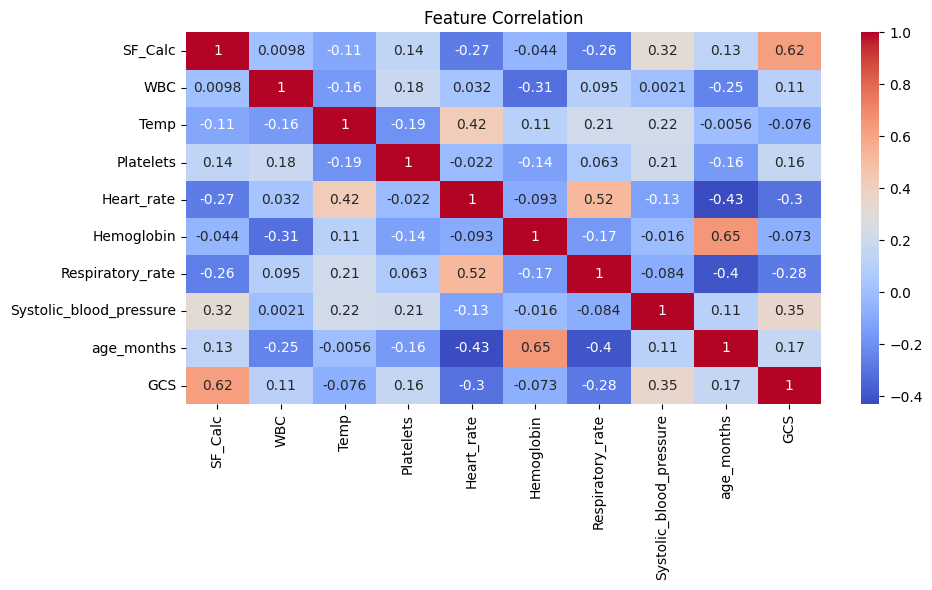

In [ ]:
# =============================================================================
# Clinical + Laboratory Variables  —  SEPSIS detection (REVISED)
# =============================================================================
# This is a drop-in rewrite of one feature-set analysis with the reviewer fixes
# built in. To run the other three analyses, copy this file and change ONLY the
# CONFIG block below:
#   - Non-Lab Sepsis        -> FEATURES = NONLAB_FEATURES ; TARGET = "Sepsis"
#   - Clinical+Lab Shock     -> FEATURES = CLINLAB_FEATURES; TARGET = "Septic_shock"
#   - Non-Lab Septic shock   -> FEATURES = NONLAB_FEATURES ; TARGET = "Septic_shock"
#
# Assumes `df` (the windowed analytic dataframe with one row per 12-h window)
# is already in memory, containing the feature columns, the target column,
# and 'study_id'.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score, brier_score_loss,
                             roc_curve, precision_recall_curve, confusion_matrix)
from sklearn.calibration import (calibration_curve, CalibratedClassifierCV)

# =============================================================================
# CONFIG  (the ONLY block you change between the four analyses)
# =============================================================================
FEATURE_SET_NAME = "Clinical+Lab"
TARGET           = "Sepsis"            # or "Septic_shock"

CLINLAB_FEATURES = ['SF_Calc', 'WBC', 'Temp', 'Platelets', 'Heart_rate', 'Hemoglobin',
                    'Respiratory_rate', 'Systolic_blood_pressure', 'age_months', 'GCS']
NONLAB_FEATURES  = ['SF_Calc', 'Temp', 'Heart_rate', 'Respiratory_rate',
                    'Systolic_blood_pressure', 'age_months', 'GCS']
FEATURES = CLINLAB_FEATURES

READABLE = {
    'SF_Calc': 'SpO2:FiO2 Ratio', 'Heart_rate': 'Heart Rate',
    'Respiratory_rate': 'Respiratory Rate', 'Temp': 'Temperature',
    'Platelets': 'Platelet Count', 'WBC': 'White Blood Cell Count',
    'Hemoglobin': 'Hemoglobin (Hb)', 'Systolic_blood_pressure': 'Systolic Blood Pressure',
    'GCS': 'Glasgow Coma Scale', 'age_months': 'Age (months)',
}

N_SPLITS            = 5
N_REPEATS           = 40         # repeated CV for stable, bounded interval estimates
N_BOOT              = 2000       # patient-level bootstrap iterations (use 200 while testing, 2000 for analysis)
SCREENING_THRESHOLD = 0.30       # high-sensitivity operating point for the screening table
HEADLINE_MODEL      = "Logistic Regression"   # model interpreted in Table 3/4 + main figures
RANDOM_STATE        = 42
COLOR               = "#C00404"

# 1. Build X / y / groups
data = df[FEATURES + [TARGET, 'study_id']].dropna().copy()
data[TARGET] = data[TARGET].astype(int)
X = data[FEATURES].reset_index(drop=True)
y = data[TARGET].reset_index(drop=True)
groups = data['study_id'].reset_index(drop=True)

print(f"=== {FEATURE_SET_NAME} | {TARGET} ===")
print(f"Windows (rows): {len(X)} | Patients: {groups.nunique()}")
print(f"Positive windows: {int(y.sum())} ({100*y.mean():.1f}%)")   # <-- B1: report class balance

plt.figure(figsize=(10, 6))
sns.heatmap(data[FEATURES].corr(), annot=True, cmap='coolwarm'); plt.title("Feature Correlation")
plt.tight_layout(); plt.show()

In [ ]:
# 2. Cross-validation strategy (single + repeated)
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = [list(StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=s)
                  .split(X, y, groups)) for s in range(N_REPEATS)]

In [ ]:

# 3. Helper functions
def pick_threshold_on_train(fitted_model, X_tr, y_tr):
    p_tr = fitted_model.predict_proba(X_tr)[:, 1]
    prec, rec, thr = precision_recall_curve(y_tr, p_tr)
    if len(thr) == 0:
        return 0.5
    f1 = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-8)
    return thr[int(np.argmax(f1))]

def evaluate_repeated_cv(model, threshold=0.5):
    """Run model over all repeated folds.
    threshold: a float (fixed operating point, default 0.5), or "inner" (inner-CV F1-optimal)."""
    out = {k: [] for k in ["accuracy", "f1", "precision", "recall", "auroc", "pr_auc", "brier", "threshold"]}
    for splits in cv_splits:
        for tr, te in splits:
            m = clone(model).fit(X.iloc[tr], y.iloc[tr])
            if threshold == "inner":
                t = _inner_cv_threshold(model, X.iloc[tr], y.iloc[tr], groups.iloc[tr])
            else:
                t = float(threshold)
            p_te = m.predict_proba(X.iloc[te])[:, 1]
            yhat = (p_te >= t).astype(int)
            yte = y.iloc[te]
            out["accuracy"].append(accuracy_score(yte, yhat))
            out["f1"].append(f1_score(yte, yhat, zero_division=0))
            out["precision"].append(precision_score(yte, yhat, zero_division=0))
            out["recall"].append(recall_score(yte, yhat, zero_division=0))
            out["auroc"].append(roc_auc_score(yte, p_te) if yte.nunique() > 1 else np.nan)
            out["pr_auc"].append(average_precision_score(yte, p_te) if yte.nunique() > 1 else np.nan)
            out["brier"].append(brier_score_loss(yte, p_te))
            out["threshold"].append(t)
    return out

def _inner_cv_threshold(model, X_tr, y_tr, g_tr):
    """F1-optimal threshold from out-of-fold predictions WITHIN the training fold."""
    yt, yp = [], []
    inner = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    for itr, ite in inner.split(X_tr, y_tr, groups=g_tr):
        mm = clone(model).fit(X_tr.iloc[itr], y_tr.iloc[itr])
        yp.append(mm.predict_proba(X_tr.iloc[ite])[:, 1]); yt.append(y_tr.iloc[ite].values)
    yt, yp = np.concatenate(yt), np.concatenate(yp)
    prec, rec, thr = precision_recall_curve(yt, yp)
    if len(thr) == 0:
        return 0.5
    f1 = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-8)
    return thr[int(np.argmax(f1))]

def summarize(values):
    """percentile interval (bounded in [0,1], never produces impossible CIs)."""
    v = np.asarray(values, float); v = v[~np.isnan(v)]
    return np.mean(v), np.percentile(v, 2.5), np.percentile(v, 97.5)

def fmt(values):
    m, lo, hi = summarize(values)
    return f"{m:.3f} ({lo:.3f}, {hi:.3f})"

def pooled_oof(model):
    """C1: one repeated-CV pass -> pooled out-of-fold (OOF) labels/probs.
    These OOF probs are the SINGLE SOURCE used by the curves, calibration, and bootstrap."""
    yt, yp = [], []
    for splits in cv_splits:
        for tr, te in splits:
            m = clone(model).fit(X.iloc[tr], y.iloc[tr])
            yp.append(m.predict_proba(X.iloc[te])[:, 1]); yt.append(y.iloc[te].values)
    return np.concatenate(yt), np.concatenate(yp)

def cluster_bootstrap_ci(model, n_boot=N_BOOT, seed=RANDOM_STATE):
    """Threshold-free AUROC/AUPRC/Brier with patient-clustered bootstrap CIs.
    Point = out-of-fold prediction; CI = percentiles over patient resamples of those FIXED preds.
    Returns (results_dict, oof) where oof = (y_true, y_proba, groups) for reuse downstream."""
    yt, yp, g = single_pass_oof(model)
    def thrfree(a, b):
        return (roc_auc_score(a, b), average_precision_score(a, b), brier_score_loss(a, b))
    point = thrfree(yt, yp)
    boots = {0: [], 1: [], 2: []}; n_used = 0
    for ridx in boot_indices(g, n_boot, seed):
        ytb, ypb = yt[ridx], yp[ridx]
        if len(np.unique(ytb)) < 2:
            continue
        a, p, b = thrfree(ytb, ypb)
        boots[0].append(a); boots[1].append(p); boots[2].append(b); n_used += 1
    names = ["AUROC", "AUPRC", "Brier"]
    res = {names[i]: (point[i], np.percentile(boots[i], 2.5), np.percentile(boots[i], 97.5))
           for i in range(3)}
    print(f"  (bootstrap used {n_used}/{n_boot} resamples)")
    return res, (yt, yp, g)

def threshold_report(oof, thresholds, n_boot=N_BOOT, seed=RANDOM_STATE):
    """Confusion-matrix counts + sensitivity/specificity/PPV/NPV at FIXED thresholds,
    each with a patient-clustered bootstrap 95% CI. Counts are real (single OOF pass)."""
    yt, yp, g = oof
    def rates(a, p, t):
        yhat = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(a, yhat, labels=[0, 1]).ravel()
        return (tp/(tp+fn) if (tp+fn) else np.nan, tn/(tn+fp) if (tn+fp) else np.nan,
                tp/(tp+fp) if (tp+fp) else np.nan, tn/(tn+fn) if (tn+fn) else np.nan)
    resamples = list(boot_indices(g, n_boot, seed))
    rows = []
    for t in thresholds:
        pt = rates(yt, yp, t)
        bs = {i: [] for i in range(4)}
        for ridx in resamples:
            r = rates(yt[ridx], yp[ridx], t)
            for i in range(4):
                if not np.isnan(r[i]):
                    bs[i].append(r[i])
        yhat = (yp >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(yt, yhat, labels=[0, 1]).ravel()
        row = {"threshold": round(t, 3), "TP": tp, "FP": fp, "FN": fn, "TN": tn}
        for i, nm in enumerate(["sensitivity", "specificity", "PPV", "NPV"]):
            lo, hi = np.percentile(bs[i], [2.5, 97.5])
            row[nm] = f"{pt[i]:.3f} ({lo:.3f}, {hi:.3f})"
        rows.append(row)
    return pd.DataFrame(rows)

def single_pass_oof(model, seed=RANDOM_STATE):
    """One grouped-CV pass: each row predicted exactly once, out-of-fold (no repeats)."""
    yt = np.empty(len(y)); yp = np.empty(len(y))
    for tr, te in StratifiedGroupKFold(N_SPLITS, shuffle=True, random_state=seed).split(X, y, groups):
        m = clone(model).fit(X.iloc[tr], y.iloc[tr])
        yp[te] = m.predict_proba(X.iloc[te])[:, 1]; yt[te] = y.iloc[te].values
    return yt.astype(int), yp, groups.values

def _all_metrics(yt, yp, thr):
    yhat = (yp >= thr).astype(int); two = len(np.unique(yt)) > 1
    return {'AUROC':     roc_auc_score(yt, yp) if two else np.nan,
            'PR-AUC':    average_precision_score(yt, yp) if two else np.nan,
            'F1':        f1_score(yt, yhat, zero_division=0),
            'Precision': precision_score(yt, yhat, zero_division=0),
            'Recall':    recall_score(yt, yhat, zero_division=0),
            'Brier':     brier_score_loss(yt, yp),
            'Accuracy':  accuracy_score(yt, yhat)}

def bootstrap_all_metrics(model, n_boot=N_BOOT, thr=0.5, seed=RANDOM_STATE):
    """Patient-clustered bootstrap CI for all 7 metrics at a FIXED threshold.
    Point = metric on the out-of-fold predictions; CI = percentiles over patient resamples
    of those FIXED predictions (no refit inside the loop -> no duplicate-across-folds leakage)."""
    yt, yp, g = single_pass_oof(model)
    point = _all_metrics(yt, yp, thr)
    uniq = np.unique(g); rb = np.random.default_rng(seed)
    idx_by_pid = {pid: np.where(g == pid)[0] for pid in uniq}
    boot = {k: [] for k in point}; n_used = 0
    for _ in range(n_boot):
        picked = rb.choice(uniq, size=len(uniq), replace=True)
        ridx = np.concatenate([idx_by_pid[pid] for pid in picked])
        ytb, ypb = yt[ridx], yp[ridx]
        if len(np.unique(ytb)) < 2:
            continue
        for k, v in _all_metrics(ytb, ypb, thr).items():
            boot[k].append(v)
        n_used += 1
    out = {}
    for k in point:
        a = np.array(boot[k], float); a = a[~np.isnan(a)]
        lo, hi = np.percentile(a, [2.5, 97.5])
        out[k] = f"{point[k]:.3f} ({lo:.3f}, {hi:.3f})"
    return out, n_used

def boot_indices(g, n_boot=N_BOOT, seed=RANDOM_STATE):
    """Yield patient-clustered bootstrap row-index arrays (resample study_ids w/ replacement)."""
    uniq = np.unique(g); rb = np.random.default_rng(seed)
    idx_by_pid = {pid: np.where(g == pid)[0] for pid in uniq}
    for _ in range(n_boot):
        picked = rb.choice(uniq, size=len(uniq), replace=True)
        yield np.concatenate([idx_by_pid[pid] for pid in picked])

In [ ]:
pip install optuna

In [ ]:

# 4. Hyperparameter optimization (Optuna)
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 50

def optimize_model(model_name):
    def objective(trial):
        if model_name == 'Random Forest':
            clf = make_pipeline(StandardScaler(), RandomForestClassifier(
                n_estimators=trial.suggest_int('n_estimators', 100, 300),
                max_depth=trial.suggest_int('max_depth', 3, 20),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
                class_weight='balanced', random_state=RANDOM_STATE))
        elif model_name == 'Decision Tree':
            clf = make_pipeline(StandardScaler(), DecisionTreeClassifier(
                max_depth=trial.suggest_int('max_depth', 3, 20),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
                class_weight='balanced', random_state=RANDOM_STATE))
        elif model_name == 'SVM':
            clf = make_pipeline(StandardScaler(), CalibratedClassifierCV(
                SVC(kernel='linear',
                    C=trial.suggest_float('C', 0.01, 10, log=True),
                    class_weight='balanced', random_state=RANDOM_STATE),
                method='sigmoid', cv=3))
        elif model_name == 'Kernel SVM':
            clf = make_pipeline(StandardScaler(), CalibratedClassifierCV(
                SVC(kernel='rbf',
                    C=trial.suggest_float('C', 0.01, 10, log=True),
                    gamma=trial.suggest_categorical('gamma', ['scale', 'auto']),
                    class_weight='balanced', random_state=RANDOM_STATE),
                method='sigmoid', cv=3))
        elif model_name == 'Naive Bayes':
            clf = make_pipeline(StandardScaler(), GaussianNB(
                var_smoothing=trial.suggest_float('var_smoothing', 1e-9, 1e-7, log=True)))
        elif model_name == 'KNN':
            clf = make_pipeline(StandardScaler(), KNeighborsClassifier(
                n_neighbors=trial.suggest_int('n_neighbors', 1, 20),
                weights=trial.suggest_categorical('weights', ['uniform', 'distance']),
                p=trial.suggest_categorical('p', [1, 2])))
        elif model_name == 'Logistic Regression':
            clf = make_pipeline(StandardScaler(), LogisticRegression(
                C=trial.suggest_float('C', 0.01, 10, log=True),
                solver=trial.suggest_categorical('solver', ['lbfgs', 'saga']),
                class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
        else:
            raise ValueError("Model not recognized.")
        return cross_val_score(clf, X, y, cv=cv, groups=groups,
                               scoring='average_precision', n_jobs=-1).mean()
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=N_TRIALS)
    print(f"Best {model_name} params: {study.best_params}")
    return study.best_params

model_names = ['Decision Tree', 'Random Forest', 'SVM', 'Kernel SVM',
               'Naive Bayes', 'KNN', 'Logistic Regression']
best_params_dict = {}
for name in model_names:
    print(f"Optimizing {name}...")
    best_params_dict[name] = optimize_model(name)

hyperparam_table = (pd.DataFrame(best_params_dict).T.reset_index().rename(columns={"index": "Model"}))



Optimizing Decision Tree...
Best Decision Tree params: {'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 5}
Optimizing Random Forest...
Best Random Forest params: {'n_estimators': 167, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 1}
Optimizing SVM...
Best SVM params: {'C': 0.14185243240727008}
Optimizing Kernel SVM...
Best Kernel SVM params: {'C': 9.788353565330256, 'gamma': 'auto'}
Optimizing Naive Bayes...
Best Naive Bayes params: {'var_smoothing': 2.2831482146782617e-08}
Optimizing KNN...
Best KNN params: {'n_neighbors': 7, 'weights': 'distance', 'p': 1}
Optimizing Logistic Regression...
Best Logistic Regression params: {'C': 6.614454870970489, 'solver': 'lbfgs'}


In [ ]:
# 5. Build models (all pipelines -> scaling handled inside CV, no manual scaling)
def build_models(bp):
    return {
        'Decision Tree': make_pipeline(StandardScaler(), DecisionTreeClassifier(
            **bp.get('Decision Tree', {}), class_weight='balanced', random_state=RANDOM_STATE)),
        'Random Forest': make_pipeline(StandardScaler(), RandomForestClassifier(
            **bp.get('Random Forest', {}), class_weight='balanced', random_state=RANDOM_STATE)),
        'SVM': make_pipeline(StandardScaler(), CalibratedClassifierCV(
            SVC(kernel='linear', **bp.get('SVM', {}),
                class_weight='balanced', random_state=RANDOM_STATE),
            method='sigmoid', cv=3)),
        'Kernel SVM': make_pipeline(StandardScaler(), CalibratedClassifierCV(
            SVC(kernel='rbf', **bp.get('Kernel SVM', {}),
                class_weight='balanced', random_state=RANDOM_STATE),
            method='sigmoid', cv=3)),
        'Naive Bayes': make_pipeline(StandardScaler(), GaussianNB(**bp.get('Naive Bayes', {}))),
        'KNN': make_pipeline(StandardScaler(), KNeighborsClassifier(**bp.get('KNN', {}))),
        'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(
            **bp.get('Logistic Regression', {}), class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE)),
    }
models = build_models(best_params_dict)

In [ ]:
# # 6. Model comparison table  (repeated CV + percentile CIs + train-only threshold)
# #    -> Supplemental Table. No test-set threshold tuning; CIs cannot exceed [0,1].
# cv_results = {'Model': [], 'Accuracy (95% CI)': [], 'F1 Score (95% CI)': [],
#               'AUROC (95% CI)': [], 'PR-AUC (95% CI)': [], 'Brier (95% CI)': [],
#               'Precision (95% CI)': [], 'Recall (95% CI)': []}
# for name, model in models.items():
#     r = evaluate_repeated_cv(model)
#     cv_results['Model'].append(name)
#     cv_results['Accuracy (95% CI)'].append(fmt(r['accuracy']))
#     cv_results['F1 Score (95% CI)'].append(fmt(r['f1']))
#     cv_results['Precision (95% CI)'].append(fmt(r['precision']))
#     cv_results['Recall (95% CI)'].append(fmt(r['recall']))
#     cv_results['AUROC (95% CI)'].append(fmt(r['auroc']))
#     cv_results['PR-AUC (95% CI)'].append(fmt(r['pr_auc']))
#     cv_results['Brier (95% CI)'].append(fmt(r['brier']))
# cv_results_df = pd.DataFrame(cv_results)
# print("\n--- Model comparison (repeated CV, percentile CIs) ---")
# print(cv_results_df.to_string(index=False))

In [ ]:
# 6. Model comparison table — patient-level bootstrap 95% CIs at a fixed 0.5 threshold
#    Point estimate = out-of-fold prediction; CIs = patient-clustered percentile bootstrap.
metric_order = ['AUROC', 'PR-AUC', 'F1', 'Precision', 'Recall', 'Brier', 'Accuracy']
rows6 = []
for name, model in models.items():
    res, n_used = bootstrap_all_metrics(model, n_boot=N_BOOT, thr=0.5)
    rows6.append({'Model': name, **{f'{k} (95% CI)': res[k] for k in metric_order}})
cv_results_df = pd.DataFrame(rows6)
print(f"\n--- Model comparison (patient-level bootstrap CIs, threshold = 0.50; {n_used} resamples) ---")
print(cv_results_df.to_string(index=False))


--- Model comparison (patient-level bootstrap CIs, threshold = 0.50; 2000 resamples) ---
              Model       AUROC (95% CI)      PR-AUC (95% CI)          F1 (95% CI)   Precision (95% CI)      Recall (95% CI)       Brier (95% CI)    Accuracy (95% CI)
      Decision Tree 0.880 (0.804, 0.944) 0.848 (0.740, 0.934) 0.744 (0.623, 0.841) 0.763 (0.615, 0.891) 0.725 (0.581, 0.857) 0.124 (0.076, 0.178) 0.800 (0.720, 0.870)
      Random Forest 0.970 (0.936, 0.995) 0.966 (0.925, 0.993) 0.909 (0.829, 0.971) 0.946 (0.857, 1.000) 0.875 (0.758, 0.972) 0.078 (0.055, 0.106) 0.930 (0.870, 0.980)
                SVM 0.960 (0.920, 0.987) 0.947 (0.891, 0.983) 0.833 (0.722, 0.921) 0.938 (0.839, 1.000) 0.750 (0.600, 0.875) 0.092 (0.066, 0.121) 0.880 (0.810, 0.940)
         Kernel SVM 0.946 (0.900, 0.982) 0.920 (0.841, 0.975) 0.831 (0.725, 0.915) 0.865 (0.743, 0.971) 0.800 (0.659, 0.919) 0.101 (0.074, 0.130) 0.870 (0.800, 0.930)
        Naive Bayes 0.920 (0.849, 0.969) 0.912 (0.829, 0.962) 0.815 (0.706,

In [ ]:
# 6b. Idealized comparison — inner-CV F1-optimal threshold (leakage-free, train-only)
#     AUROC/PR-AUC are threshold-free so identical to the table above; we show only the
#     threshold-dependent metrics plus the mean operating point selected per fold.
opt_results = {}
rows_opt = []
for name, model in models.items():
    r = evaluate_repeated_cv(model, threshold="inner")
    opt_results[name] = r
    rows_opt.append({'Model': name,
                     'Threshold (mean 95% CI)': fmt(r['threshold']),
                     'Accuracy (95% CI)': fmt(r['accuracy']),
                     'F1 Score (95% CI)': fmt(r['f1']),
                     'Precision (95% CI)': fmt(r['precision']),
                     'Recall (95% CI)': fmt(r['recall'])})
cv_results_opt_df = pd.DataFrame(rows_opt)
print("\n--- Model comparison (repeated CV, inner-CV F1-optimal threshold) ---")
print(cv_results_opt_df.to_string(index=False))


--- Model comparison (repeated CV, inner-CV F1-optimal threshold) ---
              Model Threshold (mean 95% CI)    Accuracy (95% CI)    F1 Score (95% CI)   Precision (95% CI)      Recall (95% CI)
      Decision Tree    0.814 (0.322, 1.000) 0.874 (0.700, 1.000) 0.823 (0.570, 1.000) 0.909 (0.571, 1.000) 0.776 (0.500, 1.000)
      Random Forest    0.529 (0.309, 0.662) 0.906 (0.750, 1.000) 0.871 (0.667, 1.000) 0.949 (0.599, 1.000) 0.821 (0.554, 1.000)
                SVM    0.382 (0.249, 0.548) 0.839 (0.699, 0.950) 0.801 (0.571, 0.957) 0.778 (0.500, 1.000) 0.856 (0.499, 1.000)
         Kernel SVM    0.451 (0.305, 0.592) 0.866 (0.749, 1.000) 0.828 (0.615, 1.000) 0.831 (0.500, 1.000) 0.852 (0.583, 1.000)
        Naive Bayes    0.479 (0.045, 0.955) 0.834 (0.650, 0.950) 0.783 (0.570, 0.952) 0.806 (0.500, 1.000) 0.793 (0.444, 1.000)
                KNN    0.415 (0.269, 0.576) 0.866 (0.700, 1.000) 0.830 (0.600, 1.000) 0.836 (0.500, 1.000) 0.850 (0.571, 1.000)
Logistic Regression    0.453 (0.0

In [ ]:
# 6c. Optimism-corrected internal validation (Harrell/Steyerberg bootstrap)
#     Quantifies over-optimism: how much APPARENT (in-sample) performance overstates
#     performance on new patients. Patient-clustered to match the rest of the pipeline.
#     "m-index" == c-index == AUROC.
def optimism_bootstrap(model, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    uniq = np.asarray(pd.unique(groups))
    def sc(yt, p):
        return np.array([roc_auc_score(yt, p),
                         average_precision_score(yt, p),
                         brier_score_loss(yt, p)])
    # Apparent performance: fit on all data, evaluate on the same data
    m_app = clone(model).fit(X, y)
    apparent = sc(y, m_app.predict_proba(X)[:, 1])
    opt, n_used = [], 0
    for _ in range(n_boot):
        picked = rng.choice(uniq, size=len(uniq), replace=True)              # resample PATIENTS
        ridx = np.concatenate([np.where(groups.values == pid)[0] for pid in picked])
        Xb, yb = X.iloc[ridx], y.iloc[ridx]
        if yb.nunique() < 2:
            continue
        m_b = clone(model).fit(Xb, yb)
        boot = sc(yb, m_b.predict_proba(Xb)[:, 1])   # performance where it was trained
        test = sc(y,  m_b.predict_proba(X)[:, 1])    # same model on the ORIGINAL sample
        opt.append(boot - test); n_used += 1
    optimism = np.mean(opt, axis=0)
    corrected = apparent - optimism                  # works for Brier too (sign cancels)
    return apparent, optimism, corrected, n_used

opt_rows = []
for name, model in models.items():
    app, optm, corr, nb = optimism_bootstrap(model)
    opt_rows.append({'Model': name,
                     'Apparent AUROC': round(app[0], 3),
                     'Optimism': round(optm[0], 3),
                     'Optimism-corrected AUROC': round(corr[0], 3),
                     'Corrected AUPRC': round(corr[1], 3),
                     'Corrected Brier': round(corr[2], 3)})
optimism_df = pd.DataFrame(opt_rows)
print(f"\n--- Optimism-corrected internal validation (patient bootstrap, {nb} resamples) ---")
print(optimism_df.to_string(index=False))


--- Optimism-corrected internal validation (patient bootstrap, 2000 resamples) ---
              Model  Apparent AUROC  Optimism  Optimism-corrected AUROC  Corrected AUPRC  Corrected Brier
      Decision Tree           0.990     0.045                     0.945            0.910            0.083
      Random Forest           1.000     0.007                     0.993            0.992            0.045
                SVM           0.975     0.019                     0.956            0.943            0.098
         Kernel SVM           1.000     0.012                     0.988            0.982            0.064
        Naive Bayes           0.946     0.025                     0.921            0.918            0.110
                KNN           1.000     0.013                     0.987            0.983            0.038
Logistic Regression           0.980     0.028                     0.952            0.940            0.092


In [ ]:
# 7. Headline model (Logistic Regression) — patient-level bootstrap + fixed-threshold table
#    These are the numbers that go in Table 3 AND on the figures (single source of truth).
best_model_name = HEADLINE_MODEL
best_model = models[best_model_name]

OPT_THRESHOLD = float(np.mean(opt_results[HEADLINE_MODEL]['threshold']))
print(f"\nF1-optimal threshold (inner-CV, headline model): {OPT_THRESHOLD:.3f}")

print(f"\n--- Headline model: {best_model_name} ---")
boot_ci, oof = cluster_bootstrap_ci(best_model, n_boot=N_BOOT)
for k, (pt, lo, hi) in boot_ci.items():
    print(f"  {k}: {pt:.3f} ({lo:.3f}, {hi:.3f})  [patient-level bootstrap]")

# single source of truth for every figure below
y_true_all, y_proba_all, _ = oof

# fixed-threshold table, now with bootstrap CIs on sens/spec/PPV/NPV
thr_table = threshold_report(oof, thresholds=(0.5, OPT_THRESHOLD, SCREENING_THRESHOLD), n_boot=N_BOOT)
print("\n--- Fixed-threshold performance (out-of-fold, bootstrap CIs) ---")
print(thr_table.to_string(index=False))


F1-optimal threshold (inner-CV, headline model): 0.453

--- Headline model: Logistic Regression ---
  (bootstrap used 2000/2000 resamples)
  AUROC: 0.945 (0.881, 0.986)  [patient-level bootstrap]
  AUPRC: 0.941 (0.880, 0.981)  [patient-level bootstrap]
  Brier: 0.086 (0.049, 0.132)  [patient-level bootstrap]

--- Fixed-threshold performance (out-of-fold, bootstrap CIs) ---
 threshold  TP  FP  FN  TN          sensitivity          specificity                  PPV                  NPV
     0.500  33   6   7  54 0.825 (0.698, 0.931) 0.900 (0.814, 0.967) 0.846 (0.722, 0.947) 0.885 (0.797, 0.955)
     0.453  33   6   7  54 0.825 (0.698, 0.931) 0.900 (0.814, 0.967) 0.846 (0.722, 0.947) 0.885 (0.797, 0.955)
     0.300  36   9   4  51 0.900 (0.795, 0.977) 0.850 (0.754, 0.935) 0.800 (0.680, 0.911) 0.927 (0.852, 0.983)


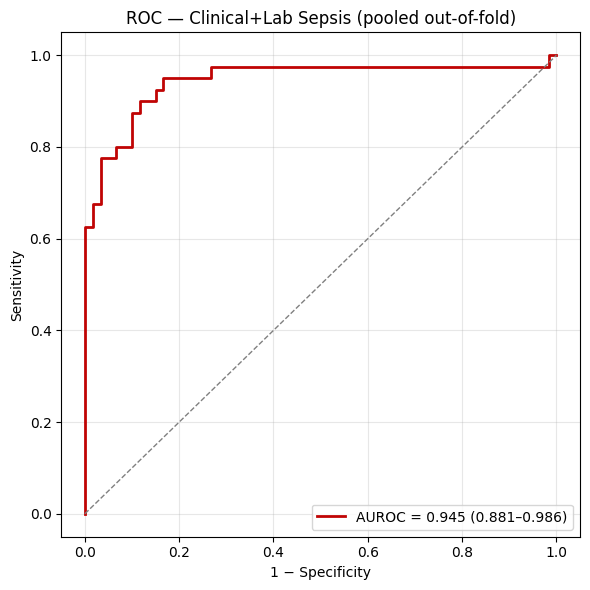

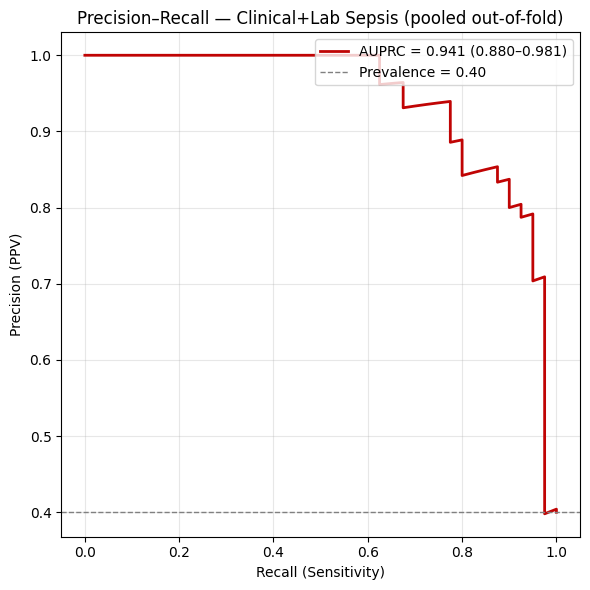

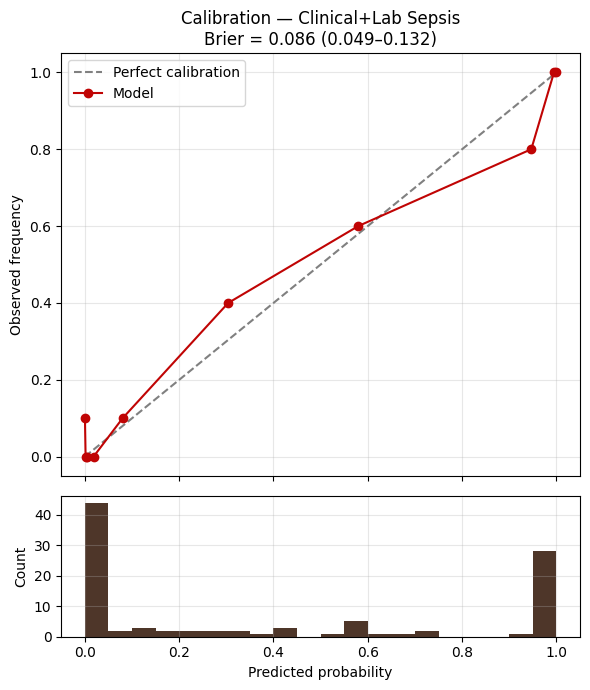

In [ ]:
# 8. FIGURES  (all driven by the same pooled-OOF arrays + bootstrap CIs)
auroc_pt, auroc_lo, auroc_hi = boot_ci["AUROC"]
prauc_pt, prauc_lo, prauc_hi = boot_ci["AUPRC"]
brier_pt, brier_lo, brier_hi = boot_ci["Brier"]
prevalence = y_true_all.mean()

# --- 8a. ROC (label = same value as the table) -------------------------------
fpr, tpr, _ = roc_curve(y_true_all, y_proba_all)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color=COLOR, lw=2,
         label=f"AUROC = {auroc_pt:.3f} ({auroc_lo:.3f}\u2013{auroc_hi:.3f})")
plt.plot([0, 1], [0, 1], '--', color="gray", lw=1)
plt.xlabel("1 \u2212 Specificity"); plt.ylabel("Sensitivity")
plt.title(f"ROC \u2014 {FEATURE_SET_NAME} {TARGET} (pooled out-of-fold)")
plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"ROC_{FEATURE_SET_NAME}_{TARGET}.png", dpi=300, bbox_inches="tight"); plt.show()

# --- 8b. Precision-Recall (with prevalence baseline) -------------------------
prec, rec, _ = precision_recall_curve(y_true_all, y_proba_all)
plt.figure(figsize=(6, 6))
plt.plot(rec, prec, color=COLOR, lw=2,
         label=f"AUPRC = {prauc_pt:.3f} ({prauc_lo:.3f}\u2013{prauc_hi:.3f})")
plt.axhline(prevalence, ls='--', color="gray", lw=1, label=f"Prevalence = {prevalence:.2f}")
plt.xlabel("Recall (Sensitivity)"); plt.ylabel("Precision (PPV)")
plt.title(f"Precision\u2013Recall \u2014 {FEATURE_SET_NAME} {TARGET} (pooled out-of-fold)")
plt.legend(loc="upper right"); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"PR_{FEATURE_SET_NAME}_{TARGET}.png", dpi=300, bbox_inches="tight"); plt.show()

# --- 8c. Calibration (pooled OOF, not in-sample) + probability histogram ------
prob_true, prob_pred = calibration_curve(y_true_all, y_proba_all, n_bins=10, strategy="quantile")
fig, (a1, a2) = plt.subplots(2, 1, figsize=(6, 7), height_ratios=[3, 1], sharex=True)
a1.plot([0, 1], [0, 1], '--', color="gray", label="Perfect calibration")
a1.plot(prob_pred, prob_true, 'o-', color=COLOR, label="Model")
a1.set_ylabel("Observed frequency"); a1.legend(loc="upper left"); a1.grid(alpha=0.3)
a1.set_title(f"Calibration \u2014 {FEATURE_SET_NAME} {TARGET}\n"
             f"Brier = {brier_pt:.3f} ({brier_lo:.3f}\u2013{brier_hi:.3f})")
a2.hist(y_proba_all, bins=20, color="#4E3629")
a2.set_xlabel("Predicted probability"); a2.set_ylabel("Count"); a2.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"Calibration_{FEATURE_SET_NAME}_{TARGET}.png", dpi=300, bbox_inches="tight"); plt.show()



--- Standardized logistic regression coefficients (Table 4) ---
                Feature  Coefficient (log-odds)  Coef 2.5%  Coef 97.5%  Odds Ratio (per 1 SD)  OR 2.5%  OR 97.5%
        SpO2:FiO2 Ratio                  -2.783     -4.270      -1.297                  0.062    0.014     0.273
     Glasgow Coma Scale                  -1.596     -2.874      -0.318                  0.203    0.056     0.728
Systolic Blood Pressure                  -1.561     -3.156       0.034                  0.210    0.043     1.035
         Platelet Count                  -0.984     -2.026       0.058                  0.374    0.132     1.059
           Age (months)                   0.871     -0.506       2.248                  2.389    0.603     9.467
             Heart Rate                   0.689     -0.314       1.691                  1.991    0.731     5.423
 White Blood Cell Count                  -0.639     -1.584       0.306                  0.528    0.205     1.358
            Temperature        

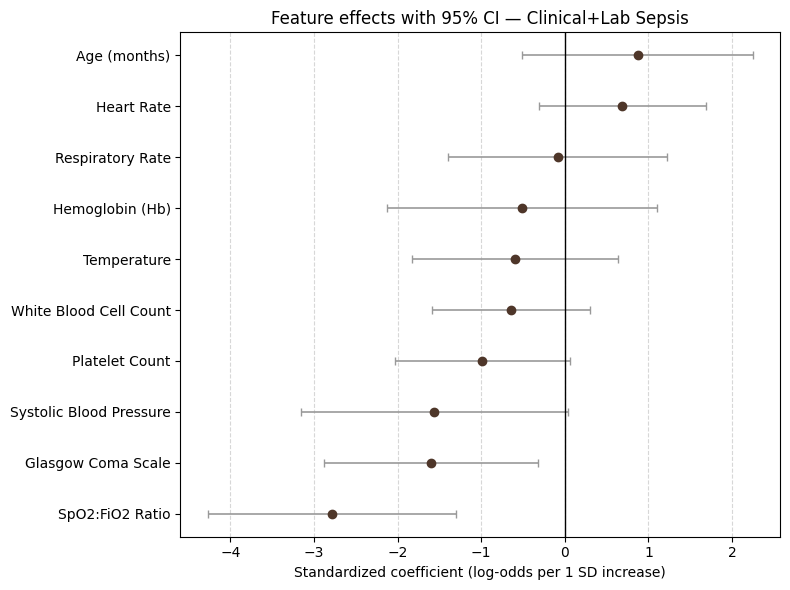


logit(p) = -0.335 + (-2.783 × SpO2:FiO2 Ratio) + (-0.639 × White Blood Cell Count) + (-0.598 × Temperature) + (-0.984 × Platelet Count) + (0.689 × Heart Rate) + (-0.508 × Hemoglobin (Hb)) + (-0.086 × Respiratory Rate) + (-1.561 × Systolic Blood Pressure) + (0.871 × Age (months)) + (-1.596 × Glasgow Coma Scale)


In [ ]:
# 9. Standardized logistic regression: coefficients, ORs, 95% CI  (Table 4)
#    Wald CIs feed BOTH the table and the forest plot (single source of truth).
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
lr_params = best_params_dict.get('Logistic Regression', {})
final_lr = LogisticRegression(**lr_params, class_weight="balanced",
                              max_iter=1000, random_state=RANDOM_STATE).fit(X_std, y)

# Wald covariance for CIs
Xd = np.column_stack([np.ones(X_std.shape[0]), X_std])
p_hat = final_lr.predict_proba(X_std)[:, 1]
W = np.diag(p_hat * (1 - p_hat))
cov = np.linalg.inv(Xd.T @ W @ Xd)
coef = final_lr.coef_[0]
se = np.sqrt(np.diag(cov))[1:]
coef_lo, coef_hi = coef - 1.96 * se, coef + 1.96 * se

coef_df = pd.DataFrame({
    "Feature": [READABLE.get(f, f) for f in FEATURES],
    "Coefficient (log-odds)": coef,
    "Coef 2.5%": coef_lo, "Coef 97.5%": coef_hi,
    "Odds Ratio (per 1 SD)": np.exp(coef),
    "OR 2.5%": np.exp(coef_lo), "OR 97.5%": np.exp(coef_hi),
}).sort_values("Coefficient (log-odds)", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
coef_df_pub = coef_df.round(3)
print("\n--- Standardized logistic regression coefficients (Table 4) ---")
print(coef_df_pub.to_string(index=False))
coef_df_pub.to_csv(f"{FEATURE_SET_NAME}_{TARGET}_logreg_coefficients.csv", index=False)

# --- 9b. Coefficient FOREST plot with 95% CI (C2 fix: no false precision) -----
pdf = coef_df.sort_values("Coefficient (log-odds)").reset_index(drop=True)
plt.figure(figsize=(8, 6))
xerr = [pdf["Coefficient (log-odds)"] - pdf["Coef 2.5%"],
        pdf["Coef 97.5%"] - pdf["Coefficient (log-odds)"]]
plt.errorbar(pdf["Coefficient (log-odds)"], range(len(pdf)), xerr=xerr,
             fmt='o', color="#4E3629", ecolor="#999999", capsize=3, lw=1.2)
plt.axvline(0, color="black", lw=1)
plt.yticks(range(len(pdf)), pdf["Feature"])
plt.xlabel("Standardized coefficient (log-odds per 1 SD increase)")
plt.title(f"Feature effects with 95% CI \u2014 {FEATURE_SET_NAME} {TARGET}")
plt.grid(axis='x', ls='--', alpha=0.5); plt.tight_layout()
plt.savefig(f"Coefficients_{FEATURE_SET_NAME}_{TARGET}.png", dpi=300, bbox_inches="tight"); plt.show()

# --- 9c. Logistic regression equation (Supplemental Table 3) ------------------
intercept = final_lr.intercept_[0]
equation = f"logit(p) = {intercept:.3f} + " + " + ".join(
    f"({c:.3f} \u00D7 {READABLE.get(f, f)})" for c, f in zip(coef, FEATURES))
print("\n" + equation)

In [ ]:

# 10. Exports
cv_results_df.to_csv(f"{FEATURE_SET_NAME}_{TARGET}_model_comparison.csv", index=False)
hyperparam_table.to_csv(f"{FEATURE_SET_NAME}_{TARGET}_hyperparameters.csv", index=False)
thr_table.to_csv(f"{FEATURE_SET_NAME}_{TARGET}_fixed_threshold_metrics.csv", index=False)
cv_results_opt_df.to_csv(f"{FEATURE_SET_NAME}_{TARGET}_inner_cv_threshold_metrics.csv", index=False)
pd.DataFrame([{"metric": k, "point": v[0], "lo95": v[1], "hi95": v[2]}
              for k, v in boot_ci.items()]).to_csv(
              f"{FEATURE_SET_NAME}_{TARGET}_bootstrap_CIs.csv", index=False)
pd.DataFrame([{"Feature Set": FEATURE_SET_NAME, "Outcome": TARGET,
               "Intercept": intercept, "Model Specification": equation}]
            ).to_csv(f"{FEATURE_SET_NAME}_{TARGET}_equation.csv", index=False)
print("\nDone.")


Done.


##Clinical Only Sepsis

=== Clinical | Sepsis ===
Windows (rows): 100 | Patients: 100
Positive windows: 40 (40.0%)


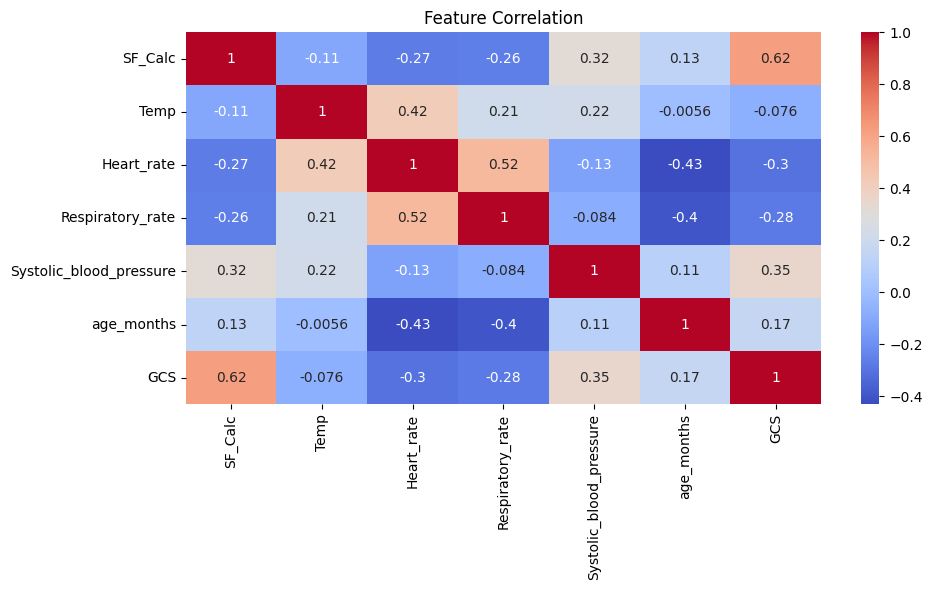

In [ ]:
# =============================================================================
# Clinical + Laboratory Variables  —  SEPSIS detection (REVISED)
# =============================================================================
# This is a drop-in rewrite of one feature-set analysis with the reviewer fixes
# built in. To run the other three analyses, copy this file and change ONLY the
# CONFIG block below:
#   - Non-Lab Sepsis        -> FEATURES = NONLAB_FEATURES ; TARGET = "Sepsis"
#   - Clinical+Lab Shock     -> FEATURES = CLINLAB_FEATURES; TARGET = "Septic_shock"
#   - Non-Lab Septic shock   -> FEATURES = NONLAB_FEATURES ; TARGET = "Septic_shock"
#
# Assumes `df` (the windowed analytic dataframe with one row per 12-h window)
# is already in memory, containing the feature columns, the target column,
# and 'study_id'.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score, brier_score_loss,
                             roc_curve, precision_recall_curve, confusion_matrix)
from sklearn.calibration import (calibration_curve, CalibratedClassifierCV)

# =============================================================================
# CONFIG  (the ONLY block you change between the four analyses)
# =============================================================================
FEATURE_SET_NAME = "Clinical"
TARGET           = "Sepsis"            # or "Septic_shock"

CLINLAB_FEATURES = ['SF_Calc', 'WBC', 'Temp', 'Platelets', 'Heart_rate', 'Hemoglobin',
                    'Respiratory_rate', 'Systolic_blood_pressure', 'age_months', 'GCS']
NONLAB_FEATURES  = ['SF_Calc', 'Temp', 'Heart_rate', 'Respiratory_rate',
                    'Systolic_blood_pressure', 'age_months', 'GCS']
FEATURES = NONLAB_FEATURES

READABLE = {
    'SF_Calc': 'SpO2:FiO2 Ratio', 'Heart_rate': 'Heart Rate',
    'Respiratory_rate': 'Respiratory Rate', 'Temp': 'Temperature',
    'Platelets': 'Platelet Count', 'WBC': 'White Blood Cell Count',
    'Hemoglobin': 'Hemoglobin (Hb)', 'Systolic_blood_pressure': 'Systolic Blood Pressure',
    'GCS': 'Glasgow Coma Scale', 'age_months': 'Age (months)',
}

N_SPLITS            = 5
N_REPEATS           = 40         # repeated CV for stable, bounded interval estimates
N_BOOT              = 2000       # patient-level bootstrap iterations (use 200 while testing, 2000 for analysis)
SCREENING_THRESHOLD = 0.30       # high-sensitivity operating point for the screening table
HEADLINE_MODEL      = "Logistic Regression"   # model interpreted in Table 3/4 + main figures
RANDOM_STATE        = 42
COLOR               = "#C00404"

# 1. Build X / y / groups
data = df[FEATURES + [TARGET, 'study_id']].dropna().copy()
data[TARGET] = data[TARGET].astype(int)
X = data[FEATURES].reset_index(drop=True)
y = data[TARGET].reset_index(drop=True)
groups = data['study_id'].reset_index(drop=True)

print(f"=== {FEATURE_SET_NAME} | {TARGET} ===")
print(f"Windows (rows): {len(X)} | Patients: {groups.nunique()}")
print(f"Positive windows: {int(y.sum())} ({100*y.mean():.1f}%)")   # <-- B1: report class balance

plt.figure(figsize=(10, 6))
sns.heatmap(data[FEATURES].corr(), annot=True, cmap='coolwarm'); plt.title("Feature Correlation")
plt.tight_layout(); plt.show()

In [ ]:
# 2. Cross-validation strategy (single + repeated)
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = [list(StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=s)
                  .split(X, y, groups)) for s in range(N_REPEATS)]

In [ ]:

# 3. Helper functions
def pick_threshold_on_train(fitted_model, X_tr, y_tr):
    p_tr = fitted_model.predict_proba(X_tr)[:, 1]
    prec, rec, thr = precision_recall_curve(y_tr, p_tr)
    if len(thr) == 0:
        return 0.5
    f1 = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-8)
    return thr[int(np.argmax(f1))]

def evaluate_repeated_cv(model, threshold=0.5):
    """Run model over all repeated folds.
    threshold: a float (fixed operating point, default 0.5), or "inner" (inner-CV F1-optimal)."""
    out = {k: [] for k in ["accuracy", "f1", "precision", "recall", "auroc", "pr_auc", "brier", "threshold"]}
    for splits in cv_splits:
        for tr, te in splits:
            m = clone(model).fit(X.iloc[tr], y.iloc[tr])
            if threshold == "inner":
                t = _inner_cv_threshold(model, X.iloc[tr], y.iloc[tr], groups.iloc[tr])
            else:
                t = float(threshold)
            p_te = m.predict_proba(X.iloc[te])[:, 1]
            yhat = (p_te >= t).astype(int)
            yte = y.iloc[te]
            out["accuracy"].append(accuracy_score(yte, yhat))
            out["f1"].append(f1_score(yte, yhat, zero_division=0))
            out["precision"].append(precision_score(yte, yhat, zero_division=0))
            out["recall"].append(recall_score(yte, yhat, zero_division=0))
            out["auroc"].append(roc_auc_score(yte, p_te) if yte.nunique() > 1 else np.nan)
            out["pr_auc"].append(average_precision_score(yte, p_te) if yte.nunique() > 1 else np.nan)
            out["brier"].append(brier_score_loss(yte, p_te))
            out["threshold"].append(t)
    return out

def _inner_cv_threshold(model, X_tr, y_tr, g_tr):
    """F1-optimal threshold from out-of-fold predictions WITHIN the training fold."""
    yt, yp = [], []
    inner = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    for itr, ite in inner.split(X_tr, y_tr, groups=g_tr):
        mm = clone(model).fit(X_tr.iloc[itr], y_tr.iloc[itr])
        yp.append(mm.predict_proba(X_tr.iloc[ite])[:, 1]); yt.append(y_tr.iloc[ite].values)
    yt, yp = np.concatenate(yt), np.concatenate(yp)
    prec, rec, thr = precision_recall_curve(yt, yp)
    if len(thr) == 0:
        return 0.5
    f1 = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-8)
    return thr[int(np.argmax(f1))]

def summarize(values):
    """percentile interval (bounded in [0,1], never produces impossible CIs)."""
    v = np.asarray(values, float); v = v[~np.isnan(v)]
    return np.mean(v), np.percentile(v, 2.5), np.percentile(v, 97.5)

def fmt(values):
    m, lo, hi = summarize(values)
    return f"{m:.3f} ({lo:.3f}, {hi:.3f})"

def pooled_oof(model):
    """C1: one repeated-CV pass -> pooled out-of-fold (OOF) labels/probs.
    These OOF probs are the SINGLE SOURCE used by the curves, calibration, and bootstrap."""
    yt, yp = [], []
    for splits in cv_splits:
        for tr, te in splits:
            m = clone(model).fit(X.iloc[tr], y.iloc[tr])
            yp.append(m.predict_proba(X.iloc[te])[:, 1]); yt.append(y.iloc[te].values)
    return np.concatenate(yt), np.concatenate(yp)

def cluster_bootstrap_ci(model, n_boot=N_BOOT, seed=RANDOM_STATE):
    """Threshold-free AUROC/AUPRC/Brier with patient-clustered bootstrap CIs.
    Point = out-of-fold prediction; CI = percentiles over patient resamples of those FIXED preds.
    Returns (results_dict, oof) where oof = (y_true, y_proba, groups) for reuse downstream."""
    yt, yp, g = single_pass_oof(model)
    def thrfree(a, b):
        return (roc_auc_score(a, b), average_precision_score(a, b), brier_score_loss(a, b))
    point = thrfree(yt, yp)
    boots = {0: [], 1: [], 2: []}; n_used = 0
    for ridx in boot_indices(g, n_boot, seed):
        ytb, ypb = yt[ridx], yp[ridx]
        if len(np.unique(ytb)) < 2:
            continue
        a, p, b = thrfree(ytb, ypb)
        boots[0].append(a); boots[1].append(p); boots[2].append(b); n_used += 1
    names = ["AUROC", "AUPRC", "Brier"]
    res = {names[i]: (point[i], np.percentile(boots[i], 2.5), np.percentile(boots[i], 97.5))
           for i in range(3)}
    print(f"  (bootstrap used {n_used}/{n_boot} resamples)")
    return res, (yt, yp, g)

def threshold_report(oof, thresholds, n_boot=N_BOOT, seed=RANDOM_STATE):
    """Confusion-matrix counts + sensitivity/specificity/PPV/NPV at FIXED thresholds,
    each with a patient-clustered bootstrap 95% CI. Counts are real (single OOF pass)."""
    yt, yp, g = oof
    def rates(a, p, t):
        yhat = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(a, yhat, labels=[0, 1]).ravel()
        return (tp/(tp+fn) if (tp+fn) else np.nan, tn/(tn+fp) if (tn+fp) else np.nan,
                tp/(tp+fp) if (tp+fp) else np.nan, tn/(tn+fn) if (tn+fn) else np.nan)
    resamples = list(boot_indices(g, n_boot, seed))
    rows = []
    for t in thresholds:
        pt = rates(yt, yp, t)
        bs = {i: [] for i in range(4)}
        for ridx in resamples:
            r = rates(yt[ridx], yp[ridx], t)
            for i in range(4):
                if not np.isnan(r[i]):
                    bs[i].append(r[i])
        yhat = (yp >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(yt, yhat, labels=[0, 1]).ravel()
        row = {"threshold": round(t, 3), "TP": tp, "FP": fp, "FN": fn, "TN": tn}
        for i, nm in enumerate(["sensitivity", "specificity", "PPV", "NPV"]):
            lo, hi = np.percentile(bs[i], [2.5, 97.5])
            row[nm] = f"{pt[i]:.3f} ({lo:.3f}, {hi:.3f})"
        rows.append(row)
    return pd.DataFrame(rows)

def single_pass_oof(model, seed=RANDOM_STATE):
    """One grouped-CV pass: each row predicted exactly once, out-of-fold (no repeats)."""
    yt = np.empty(len(y)); yp = np.empty(len(y))
    for tr, te in StratifiedGroupKFold(N_SPLITS, shuffle=True, random_state=seed).split(X, y, groups):
        m = clone(model).fit(X.iloc[tr], y.iloc[tr])
        yp[te] = m.predict_proba(X.iloc[te])[:, 1]; yt[te] = y.iloc[te].values
    return yt.astype(int), yp, groups.values

def _all_metrics(yt, yp, thr):
    yhat = (yp >= thr).astype(int); two = len(np.unique(yt)) > 1
    return {'AUROC':     roc_auc_score(yt, yp) if two else np.nan,
            'PR-AUC':    average_precision_score(yt, yp) if two else np.nan,
            'F1':        f1_score(yt, yhat, zero_division=0),
            'Precision': precision_score(yt, yhat, zero_division=0),
            'Recall':    recall_score(yt, yhat, zero_division=0),
            'Brier':     brier_score_loss(yt, yp),
            'Accuracy':  accuracy_score(yt, yhat)}

def bootstrap_all_metrics(model, n_boot=N_BOOT, thr=0.5, seed=RANDOM_STATE):
    """Patient-clustered bootstrap CI for all 7 metrics at a FIXED threshold.
    Point = metric on the out-of-fold predictions; CI = percentiles over patient resamples
    of those FIXED predictions (no refit inside the loop -> no duplicate-across-folds leakage)."""
    yt, yp, g = single_pass_oof(model)
    point = _all_metrics(yt, yp, thr)
    uniq = np.unique(g); rb = np.random.default_rng(seed)
    idx_by_pid = {pid: np.where(g == pid)[0] for pid in uniq}
    boot = {k: [] for k in point}; n_used = 0
    for _ in range(n_boot):
        picked = rb.choice(uniq, size=len(uniq), replace=True)
        ridx = np.concatenate([idx_by_pid[pid] for pid in picked])
        ytb, ypb = yt[ridx], yp[ridx]
        if len(np.unique(ytb)) < 2:
            continue
        for k, v in _all_metrics(ytb, ypb, thr).items():
            boot[k].append(v)
        n_used += 1
    out = {}
    for k in point:
        a = np.array(boot[k], float); a = a[~np.isnan(a)]
        lo, hi = np.percentile(a, [2.5, 97.5])
        out[k] = f"{point[k]:.3f} ({lo:.3f}, {hi:.3f})"
    return out, n_used

def boot_indices(g, n_boot=N_BOOT, seed=RANDOM_STATE):
    """Yield patient-clustered bootstrap row-index arrays (resample study_ids w/ replacement)."""
    uniq = np.unique(g); rb = np.random.default_rng(seed)
    idx_by_pid = {pid: np.where(g == pid)[0] for pid in uniq}
    for _ in range(n_boot):
        picked = rb.choice(uniq, size=len(uniq), replace=True)
        yield np.concatenate([idx_by_pid[pid] for pid in picked])

In [ ]:
pip install optuna

In [ ]:

# 4. Hyperparameter optimization (Optuna)
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 50

def optimize_model(model_name):
    def objective(trial):
        if model_name == 'Random Forest':
            clf = make_pipeline(StandardScaler(), RandomForestClassifier(
                n_estimators=trial.suggest_int('n_estimators', 100, 300),
                max_depth=trial.suggest_int('max_depth', 3, 20),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
                class_weight='balanced', random_state=RANDOM_STATE))
        elif model_name == 'Decision Tree':
            clf = make_pipeline(StandardScaler(), DecisionTreeClassifier(
                max_depth=trial.suggest_int('max_depth', 3, 20),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
                class_weight='balanced', random_state=RANDOM_STATE))
        elif model_name == 'SVM':
            clf = make_pipeline(StandardScaler(), CalibratedClassifierCV(
                SVC(kernel='linear',
                    C=trial.suggest_float('C', 0.01, 10, log=True),
                    class_weight='balanced', random_state=RANDOM_STATE),
                method='sigmoid', cv=3))
        elif model_name == 'Kernel SVM':
            clf = make_pipeline(StandardScaler(), CalibratedClassifierCV(
                SVC(kernel='rbf',
                    C=trial.suggest_float('C', 0.01, 10, log=True),
                    gamma=trial.suggest_categorical('gamma', ['scale', 'auto']),
                    class_weight='balanced', random_state=RANDOM_STATE),
                method='sigmoid', cv=3))
        elif model_name == 'Naive Bayes':
            clf = make_pipeline(StandardScaler(), GaussianNB(
                var_smoothing=trial.suggest_float('var_smoothing', 1e-9, 1e-7, log=True)))
        elif model_name == 'KNN':
            clf = make_pipeline(StandardScaler(), KNeighborsClassifier(
                n_neighbors=trial.suggest_int('n_neighbors', 1, 20),
                weights=trial.suggest_categorical('weights', ['uniform', 'distance']),
                p=trial.suggest_categorical('p', [1, 2])))
        elif model_name == 'Logistic Regression':
            clf = make_pipeline(StandardScaler(), LogisticRegression(
                C=trial.suggest_float('C', 0.01, 10, log=True),
                solver=trial.suggest_categorical('solver', ['lbfgs', 'saga']),
                class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
        else:
            raise ValueError("Model not recognized.")
        return cross_val_score(clf, X, y, cv=cv, groups=groups,
                               scoring='average_precision', n_jobs=-1).mean()
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=N_TRIALS)
    print(f"Best {model_name} params: {study.best_params}")
    return study.best_params

model_names = ['Decision Tree', 'Random Forest', 'SVM', 'Kernel SVM',
               'Naive Bayes', 'KNN', 'Logistic Regression']
best_params_dict = {}
for name in model_names:
    print(f"Optimizing {name}...")
    best_params_dict[name] = optimize_model(name)

hyperparam_table = (pd.DataFrame(best_params_dict).T.reset_index().rename(columns={"index": "Model"}))



Optimizing Decision Tree...
Best Decision Tree params: {'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 7}
Optimizing Random Forest...
Best Random Forest params: {'n_estimators': 284, 'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 1}
Optimizing SVM...
Best SVM params: {'C': 0.1072968442349973}
Optimizing Kernel SVM...
Best Kernel SVM params: {'C': 1.2245620146701774, 'gamma': 'auto'}
Optimizing Naive Bayes...
Best Naive Bayes params: {'var_smoothing': 1.5216933283864042e-08}
Optimizing KNN...
Best KNN params: {'n_neighbors': 18, 'weights': 'distance', 'p': 1}
Optimizing Logistic Regression...
Best Logistic Regression params: {'C': 0.014070439772725938, 'solver': 'saga'}


In [ ]:
# 5. Build models (all pipelines -> scaling handled inside CV, no manual scaling)
def build_models(bp):
    return {
        'Decision Tree': make_pipeline(StandardScaler(), DecisionTreeClassifier(
            **bp.get('Decision Tree', {}), class_weight='balanced', random_state=RANDOM_STATE)),
        'Random Forest': make_pipeline(StandardScaler(), RandomForestClassifier(
            **bp.get('Random Forest', {}), class_weight='balanced', random_state=RANDOM_STATE)),
        'SVM': make_pipeline(StandardScaler(), CalibratedClassifierCV(
            SVC(kernel='linear', **bp.get('SVM', {}),
                class_weight='balanced', random_state=RANDOM_STATE),
            method='sigmoid', cv=3)),
        'Kernel SVM': make_pipeline(StandardScaler(), CalibratedClassifierCV(
            SVC(kernel='rbf', **bp.get('Kernel SVM', {}),
                class_weight='balanced', random_state=RANDOM_STATE),
            method='sigmoid', cv=3)),
        'Naive Bayes': make_pipeline(StandardScaler(), GaussianNB(**bp.get('Naive Bayes', {}))),
        'KNN': make_pipeline(StandardScaler(), KNeighborsClassifier(**bp.get('KNN', {}))),
        'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(
            **bp.get('Logistic Regression', {}), class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE)),
    }
models = build_models(best_params_dict)

In [ ]:
# # 6. Model comparison table  (repeated CV + percentile CIs + train-only threshold)
# #    -> Supplemental Table. No test-set threshold tuning; CIs cannot exceed [0,1].
# cv_results = {'Model': [], 'Accuracy (95% CI)': [], 'F1 Score (95% CI)': [],
#               'AUROC (95% CI)': [], 'PR-AUC (95% CI)': [], 'Brier (95% CI)': [],
#               'Precision (95% CI)': [], 'Recall (95% CI)': []}
# for name, model in models.items():
#     r = evaluate_repeated_cv(model)
#     cv_results['Model'].append(name)
#     cv_results['Accuracy (95% CI)'].append(fmt(r['accuracy']))
#     cv_results['F1 Score (95% CI)'].append(fmt(r['f1']))
#     cv_results['Precision (95% CI)'].append(fmt(r['precision']))
#     cv_results['Recall (95% CI)'].append(fmt(r['recall']))
#     cv_results['AUROC (95% CI)'].append(fmt(r['auroc']))
#     cv_results['PR-AUC (95% CI)'].append(fmt(r['pr_auc']))
#     cv_results['Brier (95% CI)'].append(fmt(r['brier']))
# cv_results_df = pd.DataFrame(cv_results)
# print("\n--- Model comparison (repeated CV, percentile CIs) ---")
# print(cv_results_df.to_string(index=False))

In [ ]:
# 6. Model comparison table — patient-level bootstrap 95% CIs at a fixed 0.5 threshold
#    Point estimate = out-of-fold prediction; CIs = patient-clustered percentile bootstrap.
metric_order = ['AUROC', 'PR-AUC', 'F1', 'Precision', 'Recall', 'Brier', 'Accuracy']
rows6 = []
for name, model in models.items():
    res, n_used = bootstrap_all_metrics(model, n_boot=N_BOOT, thr=0.5)
    rows6.append({'Model': name, **{f'{k} (95% CI)': res[k] for k in metric_order}})
cv_results_df = pd.DataFrame(rows6)
print(f"\n--- Model comparison (patient-level bootstrap CIs, threshold = 0.50; {n_used} resamples) ---")
print(cv_results_df.to_string(index=False))


--- Model comparison (patient-level bootstrap CIs, threshold = 0.50; 2000 resamples) ---
              Model       AUROC (95% CI)      PR-AUC (95% CI)          F1 (95% CI)   Precision (95% CI)      Recall (95% CI)       Brier (95% CI)    Accuracy (95% CI)
      Decision Tree 0.901 (0.832, 0.958) 0.868 (0.763, 0.945) 0.767 (0.646, 0.865) 0.848 (0.714, 0.966) 0.700 (0.553, 0.839) 0.110 (0.068, 0.157) 0.830 (0.750, 0.900)
      Random Forest 0.968 (0.932, 0.992) 0.963 (0.919, 0.991) 0.907 (0.830, 0.968) 0.971 (0.906, 1.000) 0.850 (0.727, 0.951) 0.074 (0.050, 0.104) 0.930 (0.880, 0.980)
                SVM 0.953 (0.904, 0.987) 0.948 (0.894, 0.983) 0.829 (0.727, 0.907) 0.810 (0.675, 0.925) 0.850 (0.727, 0.950) 0.095 (0.067, 0.128) 0.860 (0.790, 0.920)
         Kernel SVM 0.957 (0.897, 0.994) 0.954 (0.900, 0.992) 0.875 (0.782, 0.944) 0.875 (0.762, 0.974) 0.875 (0.756, 0.971) 0.078 (0.052, 0.110) 0.900 (0.840, 0.950)
        Naive Bayes 0.926 (0.856, 0.975) 0.925 (0.853, 0.969) 0.847 (0.753,

In [ ]:
# 6b. Idealized comparison — inner-CV F1-optimal threshold (leakage-free, train-only)
#     AUROC/PR-AUC are threshold-free so identical to the table above; we show only the
#     threshold-dependent metrics plus the mean operating point selected per fold.
opt_results = {}
rows_opt = []
for name, model in models.items():
    r = evaluate_repeated_cv(model, threshold="inner")
    opt_results[name] = r
    rows_opt.append({'Model': name,
                     'Threshold (mean 95% CI)': fmt(r['threshold']),
                     'Accuracy (95% CI)': fmt(r['accuracy']),
                     'F1 Score (95% CI)': fmt(r['f1']),
                     'Precision (95% CI)': fmt(r['precision']),
                     'Recall (95% CI)': fmt(r['recall'])})
cv_results_opt_df = pd.DataFrame(rows_opt)
print("\n--- Model comparison (repeated CV, inner-CV F1-optimal threshold) ---")
print(cv_results_opt_df.to_string(index=False))


--- Model comparison (repeated CV, inner-CV F1-optimal threshold) ---
              Model Threshold (mean 95% CI)    Accuracy (95% CI)    F1 Score (95% CI)   Precision (95% CI)      Recall (95% CI)
      Decision Tree    0.834 (0.422, 1.000) 0.881 (0.700, 1.000) 0.827 (0.533, 1.000) 0.938 (0.571, 1.000) 0.760 (0.427, 1.000)
      Random Forest    0.535 (0.313, 0.687) 0.901 (0.750, 1.000) 0.862 (0.615, 1.000) 0.930 (0.600, 1.000) 0.825 (0.498, 1.000)
                SVM    0.497 (0.255, 0.647) 0.852 (0.700, 1.000) 0.804 (0.532, 1.000) 0.835 (0.500, 1.000) 0.805 (0.499, 1.000)
         Kernel SVM    0.503 (0.316, 0.641) 0.890 (0.750, 1.000) 0.859 (0.667, 1.000) 0.871 (0.583, 1.000) 0.867 (0.624, 1.000)
        Naive Bayes    0.686 (0.300, 0.931) 0.858 (0.750, 0.950) 0.812 (0.599, 0.957) 0.840 (0.571, 1.000) 0.810 (0.500, 1.000)
                KNN    0.428 (0.161, 0.584) 0.845 (0.700, 0.950) 0.797 (0.545, 0.947) 0.825 (0.499, 1.000) 0.804 (0.500, 1.000)
Logistic Regression    0.522 (0.4

In [ ]:
# 6c. Optimism-corrected internal validation (Harrell/Steyerberg bootstrap)
#     Quantifies over-optimism: how much APPARENT (in-sample) performance overstates
#     performance on new patients. Patient-clustered to match the rest of the pipeline.
#     "m-index" == c-index == AUROC.
def optimism_bootstrap(model, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    uniq = np.asarray(pd.unique(groups))
    def sc(yt, p):
        return np.array([roc_auc_score(yt, p),
                         average_precision_score(yt, p),
                         brier_score_loss(yt, p)])
    # Apparent performance: fit on all data, evaluate on the same data
    m_app = clone(model).fit(X, y)
    apparent = sc(y, m_app.predict_proba(X)[:, 1])
    opt, n_used = [], 0
    for _ in range(n_boot):
        picked = rng.choice(uniq, size=len(uniq), replace=True)              # resample PATIENTS
        ridx = np.concatenate([np.where(groups.values == pid)[0] for pid in picked])
        Xb, yb = X.iloc[ridx], y.iloc[ridx]
        if yb.nunique() < 2:
            continue
        m_b = clone(model).fit(Xb, yb)
        boot = sc(yb, m_b.predict_proba(Xb)[:, 1])   # performance where it was trained
        test = sc(y,  m_b.predict_proba(X)[:, 1])    # same model on the ORIGINAL sample
        opt.append(boot - test); n_used += 1
    optimism = np.mean(opt, axis=0)
    corrected = apparent - optimism                  # works for Brier too (sign cancels)
    return apparent, optimism, corrected, n_used

opt_rows = []
for name, model in models.items():
    app, optm, corr, nb = optimism_bootstrap(model)
    opt_rows.append({'Model': name,
                     'Apparent AUROC': round(app[0], 3),
                     'Optimism': round(optm[0], 3),
                     'Optimism-corrected AUROC': round(corr[0], 3),
                     'Corrected AUPRC': round(corr[1], 3),
                     'Corrected Brier': round(corr[2], 3)})
optimism_df = pd.DataFrame(opt_rows)
print(f"\n--- Optimism-corrected internal validation (patient bootstrap, {nb} resamples) ---")
print(optimism_df.to_string(index=False))


--- Optimism-corrected internal validation (patient bootstrap, 2000 resamples) ---
              Model  Apparent AUROC  Optimism  Optimism-corrected AUROC  Corrected AUPRC  Corrected Brier
      Decision Tree           0.968     0.037                     0.931            0.901            0.095
      Random Forest           1.000     0.007                     0.993            0.991            0.042
                SVM           0.964     0.015                     0.950            0.940            0.102
         Kernel SVM           0.978     0.013                     0.965            0.966            0.069
        Naive Bayes           0.943     0.019                     0.924            0.926            0.107
                KNN           1.000     0.010                     0.990            0.988            0.038
Logistic Regression           0.959     0.012                     0.948            0.941            0.156


In [ ]:
# 7. Headline model (Logistic Regression) — patient-level bootstrap + fixed-threshold table
#    These are the numbers that go in Table 3 AND on the figures (single source of truth).
best_model_name = HEADLINE_MODEL
best_model = models[best_model_name]

OPT_THRESHOLD = float(np.mean(opt_results[HEADLINE_MODEL]['threshold']))
print(f"\nF1-optimal threshold (inner-CV, headline model): {OPT_THRESHOLD:.3f}")

print(f"\n--- Headline model: {best_model_name} ---")
boot_ci, oof = cluster_bootstrap_ci(best_model, n_boot=N_BOOT)
for k, (pt, lo, hi) in boot_ci.items():
    print(f"  {k}: {pt:.3f} ({lo:.3f}, {hi:.3f})  [patient-level bootstrap]")

# single source of truth for every figure below
y_true_all, y_proba_all, _ = oof

# fixed-threshold table, now with bootstrap CIs on sens/spec/PPV/NPV
thr_table = threshold_report(oof, thresholds=(0.5, OPT_THRESHOLD, SCREENING_THRESHOLD), n_boot=N_BOOT)
print("\n--- Fixed-threshold performance (out-of-fold, bootstrap CIs) ---")
print(thr_table.to_string(index=False))


F1-optimal threshold (inner-CV, headline model): 0.522

--- Headline model: Logistic Regression ---
  (bootstrap used 2000/2000 resamples)
  AUROC: 0.945 (0.890, 0.983)  [patient-level bootstrap]
  AUPRC: 0.942 (0.884, 0.979)  [patient-level bootstrap]
  Brier: 0.163 (0.149, 0.178)  [patient-level bootstrap]

--- Fixed-threshold performance (out-of-fold, bootstrap CIs) ---
 threshold  TP  FP  FN  TN          sensitivity          specificity                  PPV                  NPV
     0.500  33  10   7  50 0.825 (0.692, 0.933) 0.833 (0.732, 0.925) 0.767 (0.625, 0.889) 0.877 (0.783, 0.955)
     0.522  32   4   8  56 0.800 (0.667, 0.917) 0.933 (0.860, 0.985) 0.889 (0.769, 0.975) 0.875 (0.788, 0.951)
     0.300  40  55   0   5 1.000 (1.000, 1.000) 0.083 (0.018, 0.155) 0.421 (0.319, 0.517) 1.000 (1.000, 1.000)


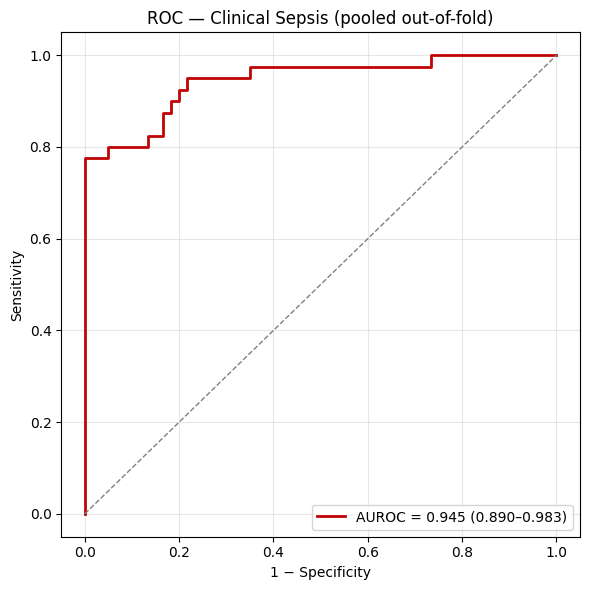

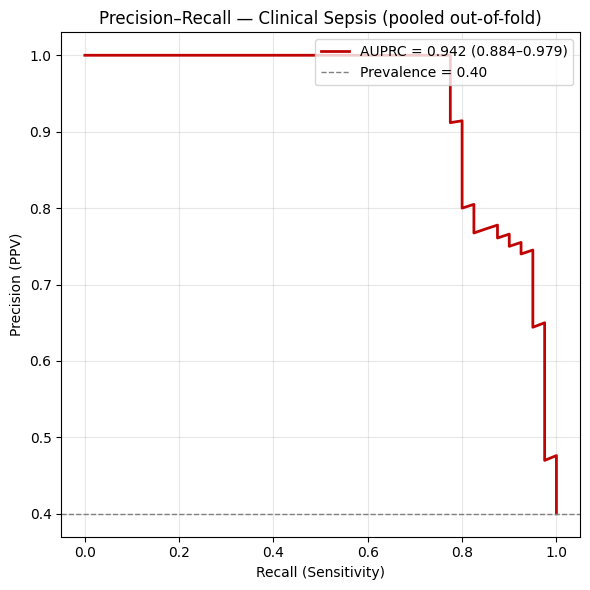

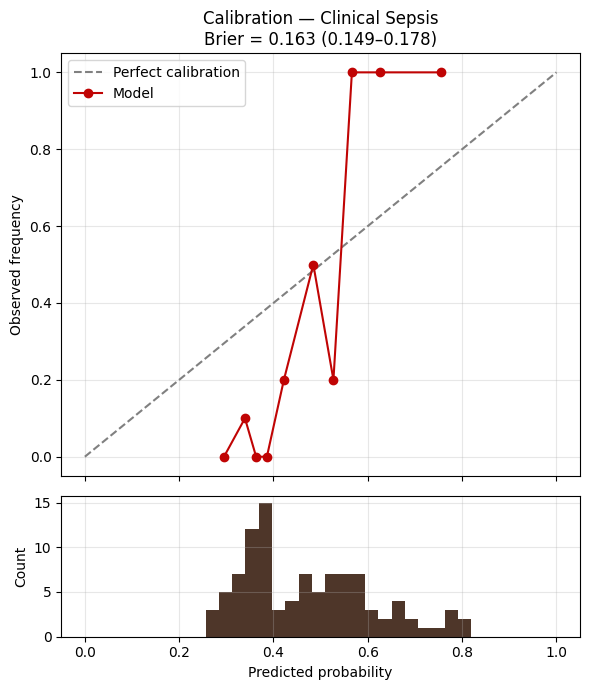

In [ ]:
# 8. FIGURES  (all driven by the same pooled-OOF arrays + bootstrap CIs)
auroc_pt, auroc_lo, auroc_hi = boot_ci["AUROC"]
prauc_pt, prauc_lo, prauc_hi = boot_ci["AUPRC"]
brier_pt, brier_lo, brier_hi = boot_ci["Brier"]
prevalence = y_true_all.mean()

# --- 8a. ROC (label = same value as the table) -------------------------------
fpr, tpr, _ = roc_curve(y_true_all, y_proba_all)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color=COLOR, lw=2,
         label=f"AUROC = {auroc_pt:.3f} ({auroc_lo:.3f}\u2013{auroc_hi:.3f})")
plt.plot([0, 1], [0, 1], '--', color="gray", lw=1)
plt.xlabel("1 \u2212 Specificity"); plt.ylabel("Sensitivity")
plt.title(f"ROC \u2014 {FEATURE_SET_NAME} {TARGET} (pooled out-of-fold)")
plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"ROC_{FEATURE_SET_NAME}_{TARGET}.png", dpi=300, bbox_inches="tight"); plt.show()

# --- 8b. Precision-Recall (with prevalence baseline) -------------------------
prec, rec, _ = precision_recall_curve(y_true_all, y_proba_all)
plt.figure(figsize=(6, 6))
plt.plot(rec, prec, color=COLOR, lw=2,
         label=f"AUPRC = {prauc_pt:.3f} ({prauc_lo:.3f}\u2013{prauc_hi:.3f})")
plt.axhline(prevalence, ls='--', color="gray", lw=1, label=f"Prevalence = {prevalence:.2f}")
plt.xlabel("Recall (Sensitivity)"); plt.ylabel("Precision (PPV)")
plt.title(f"Precision\u2013Recall \u2014 {FEATURE_SET_NAME} {TARGET} (pooled out-of-fold)")
plt.legend(loc="upper right"); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"PR_{FEATURE_SET_NAME}_{TARGET}.png", dpi=300, bbox_inches="tight"); plt.show()

# --- 8c. Calibration (pooled OOF, not in-sample) + probability histogram ------
prob_true, prob_pred = calibration_curve(y_true_all, y_proba_all, n_bins=10, strategy="quantile")
fig, (a1, a2) = plt.subplots(2, 1, figsize=(6, 7), height_ratios=[3, 1], sharex=True)
a1.plot([0, 1], [0, 1], '--', color="gray", label="Perfect calibration")
a1.plot(prob_pred, prob_true, 'o-', color=COLOR, label="Model")
a1.set_ylabel("Observed frequency"); a1.legend(loc="upper left"); a1.grid(alpha=0.3)
a1.set_title(f"Calibration \u2014 {FEATURE_SET_NAME} {TARGET}\n"
             f"Brier = {brier_pt:.3f} ({brier_lo:.3f}\u2013{brier_hi:.3f})")
a2.hist(y_proba_all, bins=20, color="#4E3629")
a2.set_xlabel("Predicted probability"); a2.set_ylabel("Count"); a2.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"Calibration_{FEATURE_SET_NAME}_{TARGET}.png", dpi=300, bbox_inches="tight"); plt.show()



--- Standardized logistic regression coefficients (Table 4) ---
                Feature  Coefficient (log-odds)  Coef 2.5%  Coef 97.5%  Odds Ratio (per 1 SD)  OR 2.5%  OR 97.5%
        SpO2:FiO2 Ratio                  -0.326     -0.852       0.199                  0.722    0.426     1.221
     Glasgow Coma Scale                  -0.250     -0.797       0.297                  0.779    0.451     1.346
Systolic Blood Pressure                  -0.191     -0.683       0.301                  0.826    0.505     1.352
             Heart Rate                   0.081     -0.489       0.651                  1.084    0.613     1.917
       Respiratory Rate                   0.052     -0.462       0.567                  1.054    0.630     1.763
           Age (months)                  -0.014     -0.506       0.477                  0.986    0.603     1.612
            Temperature                   0.011     -0.506       0.529                  1.011    0.603     1.697


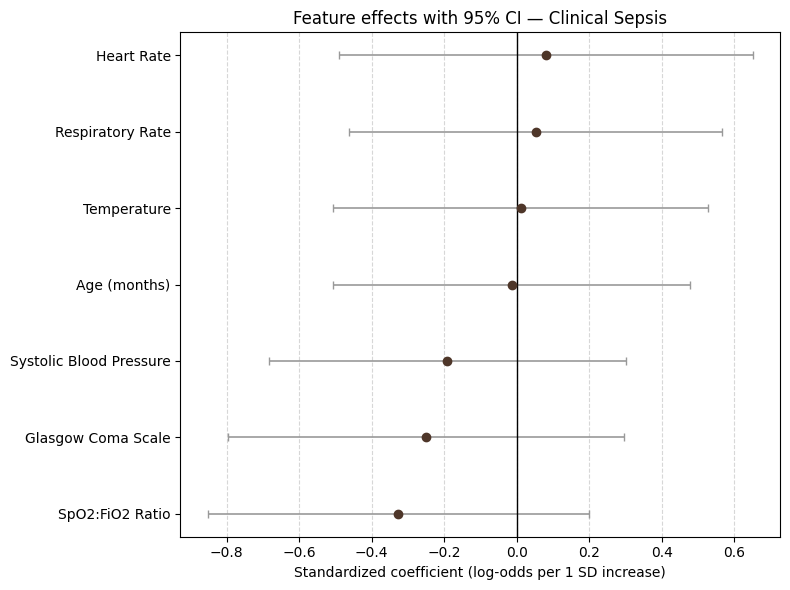


logit(p) = -0.092 + (-0.326 × SpO2:FiO2 Ratio) + (0.011 × Temperature) + (0.081 × Heart Rate) + (0.052 × Respiratory Rate) + (-0.191 × Systolic Blood Pressure) + (-0.014 × Age (months)) + (-0.250 × Glasgow Coma Scale)


In [ ]:
# 9. Standardized logistic regression: coefficients, ORs, 95% CI  (Table 4)
#    Wald CIs feed BOTH the table and the forest plot (single source of truth).
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
lr_params = best_params_dict.get('Logistic Regression', {})
final_lr = LogisticRegression(**lr_params, class_weight="balanced",
                              max_iter=1000, random_state=RANDOM_STATE).fit(X_std, y)

# Wald covariance for CIs
Xd = np.column_stack([np.ones(X_std.shape[0]), X_std])
p_hat = final_lr.predict_proba(X_std)[:, 1]
W = np.diag(p_hat * (1 - p_hat))
cov = np.linalg.inv(Xd.T @ W @ Xd)
coef = final_lr.coef_[0]
se = np.sqrt(np.diag(cov))[1:]
coef_lo, coef_hi = coef - 1.96 * se, coef + 1.96 * se

coef_df = pd.DataFrame({
    "Feature": [READABLE.get(f, f) for f in FEATURES],
    "Coefficient (log-odds)": coef,
    "Coef 2.5%": coef_lo, "Coef 97.5%": coef_hi,
    "Odds Ratio (per 1 SD)": np.exp(coef),
    "OR 2.5%": np.exp(coef_lo), "OR 97.5%": np.exp(coef_hi),
}).sort_values("Coefficient (log-odds)", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
coef_df_pub = coef_df.round(3)
print("\n--- Standardized logistic regression coefficients (Table 4) ---")
print(coef_df_pub.to_string(index=False))
coef_df_pub.to_csv(f"{FEATURE_SET_NAME}_{TARGET}_logreg_coefficients.csv", index=False)

# --- 9b. Coefficient FOREST plot with 95% CI (C2 fix: no false precision) -----
pdf = coef_df.sort_values("Coefficient (log-odds)").reset_index(drop=True)
plt.figure(figsize=(8, 6))
xerr = [pdf["Coefficient (log-odds)"] - pdf["Coef 2.5%"],
        pdf["Coef 97.5%"] - pdf["Coefficient (log-odds)"]]
plt.errorbar(pdf["Coefficient (log-odds)"], range(len(pdf)), xerr=xerr,
             fmt='o', color="#4E3629", ecolor="#999999", capsize=3, lw=1.2)
plt.axvline(0, color="black", lw=1)
plt.yticks(range(len(pdf)), pdf["Feature"])
plt.xlabel("Standardized coefficient (log-odds per 1 SD increase)")
plt.title(f"Feature effects with 95% CI \u2014 {FEATURE_SET_NAME} {TARGET}")
plt.grid(axis='x', ls='--', alpha=0.5); plt.tight_layout()
plt.savefig(f"Coefficients_{FEATURE_SET_NAME}_{TARGET}.png", dpi=300, bbox_inches="tight"); plt.show()

# --- 9c. Logistic regression equation (Supplemental Table 3) ------------------
intercept = final_lr.intercept_[0]
equation = f"logit(p) = {intercept:.3f} + " + " + ".join(
    f"({c:.3f} \u00D7 {READABLE.get(f, f)})" for c, f in zip(coef, FEATURES))
print("\n" + equation)

In [ ]:

# 10. Exports
cv_results_df.to_csv(f"{FEATURE_SET_NAME}_{TARGET}_model_comparison.csv", index=False)
hyperparam_table.to_csv(f"{FEATURE_SET_NAME}_{TARGET}_hyperparameters.csv", index=False)
thr_table.to_csv(f"{FEATURE_SET_NAME}_{TARGET}_fixed_threshold_metrics.csv", index=False)
cv_results_opt_df.to_csv(f"{FEATURE_SET_NAME}_{TARGET}_inner_cv_threshold_metrics.csv", index=False)
pd.DataFrame([{"metric": k, "point": v[0], "lo95": v[1], "hi95": v[2]}
              for k, v in boot_ci.items()]).to_csv(
              f"{FEATURE_SET_NAME}_{TARGET}_bootstrap_CIs.csv", index=False)
pd.DataFrame([{"Feature Set": FEATURE_SET_NAME, "Outcome": TARGET,
               "Intercept": intercept, "Model Specification": equation}]
            ).to_csv(f"{FEATURE_SET_NAME}_{TARGET}_equation.csv", index=False)
print("\nDone.")


Done.


##Clinical + Lab Septic Shock

=== Clinical+Lab | Septic_shock ===
Windows (rows): 100 | Patients: 100
Positive windows: 23 (23.0%)


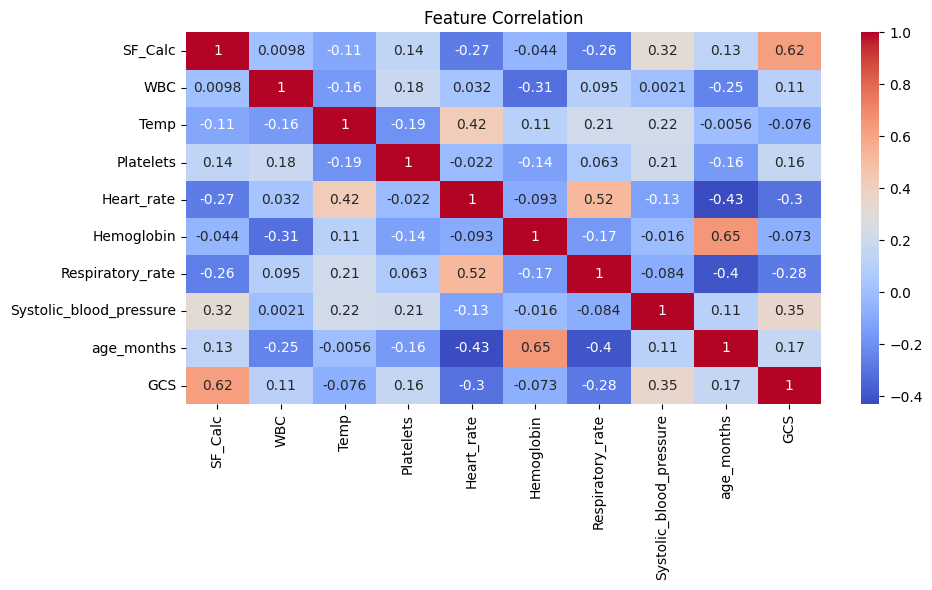

In [ ]:
# =============================================================================
# Clinical + Laboratory Variables  —  SEPSIS detection (REVISED)
# =============================================================================
# This is a drop-in rewrite of one feature-set analysis with the reviewer fixes
# built in. To run the other three analyses, copy this file and change ONLY the
# CONFIG block below:
#   - Non-Lab Sepsis        -> FEATURES = NONLAB_FEATURES ; TARGET = "Sepsis"
#   - Clinical+Lab Shock     -> FEATURES = CLINLAB_FEATURES; TARGET = "Septic_shock"
#   - Non-Lab Septic shock   -> FEATURES = NONLAB_FEATURES ; TARGET = "Septic_shock"
#
# Assumes `df` (the windowed analytic dataframe with one row per 12-h window)
# is already in memory, containing the feature columns, the target column,
# and 'study_id'.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score, brier_score_loss,
                             roc_curve, precision_recall_curve, confusion_matrix)
from sklearn.calibration import (calibration_curve, CalibratedClassifierCV)

# =============================================================================
# CONFIG  (the ONLY block you change between the four analyses)
# =============================================================================
FEATURE_SET_NAME = "Clinical+Lab"
TARGET           = "Septic_shock"            # or "Septic_shock"

CLINLAB_FEATURES = ['SF_Calc', 'WBC', 'Temp', 'Platelets', 'Heart_rate', 'Hemoglobin',
                    'Respiratory_rate', 'Systolic_blood_pressure', 'age_months', 'GCS']
NONLAB_FEATURES  = ['SF_Calc', 'Temp', 'Heart_rate', 'Respiratory_rate',
                    'Systolic_blood_pressure', 'age_months', 'GCS']
FEATURES = CLINLAB_FEATURES

READABLE = {
    'SF_Calc': 'SpO2:FiO2 Ratio', 'Heart_rate': 'Heart Rate',
    'Respiratory_rate': 'Respiratory Rate', 'Temp': 'Temperature',
    'Platelets': 'Platelet Count', 'WBC': 'White Blood Cell Count',
    'Hemoglobin': 'Hemoglobin (Hb)', 'Systolic_blood_pressure': 'Systolic Blood Pressure',
    'GCS': 'Glasgow Coma Scale', 'age_months': 'Age (months)',
}

N_SPLITS            = 5
N_REPEATS           = 40         # repeated CV for stable, bounded interval estimates
N_BOOT              = 2000       # patient-level bootstrap iterations (use 200 while testing, 2000 for analysis)
SCREENING_THRESHOLD = 0.30       # high-sensitivity operating point for the screening table
HEADLINE_MODEL      = "Logistic Regression"   # model interpreted in Table 3/4 + main figures
RANDOM_STATE        = 42
COLOR               = "#C00404"

# 1. Build X / y / groups
data = df[FEATURES + [TARGET, 'study_id']].dropna().copy()
data[TARGET] = data[TARGET].astype(int)
X = data[FEATURES].reset_index(drop=True)
y = data[TARGET].reset_index(drop=True)
groups = data['study_id'].reset_index(drop=True)

print(f"=== {FEATURE_SET_NAME} | {TARGET} ===")
print(f"Windows (rows): {len(X)} | Patients: {groups.nunique()}")
print(f"Positive windows: {int(y.sum())} ({100*y.mean():.1f}%)")   # <-- B1: report class balance

plt.figure(figsize=(10, 6))
sns.heatmap(data[FEATURES].corr(), annot=True, cmap='coolwarm'); plt.title("Feature Correlation")
plt.tight_layout(); plt.show()

In [ ]:
# 2. Cross-validation strategy (single + repeated)
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = [list(StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=s)
                  .split(X, y, groups)) for s in range(N_REPEATS)]

In [ ]:

# 3. Helper functions
def pick_threshold_on_train(fitted_model, X_tr, y_tr):
    p_tr = fitted_model.predict_proba(X_tr)[:, 1]
    prec, rec, thr = precision_recall_curve(y_tr, p_tr)
    if len(thr) == 0:
        return 0.5
    f1 = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-8)
    return thr[int(np.argmax(f1))]

def evaluate_repeated_cv(model, threshold=0.5):
    """Run model over all repeated folds.
    threshold: a float (fixed operating point, default 0.5), or "inner" (inner-CV F1-optimal)."""
    out = {k: [] for k in ["accuracy", "f1", "precision", "recall", "auroc", "pr_auc", "brier", "threshold"]}
    for splits in cv_splits:
        for tr, te in splits:
            m = clone(model).fit(X.iloc[tr], y.iloc[tr])
            if threshold == "inner":
                t = _inner_cv_threshold(model, X.iloc[tr], y.iloc[tr], groups.iloc[tr])
            else:
                t = float(threshold)
            p_te = m.predict_proba(X.iloc[te])[:, 1]
            yhat = (p_te >= t).astype(int)
            yte = y.iloc[te]
            out["accuracy"].append(accuracy_score(yte, yhat))
            out["f1"].append(f1_score(yte, yhat, zero_division=0))
            out["precision"].append(precision_score(yte, yhat, zero_division=0))
            out["recall"].append(recall_score(yte, yhat, zero_division=0))
            out["auroc"].append(roc_auc_score(yte, p_te) if yte.nunique() > 1 else np.nan)
            out["pr_auc"].append(average_precision_score(yte, p_te) if yte.nunique() > 1 else np.nan)
            out["brier"].append(brier_score_loss(yte, p_te))
            out["threshold"].append(t)
    return out

def _inner_cv_threshold(model, X_tr, y_tr, g_tr):
    """F1-optimal threshold from out-of-fold predictions WITHIN the training fold."""
    yt, yp = [], []
    inner = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    for itr, ite in inner.split(X_tr, y_tr, groups=g_tr):
        mm = clone(model).fit(X_tr.iloc[itr], y_tr.iloc[itr])
        yp.append(mm.predict_proba(X_tr.iloc[ite])[:, 1]); yt.append(y_tr.iloc[ite].values)
    yt, yp = np.concatenate(yt), np.concatenate(yp)
    prec, rec, thr = precision_recall_curve(yt, yp)
    if len(thr) == 0:
        return 0.5
    f1 = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-8)
    return thr[int(np.argmax(f1))]

def summarize(values):
    """percentile interval (bounded in [0,1], never produces impossible CIs)."""
    v = np.asarray(values, float); v = v[~np.isnan(v)]
    return np.mean(v), np.percentile(v, 2.5), np.percentile(v, 97.5)

def fmt(values):
    m, lo, hi = summarize(values)
    return f"{m:.3f} ({lo:.3f}, {hi:.3f})"

def pooled_oof(model):
    """C1: one repeated-CV pass -> pooled out-of-fold (OOF) labels/probs.
    These OOF probs are the SINGLE SOURCE used by the curves, calibration, and bootstrap."""
    yt, yp = [], []
    for splits in cv_splits:
        for tr, te in splits:
            m = clone(model).fit(X.iloc[tr], y.iloc[tr])
            yp.append(m.predict_proba(X.iloc[te])[:, 1]); yt.append(y.iloc[te].values)
    return np.concatenate(yt), np.concatenate(yp)

def cluster_bootstrap_ci(model, n_boot=N_BOOT, seed=RANDOM_STATE):
    """Threshold-free AUROC/AUPRC/Brier with patient-clustered bootstrap CIs.
    Point = out-of-fold prediction; CI = percentiles over patient resamples of those FIXED preds.
    Returns (results_dict, oof) where oof = (y_true, y_proba, groups) for reuse downstream."""
    yt, yp, g = single_pass_oof(model)
    def thrfree(a, b):
        return (roc_auc_score(a, b), average_precision_score(a, b), brier_score_loss(a, b))
    point = thrfree(yt, yp)
    boots = {0: [], 1: [], 2: []}; n_used = 0
    for ridx in boot_indices(g, n_boot, seed):
        ytb, ypb = yt[ridx], yp[ridx]
        if len(np.unique(ytb)) < 2:
            continue
        a, p, b = thrfree(ytb, ypb)
        boots[0].append(a); boots[1].append(p); boots[2].append(b); n_used += 1
    names = ["AUROC", "AUPRC", "Brier"]
    res = {names[i]: (point[i], np.percentile(boots[i], 2.5), np.percentile(boots[i], 97.5))
           for i in range(3)}
    print(f"  (bootstrap used {n_used}/{n_boot} resamples)")
    return res, (yt, yp, g)

def threshold_report(oof, thresholds, n_boot=N_BOOT, seed=RANDOM_STATE):
    """Confusion-matrix counts + sensitivity/specificity/PPV/NPV at FIXED thresholds,
    each with a patient-clustered bootstrap 95% CI. Counts are real (single OOF pass)."""
    yt, yp, g = oof
    def rates(a, p, t):
        yhat = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(a, yhat, labels=[0, 1]).ravel()
        return (tp/(tp+fn) if (tp+fn) else np.nan, tn/(tn+fp) if (tn+fp) else np.nan,
                tp/(tp+fp) if (tp+fp) else np.nan, tn/(tn+fn) if (tn+fn) else np.nan)
    resamples = list(boot_indices(g, n_boot, seed))
    rows = []
    for t in thresholds:
        pt = rates(yt, yp, t)
        bs = {i: [] for i in range(4)}
        for ridx in resamples:
            r = rates(yt[ridx], yp[ridx], t)
            for i in range(4):
                if not np.isnan(r[i]):
                    bs[i].append(r[i])
        yhat = (yp >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(yt, yhat, labels=[0, 1]).ravel()
        row = {"threshold": round(t, 3), "TP": tp, "FP": fp, "FN": fn, "TN": tn}
        for i, nm in enumerate(["sensitivity", "specificity", "PPV", "NPV"]):
            lo, hi = np.percentile(bs[i], [2.5, 97.5])
            row[nm] = f"{pt[i]:.3f} ({lo:.3f}, {hi:.3f})"
        rows.append(row)
    return pd.DataFrame(rows)

def single_pass_oof(model, seed=RANDOM_STATE):
    """One grouped-CV pass: each row predicted exactly once, out-of-fold (no repeats)."""
    yt = np.empty(len(y)); yp = np.empty(len(y))
    for tr, te in StratifiedGroupKFold(N_SPLITS, shuffle=True, random_state=seed).split(X, y, groups):
        m = clone(model).fit(X.iloc[tr], y.iloc[tr])
        yp[te] = m.predict_proba(X.iloc[te])[:, 1]; yt[te] = y.iloc[te].values
    return yt.astype(int), yp, groups.values

def _all_metrics(yt, yp, thr):
    yhat = (yp >= thr).astype(int); two = len(np.unique(yt)) > 1
    return {'AUROC':     roc_auc_score(yt, yp) if two else np.nan,
            'PR-AUC':    average_precision_score(yt, yp) if two else np.nan,
            'F1':        f1_score(yt, yhat, zero_division=0),
            'Precision': precision_score(yt, yhat, zero_division=0),
            'Recall':    recall_score(yt, yhat, zero_division=0),
            'Brier':     brier_score_loss(yt, yp),
            'Accuracy':  accuracy_score(yt, yhat)}

def bootstrap_all_metrics(model, n_boot=N_BOOT, thr=0.5, seed=RANDOM_STATE):
    """Patient-clustered bootstrap CI for all 7 metrics at a FIXED threshold.
    Point = metric on the out-of-fold predictions; CI = percentiles over patient resamples
    of those FIXED predictions (no refit inside the loop -> no duplicate-across-folds leakage)."""
    yt, yp, g = single_pass_oof(model)
    point = _all_metrics(yt, yp, thr)
    uniq = np.unique(g); rb = np.random.default_rng(seed)
    idx_by_pid = {pid: np.where(g == pid)[0] for pid in uniq}
    boot = {k: [] for k in point}; n_used = 0
    for _ in range(n_boot):
        picked = rb.choice(uniq, size=len(uniq), replace=True)
        ridx = np.concatenate([idx_by_pid[pid] for pid in picked])
        ytb, ypb = yt[ridx], yp[ridx]
        if len(np.unique(ytb)) < 2:
            continue
        for k, v in _all_metrics(ytb, ypb, thr).items():
            boot[k].append(v)
        n_used += 1
    out = {}
    for k in point:
        a = np.array(boot[k], float); a = a[~np.isnan(a)]
        lo, hi = np.percentile(a, [2.5, 97.5])
        out[k] = f"{point[k]:.3f} ({lo:.3f}, {hi:.3f})"
    return out, n_used

def boot_indices(g, n_boot=N_BOOT, seed=RANDOM_STATE):
    """Yield patient-clustered bootstrap row-index arrays (resample study_ids w/ replacement)."""
    uniq = np.unique(g); rb = np.random.default_rng(seed)
    idx_by_pid = {pid: np.where(g == pid)[0] for pid in uniq}
    for _ in range(n_boot):
        picked = rb.choice(uniq, size=len(uniq), replace=True)
        yield np.concatenate([idx_by_pid[pid] for pid in picked])

In [ ]:
pip install optuna

In [ ]:

# 4. Hyperparameter optimization (Optuna)
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 50

def optimize_model(model_name):
    def objective(trial):
        if model_name == 'Random Forest':
            clf = make_pipeline(StandardScaler(), RandomForestClassifier(
                n_estimators=trial.suggest_int('n_estimators', 100, 300),
                max_depth=trial.suggest_int('max_depth', 3, 20),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
                class_weight='balanced', random_state=RANDOM_STATE))
        elif model_name == 'Decision Tree':
            clf = make_pipeline(StandardScaler(), DecisionTreeClassifier(
                max_depth=trial.suggest_int('max_depth', 3, 20),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
                class_weight='balanced', random_state=RANDOM_STATE))
        elif model_name == 'SVM':
            clf = make_pipeline(StandardScaler(), CalibratedClassifierCV(
                SVC(kernel='linear',
                    C=trial.suggest_float('C', 0.01, 10, log=True),
                    class_weight='balanced', random_state=RANDOM_STATE),
                method='sigmoid', cv=3))
        elif model_name == 'Kernel SVM':
            clf = make_pipeline(StandardScaler(), CalibratedClassifierCV(
                SVC(kernel='rbf',
                    C=trial.suggest_float('C', 0.01, 10, log=True),
                    gamma=trial.suggest_categorical('gamma', ['scale', 'auto']),
                    class_weight='balanced', random_state=RANDOM_STATE),
                method='sigmoid', cv=3))
        elif model_name == 'Naive Bayes':
            clf = make_pipeline(StandardScaler(), GaussianNB(
                var_smoothing=trial.suggest_float('var_smoothing', 1e-9, 1e-7, log=True)))
        elif model_name == 'KNN':
            clf = make_pipeline(StandardScaler(), KNeighborsClassifier(
                n_neighbors=trial.suggest_int('n_neighbors', 1, 20),
                weights=trial.suggest_categorical('weights', ['uniform', 'distance']),
                p=trial.suggest_categorical('p', [1, 2])))
        elif model_name == 'Logistic Regression':
            clf = make_pipeline(StandardScaler(), LogisticRegression(
                C=trial.suggest_float('C', 0.01, 10, log=True),
                solver=trial.suggest_categorical('solver', ['lbfgs', 'saga']),
                class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
        else:
            raise ValueError("Model not recognized.")
        return cross_val_score(clf, X, y, cv=cv, groups=groups,
                               scoring='average_precision', n_jobs=-1).mean()
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=N_TRIALS)
    print(f"Best {model_name} params: {study.best_params}")
    return study.best_params

model_names = ['Decision Tree', 'Random Forest', 'SVM', 'Kernel SVM',
               'Naive Bayes', 'KNN', 'Logistic Regression']
best_params_dict = {}
for name in model_names:
    print(f"Optimizing {name}...")
    best_params_dict[name] = optimize_model(name)

hyperparam_table = (pd.DataFrame(best_params_dict).T.reset_index().rename(columns={"index": "Model"}))



Optimizing Decision Tree...
Best Decision Tree params: {'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 7}
Optimizing Random Forest...
Best Random Forest params: {'n_estimators': 160, 'max_depth': 8, 'min_samples_split': 8, 'min_samples_leaf': 3}
Optimizing SVM...
Best SVM params: {'C': 0.010547143083480334}
Optimizing Kernel SVM...
Best Kernel SVM params: {'C': 0.036442490364894824, 'gamma': 'auto'}
Optimizing Naive Bayes...
Best Naive Bayes params: {'var_smoothing': 1.1749817242422451e-08}
Optimizing KNN...
Best KNN params: {'n_neighbors': 8, 'weights': 'distance', 'p': 2}
Optimizing Logistic Regression...
Best Logistic Regression params: {'C': 0.03660693852174096, 'solver': 'saga'}


In [ ]:
# 5. Build models (all pipelines -> scaling handled inside CV, no manual scaling)
def build_models(bp):
    return {
        'Decision Tree': make_pipeline(StandardScaler(), DecisionTreeClassifier(
            **bp.get('Decision Tree', {}), class_weight='balanced', random_state=RANDOM_STATE)),
        'Random Forest': make_pipeline(StandardScaler(), RandomForestClassifier(
            **bp.get('Random Forest', {}), class_weight='balanced', random_state=RANDOM_STATE)),
        'SVM': make_pipeline(StandardScaler(), CalibratedClassifierCV(
            SVC(kernel='linear', **bp.get('SVM', {}),
                class_weight='balanced', random_state=RANDOM_STATE),
            method='sigmoid', cv=3)),
        'Kernel SVM': make_pipeline(StandardScaler(), CalibratedClassifierCV(
            SVC(kernel='rbf', **bp.get('Kernel SVM', {}),
                class_weight='balanced', random_state=RANDOM_STATE),
            method='sigmoid', cv=3)),
        'Naive Bayes': make_pipeline(StandardScaler(), GaussianNB(**bp.get('Naive Bayes', {}))),
        'KNN': make_pipeline(StandardScaler(), KNeighborsClassifier(**bp.get('KNN', {}))),
        'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(
            **bp.get('Logistic Regression', {}), class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE)),
    }
models = build_models(best_params_dict)

In [ ]:
# # 6. Model comparison table  (repeated CV + percentile CIs + train-only threshold)
# #    -> Supplemental Table. No test-set threshold tuning; CIs cannot exceed [0,1].
# cv_results = {'Model': [], 'Accuracy (95% CI)': [], 'F1 Score (95% CI)': [],
#               'AUROC (95% CI)': [], 'PR-AUC (95% CI)': [], 'Brier (95% CI)': [],
#               'Precision (95% CI)': [], 'Recall (95% CI)': []}
# for name, model in models.items():
#     r = evaluate_repeated_cv(model)
#     cv_results['Model'].append(name)
#     cv_results['Accuracy (95% CI)'].append(fmt(r['accuracy']))
#     cv_results['F1 Score (95% CI)'].append(fmt(r['f1']))
#     cv_results['Precision (95% CI)'].append(fmt(r['precision']))
#     cv_results['Recall (95% CI)'].append(fmt(r['recall']))
#     cv_results['AUROC (95% CI)'].append(fmt(r['auroc']))
#     cv_results['PR-AUC (95% CI)'].append(fmt(r['pr_auc']))
#     cv_results['Brier (95% CI)'].append(fmt(r['brier']))
# cv_results_df = pd.DataFrame(cv_results)
# print("\n--- Model comparison (repeated CV, percentile CIs) ---")
# print(cv_results_df.to_string(index=False))

In [ ]:
# 6. Model comparison table — patient-level bootstrap 95% CIs at a fixed 0.5 threshold
#    Point estimate = out-of-fold prediction; CIs = patient-clustered percentile bootstrap.
metric_order = ['AUROC', 'PR-AUC', 'F1', 'Precision', 'Recall', 'Brier', 'Accuracy']
rows6 = []
for name, model in models.items():
    res, n_used = bootstrap_all_metrics(model, n_boot=N_BOOT, thr=0.5)
    rows6.append({'Model': name, **{f'{k} (95% CI)': res[k] for k in metric_order}})
cv_results_df = pd.DataFrame(rows6)
print(f"\n--- Model comparison (patient-level bootstrap CIs, threshold = 0.50; {n_used} resamples) ---")
print(cv_results_df.to_string(index=False))


--- Model comparison (patient-level bootstrap CIs, threshold = 0.50; 2000 resamples) ---
              Model       AUROC (95% CI)      PR-AUC (95% CI)          F1 (95% CI)   Precision (95% CI)      Recall (95% CI)       Brier (95% CI)    Accuracy (95% CI)
      Decision Tree 0.768 (0.642, 0.870) 0.551 (0.350, 0.749) 0.490 (0.300, 0.646) 0.462 (0.261, 0.650) 0.522 (0.316, 0.727) 0.179 (0.126, 0.239) 0.750 (0.660, 0.830)
      Random Forest 0.851 (0.749, 0.932) 0.728 (0.546, 0.861) 0.619 (0.421, 0.769) 0.684 (0.461, 0.882) 0.565 (0.364, 0.760) 0.120 (0.089, 0.155) 0.840 (0.760, 0.910)
                SVM 0.878 (0.775, 0.954) 0.793 (0.624, 0.910) 0.595 (0.359, 0.765) 0.786 (0.538, 1.000) 0.478 (0.250, 0.684) 0.098 (0.064, 0.137) 0.850 (0.780, 0.920)
         Kernel SVM 0.881 (0.791, 0.947) 0.755 (0.573, 0.884) 0.556 (0.323, 0.724) 0.769 (0.500, 1.000) 0.435 (0.222, 0.636) 0.111 (0.078, 0.147) 0.840 (0.760, 0.910)
        Naive Bayes 0.826 (0.683, 0.937) 0.773 (0.592, 0.895) 0.681 (0.486,

In [ ]:
# 6b. Idealized comparison — inner-CV F1-optimal threshold (leakage-free, train-only)
#     AUROC/PR-AUC are threshold-free so identical to the table above; we show only the
#     threshold-dependent metrics plus the mean operating point selected per fold.
opt_results = {}
rows_opt = []
for name, model in models.items():
    r = evaluate_repeated_cv(model, threshold="inner")
    opt_results[name] = r
    rows_opt.append({'Model': name,
                     'Threshold (mean 95% CI)': fmt(r['threshold']),
                     'Accuracy (95% CI)': fmt(r['accuracy']),
                     'F1 Score (95% CI)': fmt(r['f1']),
                     'Precision (95% CI)': fmt(r['precision']),
                     'Recall (95% CI)': fmt(r['recall'])})
cv_results_opt_df = pd.DataFrame(rows_opt)
print("\n--- Model comparison (repeated CV, inner-CV F1-optimal threshold) ---")
print(cv_results_opt_df.to_string(index=False))


--- Model comparison (repeated CV, inner-CV F1-optimal threshold) ---
              Model Threshold (mean 95% CI)    Accuracy (95% CI)    F1 Score (95% CI)   Precision (95% CI)      Recall (95% CI)
      Decision Tree    0.737 (0.192, 1.000) 0.776 (0.450, 1.000) 0.493 (0.000, 0.857) 0.642 (0.000, 1.000) 0.503 (0.000, 1.000)
      Random Forest    0.409 (0.240, 0.570) 0.804 (0.600, 0.950) 0.566 (0.000, 0.801) 0.594 (0.000, 1.000) 0.620 (0.000, 1.000)
                SVM    0.370 (0.237, 0.514) 0.857 (0.700, 1.000) 0.641 (0.000, 1.000) 0.710 (0.000, 1.000) 0.635 (0.000, 1.000)
         Kernel SVM    0.367 (0.257, 0.481) 0.842 (0.700, 0.950) 0.627 (0.000, 0.889) 0.658 (0.000, 1.000) 0.663 (0.000, 1.000)
        Naive Bayes    0.858 (0.236, 1.000) 0.869 (0.750, 1.000) 0.629 (0.000, 0.925) 0.825 (0.000, 1.000) 0.552 (0.000, 1.000)
                KNN    0.237 (0.113, 0.408) 0.826 (0.649, 1.000) 0.574 (0.000, 1.000) 0.689 (0.000, 1.000) 0.566 (0.000, 1.000)
Logistic Regression    0.557 (0.4

In [ ]:
# 6c. Optimism-corrected internal validation (Harrell/Steyerberg bootstrap)
#     Quantifies over-optimism: how much APPARENT (in-sample) performance overstates
#     performance on new patients. Patient-clustered to match the rest of the pipeline.
#     "m-index" == c-index == AUROC.
def optimism_bootstrap(model, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    uniq = np.asarray(pd.unique(groups))
    def sc(yt, p):
        return np.array([roc_auc_score(yt, p),
                         average_precision_score(yt, p),
                         brier_score_loss(yt, p)])
    # Apparent performance: fit on all data, evaluate on the same data
    m_app = clone(model).fit(X, y)
    apparent = sc(y, m_app.predict_proba(X)[:, 1])
    opt, n_used = [], 0
    for _ in range(n_boot):
        picked = rng.choice(uniq, size=len(uniq), replace=True)              # resample PATIENTS
        ridx = np.concatenate([np.where(groups.values == pid)[0] for pid in picked])
        Xb, yb = X.iloc[ridx], y.iloc[ridx]
        if yb.nunique() < 2:
            continue
        m_b = clone(model).fit(Xb, yb)
        boot = sc(yb, m_b.predict_proba(Xb)[:, 1])   # performance where it was trained
        test = sc(y,  m_b.predict_proba(X)[:, 1])    # same model on the ORIGINAL sample
        opt.append(boot - test); n_used += 1
    optimism = np.mean(opt, axis=0)
    corrected = apparent - optimism                  # works for Brier too (sign cancels)
    return apparent, optimism, corrected, n_used

opt_rows = []
for name, model in models.items():
    app, optm, corr, nb = optimism_bootstrap(model)
    opt_rows.append({'Model': name,
                     'Apparent AUROC': round(app[0], 3),
                     'Optimism': round(optm[0], 3),
                     'Optimism-corrected AUROC': round(corr[0], 3),
                     'Corrected AUPRC': round(corr[1], 3),
                     'Corrected Brier': round(corr[2], 3)})
optimism_df = pd.DataFrame(opt_rows)
print(f"\n--- Optimism-corrected internal validation (patient bootstrap, {nb} resamples) ---")
print(optimism_df.to_string(index=False))


--- Optimism-corrected internal validation (patient bootstrap, 2000 resamples) ---
              Model  Apparent AUROC  Optimism  Optimism-corrected AUROC  Corrected AUPRC  Corrected Brier
      Decision Tree           0.941     0.091                     0.850            0.633            0.153
      Random Forest           0.999     0.044                     0.955            0.912            0.088
                SVM           0.925     0.025                     0.901            0.809            0.097
         Kernel SVM           0.948     0.036                     0.912            0.815            0.102
        Naive Bayes           0.922     0.043                     0.879            0.808            0.111
                KNN           1.000     0.050                     0.950            0.920            0.047
Logistic Regression           0.938     0.032                     0.906            0.811            0.133


In [ ]:
# 7. Headline model (Logistic Regression) — patient-level bootstrap + fixed-threshold table
#    These are the numbers that go in Table 3 AND on the figures (single source of truth).
best_model_name = HEADLINE_MODEL
best_model = models[best_model_name]

OPT_THRESHOLD = float(np.mean(opt_results[HEADLINE_MODEL]['threshold']))
print(f"\nF1-optimal threshold (inner-CV, headline model): {OPT_THRESHOLD:.3f}")

print(f"\n--- Headline model: {best_model_name} ---")
boot_ci, oof = cluster_bootstrap_ci(best_model, n_boot=N_BOOT)
for k, (pt, lo, hi) in boot_ci.items():
    print(f"  {k}: {pt:.3f} ({lo:.3f}, {hi:.3f})  [patient-level bootstrap]")

# single source of truth for every figure below
y_true_all, y_proba_all, _ = oof

# fixed-threshold table, now with bootstrap CIs on sens/spec/PPV/NPV
thr_table = threshold_report(oof, thresholds=(0.5, OPT_THRESHOLD, SCREENING_THRESHOLD), n_boot=N_BOOT)
print("\n--- Fixed-threshold performance (out-of-fold, bootstrap CIs) ---")
print(thr_table.to_string(index=False))


F1-optimal threshold (inner-CV, headline model): 0.557

--- Headline model: Logistic Regression ---
  (bootstrap used 2000/2000 resamples)
  AUROC: 0.870 (0.761, 0.952)  [patient-level bootstrap]
  AUPRC: 0.793 (0.621, 0.908)  [patient-level bootstrap]
  Brier: 0.141 (0.119, 0.166)  [patient-level bootstrap]

--- Fixed-threshold performance (out-of-fold, bootstrap CIs) ---
 threshold  TP  FP  FN  TN          sensitivity          specificity                  PPV                  NPV
     0.500  17  10   6  67 0.739 (0.542, 0.909) 0.870 (0.787, 0.938) 0.630 (0.440, 0.808) 0.918 (0.848, 0.973)
     0.557  16   6   7  71 0.696 (0.481, 0.870) 0.922 (0.853, 0.975) 0.727 (0.524, 0.909) 0.910 (0.843, 0.963)
     0.300  22  41   1  36 0.957 (0.857, 1.000) 0.468 (0.351, 0.580) 0.349 (0.232, 0.468) 0.973 (0.909, 1.000)


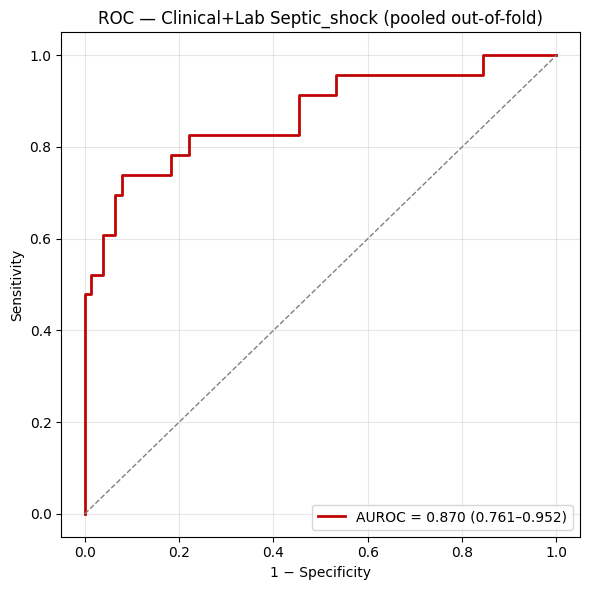

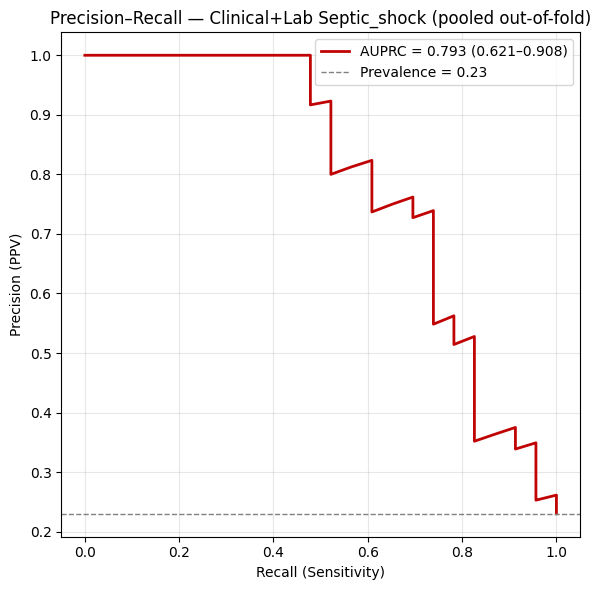

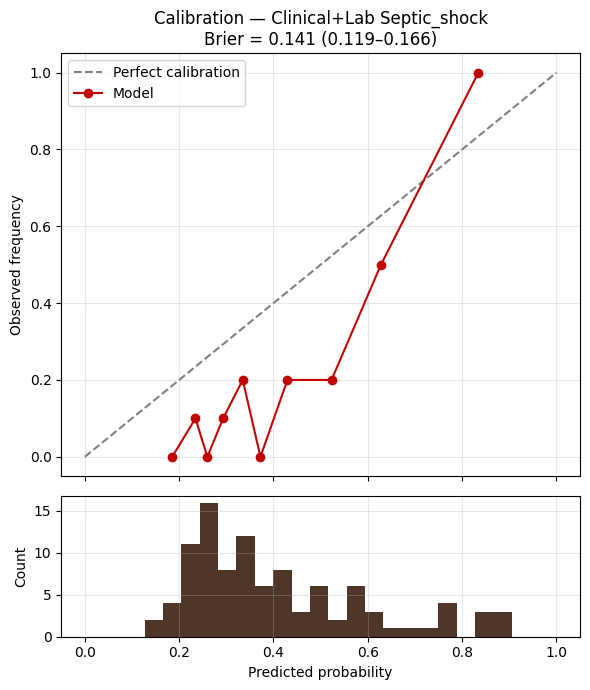

In [ ]:
# 8. FIGURES  (all driven by the same pooled-OOF arrays + bootstrap CIs)
auroc_pt, auroc_lo, auroc_hi = boot_ci["AUROC"]
prauc_pt, prauc_lo, prauc_hi = boot_ci["AUPRC"]
brier_pt, brier_lo, brier_hi = boot_ci["Brier"]
prevalence = y_true_all.mean()

# --- 8a. ROC (label = same value as the table) -------------------------------
fpr, tpr, _ = roc_curve(y_true_all, y_proba_all)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color=COLOR, lw=2,
         label=f"AUROC = {auroc_pt:.3f} ({auroc_lo:.3f}\u2013{auroc_hi:.3f})")
plt.plot([0, 1], [0, 1], '--', color="gray", lw=1)
plt.xlabel("1 \u2212 Specificity"); plt.ylabel("Sensitivity")
plt.title(f"ROC \u2014 {FEATURE_SET_NAME} {TARGET} (pooled out-of-fold)")
plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"ROC_{FEATURE_SET_NAME}_{TARGET}.png", dpi=300, bbox_inches="tight"); plt.show()

# --- 8b. Precision-Recall (with prevalence baseline) -------------------------
prec, rec, _ = precision_recall_curve(y_true_all, y_proba_all)
plt.figure(figsize=(6, 6))
plt.plot(rec, prec, color=COLOR, lw=2,
         label=f"AUPRC = {prauc_pt:.3f} ({prauc_lo:.3f}\u2013{prauc_hi:.3f})")
plt.axhline(prevalence, ls='--', color="gray", lw=1, label=f"Prevalence = {prevalence:.2f}")
plt.xlabel("Recall (Sensitivity)"); plt.ylabel("Precision (PPV)")
plt.title(f"Precision\u2013Recall \u2014 {FEATURE_SET_NAME} {TARGET} (pooled out-of-fold)")
plt.legend(loc="upper right"); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"PR_{FEATURE_SET_NAME}_{TARGET}.png", dpi=300, bbox_inches="tight"); plt.show()

# --- 8c. Calibration (pooled OOF, not in-sample) + probability histogram ------
prob_true, prob_pred = calibration_curve(y_true_all, y_proba_all, n_bins=10, strategy="quantile")
fig, (a1, a2) = plt.subplots(2, 1, figsize=(6, 7), height_ratios=[3, 1], sharex=True)
a1.plot([0, 1], [0, 1], '--', color="gray", label="Perfect calibration")
a1.plot(prob_pred, prob_true, 'o-', color=COLOR, label="Model")
a1.set_ylabel("Observed frequency"); a1.legend(loc="upper left"); a1.grid(alpha=0.3)
a1.set_title(f"Calibration \u2014 {FEATURE_SET_NAME} {TARGET}\n"
             f"Brier = {brier_pt:.3f} ({brier_lo:.3f}\u2013{brier_hi:.3f})")
a2.hist(y_proba_all, bins=20, color="#4E3629")
a2.set_xlabel("Predicted probability"); a2.set_ylabel("Count"); a2.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"Calibration_{FEATURE_SET_NAME}_{TARGET}.png", dpi=300, bbox_inches="tight"); plt.show()



--- Standardized logistic regression coefficients (Table 4) ---
                Feature  Coefficient (log-odds)  Coef 2.5%  Coef 97.5%  Odds Ratio (per 1 SD)  OR 2.5%  OR 97.5%
Systolic Blood Pressure                  -0.512     -1.099       0.074                  0.599    0.333     1.077
        SpO2:FiO2 Ratio                  -0.395     -0.958       0.168                  0.674    0.384     1.183
     Glasgow Coma Scale                  -0.234     -0.825       0.358                  0.792    0.438     1.430
         Platelet Count                  -0.164     -0.654       0.326                  0.849    0.520     1.385
       Respiratory Rate                   0.145     -0.405       0.694                  1.155    0.667     2.002
           Age (months)                   0.129     -0.574       0.831                  1.137    0.563     2.297
            Temperature                  -0.110     -0.698       0.479                  0.896    0.497     1.614
 White Blood Cell Count        

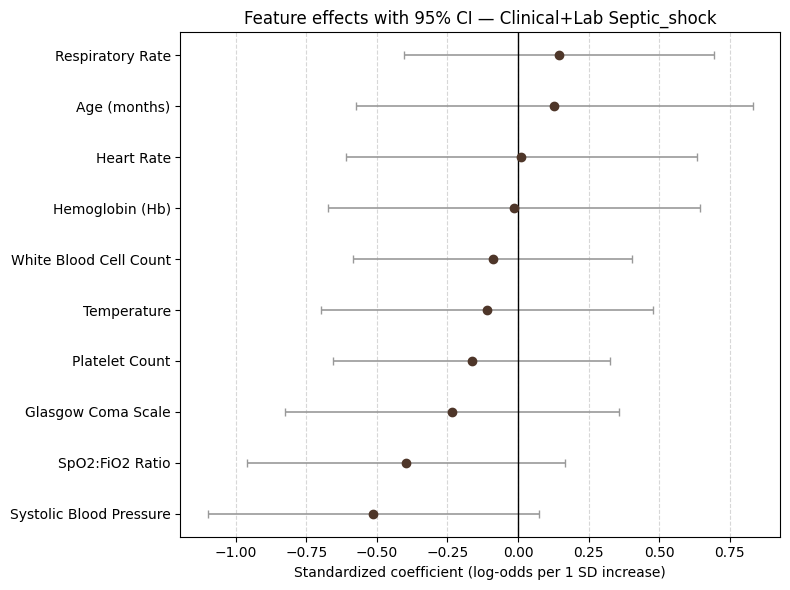


logit(p) = -0.411 + (-0.395 × SpO2:FiO2 Ratio) + (-0.089 × White Blood Cell Count) + (-0.110 × Temperature) + (-0.164 × Platelet Count) + (0.012 × Heart Rate) + (-0.013 × Hemoglobin (Hb)) + (0.145 × Respiratory Rate) + (-0.512 × Systolic Blood Pressure) + (0.129 × Age (months)) + (-0.234 × Glasgow Coma Scale)


In [ ]:
# 9. Standardized logistic regression: coefficients, ORs, 95% CI  (Table 4)
#    Wald CIs feed BOTH the table and the forest plot (single source of truth).
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
lr_params = best_params_dict.get('Logistic Regression', {})
final_lr = LogisticRegression(**lr_params, class_weight="balanced",
                              max_iter=1000, random_state=RANDOM_STATE).fit(X_std, y)

# Wald covariance for CIs
Xd = np.column_stack([np.ones(X_std.shape[0]), X_std])
p_hat = final_lr.predict_proba(X_std)[:, 1]
W = np.diag(p_hat * (1 - p_hat))
cov = np.linalg.inv(Xd.T @ W @ Xd)
coef = final_lr.coef_[0]
se = np.sqrt(np.diag(cov))[1:]
coef_lo, coef_hi = coef - 1.96 * se, coef + 1.96 * se

coef_df = pd.DataFrame({
    "Feature": [READABLE.get(f, f) for f in FEATURES],
    "Coefficient (log-odds)": coef,
    "Coef 2.5%": coef_lo, "Coef 97.5%": coef_hi,
    "Odds Ratio (per 1 SD)": np.exp(coef),
    "OR 2.5%": np.exp(coef_lo), "OR 97.5%": np.exp(coef_hi),
}).sort_values("Coefficient (log-odds)", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
coef_df_pub = coef_df.round(3)
print("\n--- Standardized logistic regression coefficients (Table 4) ---")
print(coef_df_pub.to_string(index=False))
coef_df_pub.to_csv(f"{FEATURE_SET_NAME}_{TARGET}_logreg_coefficients.csv", index=False)

# --- 9b. Coefficient FOREST plot with 95% CI (C2 fix: no false precision) -----
pdf = coef_df.sort_values("Coefficient (log-odds)").reset_index(drop=True)
plt.figure(figsize=(8, 6))
xerr = [pdf["Coefficient (log-odds)"] - pdf["Coef 2.5%"],
        pdf["Coef 97.5%"] - pdf["Coefficient (log-odds)"]]
plt.errorbar(pdf["Coefficient (log-odds)"], range(len(pdf)), xerr=xerr,
             fmt='o', color="#4E3629", ecolor="#999999", capsize=3, lw=1.2)
plt.axvline(0, color="black", lw=1)
plt.yticks(range(len(pdf)), pdf["Feature"])
plt.xlabel("Standardized coefficient (log-odds per 1 SD increase)")
plt.title(f"Feature effects with 95% CI \u2014 {FEATURE_SET_NAME} {TARGET}")
plt.grid(axis='x', ls='--', alpha=0.5); plt.tight_layout()
plt.savefig(f"Coefficients_{FEATURE_SET_NAME}_{TARGET}.png", dpi=300, bbox_inches="tight"); plt.show()

# --- 9c. Logistic regression equation (Supplemental Table 3) ------------------
intercept = final_lr.intercept_[0]
equation = f"logit(p) = {intercept:.3f} + " + " + ".join(
    f"({c:.3f} \u00D7 {READABLE.get(f, f)})" for c, f in zip(coef, FEATURES))
print("\n" + equation)

In [ ]:
import os

OUTPUT_DIR = "/content/drive/MyDrive/Pediatric Sepsis ML Model/csv"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# 10. Export Results to Google Drive
# ============================================================

cv_results_df.to_csv(
    os.path.join(OUTPUT_DIR,
                 f"{FEATURE_SET_NAME}_{TARGET}_model_comparison.csv"),
    index=False
)

hyperparam_table.to_csv(
    os.path.join(OUTPUT_DIR,
                 f"{FEATURE_SET_NAME}_{TARGET}_hyperparameters.csv"),
    index=False
)

thr_table.to_csv(
    os.path.join(OUTPUT_DIR,
                 f"{FEATURE_SET_NAME}_{TARGET}_fixed_threshold_metrics.csv"),
    index=False
)

cv_results_opt_df.to_csv(
    os.path.join(OUTPUT_DIR,
                 f"{FEATURE_SET_NAME}_{TARGET}_inner_cv_threshold_metrics.csv"),
    index=False
)

pd.DataFrame([
    {"metric": k,
     "point": v[0],
     "lo95": v[1],
     "hi95": v[2]}
    for k, v in boot_ci.items()
]).to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"{FEATURE_SET_NAME}_{TARGET}_bootstrap_CIs.csv"
    ),
    index=False
)

pd.DataFrame([
    {
        "Feature Set": FEATURE_SET_NAME,
        "Outcome": TARGET,
        "Intercept": intercept,
        "Model Specification": equation
    }
]).to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"{FEATURE_SET_NAME}_{TARGET}_equation.csv"
    ),
    index=False
)

print(f"\n✅ Files exported to: {OUTPUT_DIR}")


✅ Files exported to: /content/drive/MyDrive/Pediatric Sepsis ML Model/csv


##Clinical Septic Shock

=== Clinical | Septic_shock ===
Windows (rows): 100 | Patients: 100
Positive windows: 23 (23.0%)


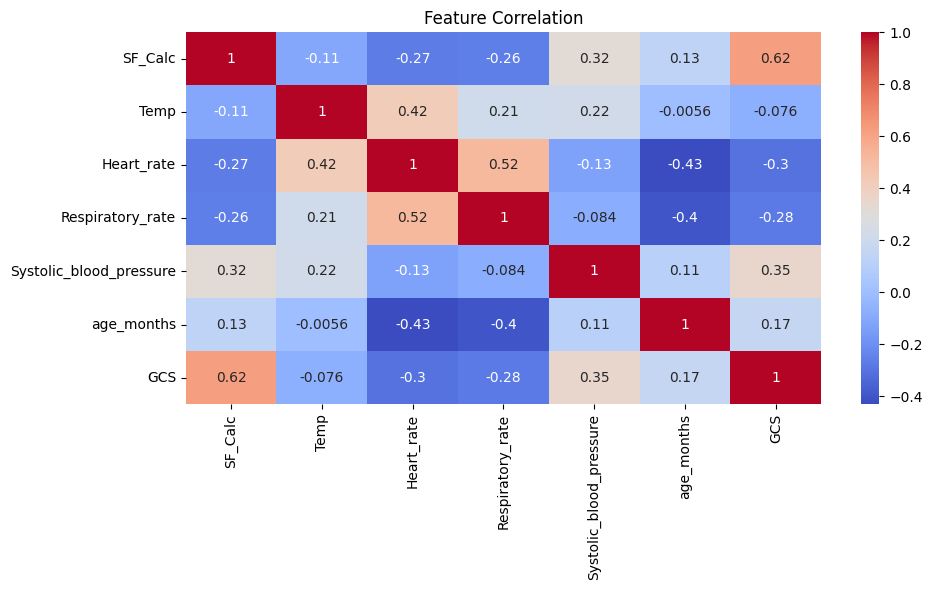

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score, brier_score_loss,
                             roc_curve, precision_recall_curve, confusion_matrix)
from sklearn.calibration import (calibration_curve, CalibratedClassifierCV)

# =============================================================================
# CONFIG  (the ONLY block you change between the four analyses)
# =============================================================================
FEATURE_SET_NAME = "Clinical"
TARGET           = "Septic_shock"            # or "Septic_shock"

CLINLAB_FEATURES = ['SF_Calc', 'WBC', 'Temp', 'Platelets', 'Heart_rate', 'Hemoglobin',
                    'Respiratory_rate', 'Systolic_blood_pressure', 'age_months', 'GCS']
NONLAB_FEATURES  = ['SF_Calc', 'Temp', 'Heart_rate', 'Respiratory_rate',
                    'Systolic_blood_pressure', 'age_months', 'GCS']
FEATURES = NONLAB_FEATURES

READABLE = {
    'SF_Calc': 'SpO2:FiO2 Ratio', 'Heart_rate': 'Heart Rate',
    'Respiratory_rate': 'Respiratory Rate', 'Temp': 'Temperature',
    'Platelets': 'Platelet Count', 'WBC': 'White Blood Cell Count',
    'Hemoglobin': 'Hemoglobin (Hb)', 'Systolic_blood_pressure': 'Systolic Blood Pressure',
    'GCS': 'Glasgow Coma Scale', 'age_months': 'Age (months)',
}

N_SPLITS            = 5
N_REPEATS           = 40         # repeated CV for stable, bounded interval estimates
N_BOOT              = 2000       # patient-level bootstrap iterations (use 200 while testing, 2000 for analysis)
SCREENING_THRESHOLD = 0.30       # high-sensitivity operating point for the screening table
HEADLINE_MODEL      = "Logistic Regression"   # model interpreted in Table 3/4 + main figures
RANDOM_STATE        = 42
COLOR               = "#C00404"

# 1. Build X / y / groups
data = df[FEATURES + [TARGET, 'study_id']].dropna().copy()
data[TARGET] = data[TARGET].astype(int)
X = data[FEATURES].reset_index(drop=True)
y = data[TARGET].reset_index(drop=True)
groups = data['study_id'].reset_index(drop=True)

print(f"=== {FEATURE_SET_NAME} | {TARGET} ===")
print(f"Windows (rows): {len(X)} | Patients: {groups.nunique()}")
print(f"Positive windows: {int(y.sum())} ({100*y.mean():.1f}%)")   # <-- B1: report class balance

plt.figure(figsize=(10, 6))
sns.heatmap(data[FEATURES].corr(), annot=True, cmap='coolwarm'); plt.title("Feature Correlation")
plt.tight_layout(); plt.show()

In [ ]:
# 2. Cross-validation strategy (single + repeated)
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = [list(StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=s)
                  .split(X, y, groups)) for s in range(N_REPEATS)]

In [ ]:

# 3. Helper functions
def pick_threshold_on_train(fitted_model, X_tr, y_tr):
    p_tr = fitted_model.predict_proba(X_tr)[:, 1]
    prec, rec, thr = precision_recall_curve(y_tr, p_tr)
    if len(thr) == 0:
        return 0.5
    f1 = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-8)
    return thr[int(np.argmax(f1))]

def evaluate_repeated_cv(model, threshold=0.5):
    """Run model over all repeated folds.
    threshold: a float (fixed operating point, default 0.5), or "inner" (inner-CV F1-optimal)."""
    out = {k: [] for k in ["accuracy", "f1", "precision", "recall", "auroc", "pr_auc", "brier", "threshold"]}
    for splits in cv_splits:
        for tr, te in splits:
            m = clone(model).fit(X.iloc[tr], y.iloc[tr])
            if threshold == "inner":
                t = _inner_cv_threshold(model, X.iloc[tr], y.iloc[tr], groups.iloc[tr])
            else:
                t = float(threshold)
            p_te = m.predict_proba(X.iloc[te])[:, 1]
            yhat = (p_te >= t).astype(int)
            yte = y.iloc[te]
            out["accuracy"].append(accuracy_score(yte, yhat))
            out["f1"].append(f1_score(yte, yhat, zero_division=0))
            out["precision"].append(precision_score(yte, yhat, zero_division=0))
            out["recall"].append(recall_score(yte, yhat, zero_division=0))
            out["auroc"].append(roc_auc_score(yte, p_te) if yte.nunique() > 1 else np.nan)
            out["pr_auc"].append(average_precision_score(yte, p_te) if yte.nunique() > 1 else np.nan)
            out["brier"].append(brier_score_loss(yte, p_te))
            out["threshold"].append(t)
    return out

def _inner_cv_threshold(model, X_tr, y_tr, g_tr):
    """F1-optimal threshold from out-of-fold predictions WITHIN the training fold."""
    yt, yp = [], []
    inner = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    for itr, ite in inner.split(X_tr, y_tr, groups=g_tr):
        mm = clone(model).fit(X_tr.iloc[itr], y_tr.iloc[itr])
        yp.append(mm.predict_proba(X_tr.iloc[ite])[:, 1]); yt.append(y_tr.iloc[ite].values)
    yt, yp = np.concatenate(yt), np.concatenate(yp)
    prec, rec, thr = precision_recall_curve(yt, yp)
    if len(thr) == 0:
        return 0.5
    f1 = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-8)
    return thr[int(np.argmax(f1))]

def summarize(values):
    """percentile interval (bounded in [0,1], never produces impossible CIs)."""
    v = np.asarray(values, float); v = v[~np.isnan(v)]
    return np.mean(v), np.percentile(v, 2.5), np.percentile(v, 97.5)

def fmt(values):
    m, lo, hi = summarize(values)
    return f"{m:.3f} ({lo:.3f}, {hi:.3f})"

def pooled_oof(model):
    """C1: one repeated-CV pass -> pooled out-of-fold (OOF) labels/probs.
    These OOF probs are the SINGLE SOURCE used by the curves, calibration, and bootstrap."""
    yt, yp = [], []
    for splits in cv_splits:
        for tr, te in splits:
            m = clone(model).fit(X.iloc[tr], y.iloc[tr])
            yp.append(m.predict_proba(X.iloc[te])[:, 1]); yt.append(y.iloc[te].values)
    return np.concatenate(yt), np.concatenate(yp)

def cluster_bootstrap_ci(model, n_boot=N_BOOT, seed=RANDOM_STATE):
    """Threshold-free AUROC/AUPRC/Brier with patient-clustered bootstrap CIs.
    Point = out-of-fold prediction; CI = percentiles over patient resamples of those FIXED preds.
    Returns (results_dict, oof) where oof = (y_true, y_proba, groups) for reuse downstream."""
    yt, yp, g = single_pass_oof(model)
    def thrfree(a, b):
        return (roc_auc_score(a, b), average_precision_score(a, b), brier_score_loss(a, b))
    point = thrfree(yt, yp)
    boots = {0: [], 1: [], 2: []}; n_used = 0
    for ridx in boot_indices(g, n_boot, seed):
        ytb, ypb = yt[ridx], yp[ridx]
        if len(np.unique(ytb)) < 2:
            continue
        a, p, b = thrfree(ytb, ypb)
        boots[0].append(a); boots[1].append(p); boots[2].append(b); n_used += 1
    names = ["AUROC", "AUPRC", "Brier"]
    res = {names[i]: (point[i], np.percentile(boots[i], 2.5), np.percentile(boots[i], 97.5))
           for i in range(3)}
    print(f"  (bootstrap used {n_used}/{n_boot} resamples)")
    return res, (yt, yp, g)

def threshold_report(oof, thresholds, n_boot=N_BOOT, seed=RANDOM_STATE):
    """Confusion-matrix counts + sensitivity/specificity/PPV/NPV at FIXED thresholds,
    each with a patient-clustered bootstrap 95% CI. Counts are real (single OOF pass)."""
    yt, yp, g = oof
    def rates(a, p, t):
        yhat = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(a, yhat, labels=[0, 1]).ravel()
        return (tp/(tp+fn) if (tp+fn) else np.nan, tn/(tn+fp) if (tn+fp) else np.nan,
                tp/(tp+fp) if (tp+fp) else np.nan, tn/(tn+fn) if (tn+fn) else np.nan)
    resamples = list(boot_indices(g, n_boot, seed))
    rows = []
    for t in thresholds:
        pt = rates(yt, yp, t)
        bs = {i: [] for i in range(4)}
        for ridx in resamples:
            r = rates(yt[ridx], yp[ridx], t)
            for i in range(4):
                if not np.isnan(r[i]):
                    bs[i].append(r[i])
        yhat = (yp >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(yt, yhat, labels=[0, 1]).ravel()
        row = {"threshold": round(t, 3), "TP": tp, "FP": fp, "FN": fn, "TN": tn}
        for i, nm in enumerate(["sensitivity", "specificity", "PPV", "NPV"]):
            lo, hi = np.percentile(bs[i], [2.5, 97.5])
            row[nm] = f"{pt[i]:.3f} ({lo:.3f}, {hi:.3f})"
        rows.append(row)
    return pd.DataFrame(rows)

def single_pass_oof(model, seed=RANDOM_STATE):
    """One grouped-CV pass: each row predicted exactly once, out-of-fold (no repeats)."""
    yt = np.empty(len(y)); yp = np.empty(len(y))
    for tr, te in StratifiedGroupKFold(N_SPLITS, shuffle=True, random_state=seed).split(X, y, groups):
        m = clone(model).fit(X.iloc[tr], y.iloc[tr])
        yp[te] = m.predict_proba(X.iloc[te])[:, 1]; yt[te] = y.iloc[te].values
    return yt.astype(int), yp, groups.values

def _all_metrics(yt, yp, thr):
    yhat = (yp >= thr).astype(int); two = len(np.unique(yt)) > 1
    return {'AUROC':     roc_auc_score(yt, yp) if two else np.nan,
            'PR-AUC':    average_precision_score(yt, yp) if two else np.nan,
            'F1':        f1_score(yt, yhat, zero_division=0),
            'Precision': precision_score(yt, yhat, zero_division=0),
            'Recall':    recall_score(yt, yhat, zero_division=0),
            'Brier':     brier_score_loss(yt, yp),
            'Accuracy':  accuracy_score(yt, yhat)}

def bootstrap_all_metrics(model, n_boot=N_BOOT, thr=0.5, seed=RANDOM_STATE):
    """Patient-clustered bootstrap CI for all 7 metrics at a FIXED threshold.
    Point = metric on the out-of-fold predictions; CI = percentiles over patient resamples
    of those FIXED predictions (no refit inside the loop -> no duplicate-across-folds leakage)."""
    yt, yp, g = single_pass_oof(model)
    point = _all_metrics(yt, yp, thr)
    uniq = np.unique(g); rb = np.random.default_rng(seed)
    idx_by_pid = {pid: np.where(g == pid)[0] for pid in uniq}
    boot = {k: [] for k in point}; n_used = 0
    for _ in range(n_boot):
        picked = rb.choice(uniq, size=len(uniq), replace=True)
        ridx = np.concatenate([idx_by_pid[pid] for pid in picked])
        ytb, ypb = yt[ridx], yp[ridx]
        if len(np.unique(ytb)) < 2:
            continue
        for k, v in _all_metrics(ytb, ypb, thr).items():
            boot[k].append(v)
        n_used += 1
    out = {}
    for k in point:
        a = np.array(boot[k], float); a = a[~np.isnan(a)]
        lo, hi = np.percentile(a, [2.5, 97.5])
        out[k] = f"{point[k]:.3f} ({lo:.3f}, {hi:.3f})"
    return out, n_used

def boot_indices(g, n_boot=N_BOOT, seed=RANDOM_STATE):
    """Yield patient-clustered bootstrap row-index arrays (resample study_ids w/ replacement)."""
    uniq = np.unique(g); rb = np.random.default_rng(seed)
    idx_by_pid = {pid: np.where(g == pid)[0] for pid in uniq}
    for _ in range(n_boot):
        picked = rb.choice(uniq, size=len(uniq), replace=True)
        yield np.concatenate([idx_by_pid[pid] for pid in picked])

In [ ]:
pip install optuna

In [ ]:

# 4. Hyperparameter optimization (Optuna)
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 50

def optimize_model(model_name):
    def objective(trial):
        if model_name == 'Random Forest':
            clf = make_pipeline(StandardScaler(), RandomForestClassifier(
                n_estimators=trial.suggest_int('n_estimators', 100, 300),
                max_depth=trial.suggest_int('max_depth', 3, 20),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
                class_weight='balanced', random_state=RANDOM_STATE))
        elif model_name == 'Decision Tree':
            clf = make_pipeline(StandardScaler(), DecisionTreeClassifier(
                max_depth=trial.suggest_int('max_depth', 3, 20),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
                class_weight='balanced', random_state=RANDOM_STATE))
        elif model_name == 'SVM':
            clf = make_pipeline(StandardScaler(), CalibratedClassifierCV(
                SVC(kernel='linear',
                    C=trial.suggest_float('C', 0.01, 10, log=True),
                    class_weight='balanced', random_state=RANDOM_STATE),
                method='sigmoid', cv=3))
        elif model_name == 'Kernel SVM':
            clf = make_pipeline(StandardScaler(), CalibratedClassifierCV(
                SVC(kernel='rbf',
                    C=trial.suggest_float('C', 0.01, 10, log=True),
                    gamma=trial.suggest_categorical('gamma', ['scale', 'auto']),
                    class_weight='balanced', random_state=RANDOM_STATE),
                method='sigmoid', cv=3))
        elif model_name == 'Naive Bayes':
            clf = make_pipeline(StandardScaler(), GaussianNB(
                var_smoothing=trial.suggest_float('var_smoothing', 1e-9, 1e-7, log=True)))
        elif model_name == 'KNN':
            clf = make_pipeline(StandardScaler(), KNeighborsClassifier(
                n_neighbors=trial.suggest_int('n_neighbors', 1, 20),
                weights=trial.suggest_categorical('weights', ['uniform', 'distance']),
                p=trial.suggest_categorical('p', [1, 2])))
        elif model_name == 'Logistic Regression':
            clf = make_pipeline(StandardScaler(), LogisticRegression(
                C=trial.suggest_float('C', 0.01, 10, log=True),
                solver=trial.suggest_categorical('solver', ['lbfgs', 'saga']),
                class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
        else:
            raise ValueError("Model not recognized.")
        return cross_val_score(clf, X, y, cv=cv, groups=groups,
                               scoring='average_precision', n_jobs=-1).mean()
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=N_TRIALS)
    print(f"Best {model_name} params: {study.best_params}")
    return study.best_params

model_names = ['Decision Tree', 'Random Forest', 'SVM', 'Kernel SVM',
               'Naive Bayes', 'KNN', 'Logistic Regression']
best_params_dict = {}
for name in model_names:
    print(f"Optimizing {name}...")
    best_params_dict[name] = optimize_model(name)

hyperparam_table = (pd.DataFrame(best_params_dict).T.reset_index().rename(columns={"index": "Model"}))



Optimizing Decision Tree...
Best Decision Tree params: {'max_depth': 19, 'min_samples_split': 10, 'min_samples_leaf': 1}
Optimizing Random Forest...
Best Random Forest params: {'n_estimators': 224, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 1}
Optimizing SVM...
Best SVM params: {'C': 5.136644504316428}
Optimizing Kernel SVM...
Best Kernel SVM params: {'C': 0.7317900423030557, 'gamma': 'scale'}
Optimizing Naive Bayes...
Best Naive Bayes params: {'var_smoothing': 7.862537898192313e-09}
Optimizing KNN...
Best KNN params: {'n_neighbors': 15, 'weights': 'distance', 'p': 2}
Optimizing Logistic Regression...
Best Logistic Regression params: {'C': 7.8283541777211, 'solver': 'saga'}


In [ ]:
# 5. Build models (all pipelines -> scaling handled inside CV, no manual scaling)
def build_models(bp):
    return {
        'Decision Tree': make_pipeline(StandardScaler(), DecisionTreeClassifier(
            **bp.get('Decision Tree', {}), class_weight='balanced', random_state=RANDOM_STATE)),
        'Random Forest': make_pipeline(StandardScaler(), RandomForestClassifier(
            **bp.get('Random Forest', {}), class_weight='balanced', random_state=RANDOM_STATE)),
        'SVM': make_pipeline(StandardScaler(), CalibratedClassifierCV(
            SVC(kernel='linear', **bp.get('SVM', {}),
                class_weight='balanced', random_state=RANDOM_STATE),
            method='sigmoid', cv=3)),
        'Kernel SVM': make_pipeline(StandardScaler(), CalibratedClassifierCV(
            SVC(kernel='rbf', **bp.get('Kernel SVM', {}),
                class_weight='balanced', random_state=RANDOM_STATE),
            method='sigmoid', cv=3)),
        'Naive Bayes': make_pipeline(StandardScaler(), GaussianNB(**bp.get('Naive Bayes', {}))),
        'KNN': make_pipeline(StandardScaler(), KNeighborsClassifier(**bp.get('KNN', {}))),
        'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(
            **bp.get('Logistic Regression', {}), class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE)),
    }
models = build_models(best_params_dict)

In [ ]:
# # 6. Model comparison table  (repeated CV + percentile CIs + train-only threshold)
# #    -> Supplemental Table. No test-set threshold tuning; CIs cannot exceed [0,1].
# cv_results = {'Model': [], 'Accuracy (95% CI)': [], 'F1 Score (95% CI)': [],
#               'AUROC (95% CI)': [], 'PR-AUC (95% CI)': [], 'Brier (95% CI)': [],
#               'Precision (95% CI)': [], 'Recall (95% CI)': []}
# for name, model in models.items():
#     r = evaluate_repeated_cv(model)
#     cv_results['Model'].append(name)
#     cv_results['Accuracy (95% CI)'].append(fmt(r['accuracy']))
#     cv_results['F1 Score (95% CI)'].append(fmt(r['f1']))
#     cv_results['Precision (95% CI)'].append(fmt(r['precision']))
#     cv_results['Recall (95% CI)'].append(fmt(r['recall']))
#     cv_results['AUROC (95% CI)'].append(fmt(r['auroc']))
#     cv_results['PR-AUC (95% CI)'].append(fmt(r['pr_auc']))
#     cv_results['Brier (95% CI)'].append(fmt(r['brier']))
# cv_results_df = pd.DataFrame(cv_results)
# print("\n--- Model comparison (repeated CV, percentile CIs) ---")
# print(cv_results_df.to_string(index=False))

In [ ]:
# 6. Model comparison table — patient-level bootstrap 95% CIs at a fixed 0.5 threshold
#    Point estimate = out-of-fold prediction; CIs = patient-clustered percentile bootstrap.
metric_order = ['AUROC', 'PR-AUC', 'F1', 'Precision', 'Recall', 'Brier', 'Accuracy']
rows6 = []
for name, model in models.items():
    res, n_used = bootstrap_all_metrics(model, n_boot=N_BOOT, thr=0.5)
    rows6.append({'Model': name, **{f'{k} (95% CI)': res[k] for k in metric_order}})
cv_results_df = pd.DataFrame(rows6)
print(f"\n--- Model comparison (patient-level bootstrap CIs, threshold = 0.50; {n_used} resamples) ---")
print(cv_results_df.to_string(index=False))


--- Model comparison (patient-level bootstrap CIs, threshold = 0.50; 2000 resamples) ---
              Model       AUROC (95% CI)      PR-AUC (95% CI)          F1 (95% CI)   Precision (95% CI)      Recall (95% CI)       Brier (95% CI)    Accuracy (95% CI)
      Decision Tree 0.808 (0.692, 0.902) 0.629 (0.422, 0.800) 0.583 (0.390, 0.731) 0.560 (0.364, 0.750) 0.609 (0.400, 0.800) 0.150 (0.096, 0.215) 0.800 (0.720, 0.870)
      Random Forest 0.866 (0.763, 0.947) 0.783 (0.613, 0.897) 0.700 (0.500, 0.837) 0.824 (0.615, 1.000) 0.609 (0.391, 0.800) 0.114 (0.086, 0.145) 0.880 (0.810, 0.940)
                SVM 0.875 (0.760, 0.958) 0.803 (0.630, 0.916) 0.606 (0.370, 0.788) 1.000 (1.000, 1.000) 0.435 (0.227, 0.650) 0.102 (0.068, 0.142) 0.870 (0.800, 0.930)
         Kernel SVM 0.904 (0.824, 0.963) 0.802 (0.639, 0.914) 0.700 (0.500, 0.839) 0.824 (0.611, 1.000) 0.609 (0.400, 0.800) 0.098 (0.067, 0.133) 0.880 (0.810, 0.940)
        Naive Bayes 0.842 (0.701, 0.947) 0.796 (0.629, 0.910) 0.711 (0.516,

In [ ]:
# 6b. Idealized comparison — inner-CV F1-optimal threshold (leakage-free, train-only)
#     AUROC/PR-AUC are threshold-free so identical to the table above; we show only the
#     threshold-dependent metrics plus the mean operating point selected per fold.
opt_results = {}
rows_opt = []
for name, model in models.items():
    r = evaluate_repeated_cv(model, threshold="inner")
    opt_results[name] = r
    rows_opt.append({'Model': name,
                     'Threshold (mean 95% CI)': fmt(r['threshold']),
                     'Accuracy (95% CI)': fmt(r['accuracy']),
                     'F1 Score (95% CI)': fmt(r['f1']),
                     'Precision (95% CI)': fmt(r['precision']),
                     'Recall (95% CI)': fmt(r['recall'])})
cv_results_opt_df = pd.DataFrame(rows_opt)
print("\n--- Model comparison (repeated CV, inner-CV F1-optimal threshold) ---")
print(cv_results_opt_df.to_string(index=False))


--- Model comparison (repeated CV, inner-CV F1-optimal threshold) ---
              Model Threshold (mean 95% CI)    Accuracy (95% CI)    F1 Score (95% CI)   Precision (95% CI)      Recall (95% CI)
      Decision Tree    0.811 (0.318, 1.000) 0.793 (0.549, 0.950) 0.504 (0.000, 0.857) 0.636 (0.000, 1.000) 0.497 (0.000, 1.000)
      Random Forest    0.451 (0.252, 0.612) 0.813 (0.600, 0.950) 0.571 (0.000, 0.857) 0.647 (0.000, 1.000) 0.594 (0.000, 1.000)
                SVM    0.347 (0.213, 0.496) 0.861 (0.700, 0.950) 0.621 (0.000, 0.909) 0.765 (0.000, 1.000) 0.576 (0.000, 1.000)
         Kernel SVM    0.384 (0.221, 0.562) 0.860 (0.700, 0.950) 0.646 (0.000, 0.909) 0.722 (0.000, 1.000) 0.640 (0.000, 1.000)
        Naive Bayes    0.784 (0.184, 1.000) 0.872 (0.750, 1.000) 0.629 (0.000, 0.923) 0.816 (0.000, 1.000) 0.560 (0.000, 1.000)
                KNN    0.231 (0.119, 0.330) 0.846 (0.698, 1.000) 0.584 (0.000, 1.000) 0.751 (0.000, 1.000) 0.535 (0.000, 1.000)
Logistic Regression    0.776 (0.4

In [ ]:
# 6c. Optimism-corrected internal validation (Harrell/Steyerberg bootstrap)
#     Quantifies over-optimism: how much APPARENT (in-sample) performance overstates
#     performance on new patients. Patient-clustered to match the rest of the pipeline.
#     "m-index" == c-index == AUROC.
def optimism_bootstrap(model, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    uniq = np.asarray(pd.unique(groups))
    def sc(yt, p):
        return np.array([roc_auc_score(yt, p),
                         average_precision_score(yt, p),
                         brier_score_loss(yt, p)])
    # Apparent performance: fit on all data, evaluate on the same data
    m_app = clone(model).fit(X, y)
    apparent = sc(y, m_app.predict_proba(X)[:, 1])
    opt, n_used = [], 0
    for _ in range(n_boot):
        picked = rng.choice(uniq, size=len(uniq), replace=True)              # resample PATIENTS
        ridx = np.concatenate([np.where(groups.values == pid)[0] for pid in picked])
        Xb, yb = X.iloc[ridx], y.iloc[ridx]
        if yb.nunique() < 2:
            continue
        m_b = clone(model).fit(Xb, yb)
        boot = sc(yb, m_b.predict_proba(Xb)[:, 1])   # performance where it was trained
        test = sc(y,  m_b.predict_proba(X)[:, 1])    # same model on the ORIGINAL sample
        opt.append(boot - test); n_used += 1
    optimism = np.mean(opt, axis=0)
    corrected = apparent - optimism                  # works for Brier too (sign cancels)
    return apparent, optimism, corrected, n_used

opt_rows = []
for name, model in models.items():
    app, optm, corr, nb = optimism_bootstrap(model)
    opt_rows.append({'Model': name,
                     'Apparent AUROC': round(app[0], 3),
                     'Optimism': round(optm[0], 3),
                     'Optimism-corrected AUROC': round(corr[0], 3),
                     'Corrected AUPRC': round(corr[1], 3),
                     'Corrected Brier': round(corr[2], 3)})
optimism_df = pd.DataFrame(opt_rows)
print(f"\n--- Optimism-corrected internal validation (patient bootstrap, {nb} resamples) ---")
print(optimism_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 


--- Optimism-corrected internal validation (patient bootstrap, 2000 resamples) ---
              Model  Apparent AUROC  Optimism  Optimism-corrected AUROC  Corrected AUPRC  Corrected Brier
      Decision Tree           0.992     0.105                     0.887            0.747            0.107
      Random Forest           0.989     0.043                     0.947            0.884            0.102
                SVM           0.950     0.043                     0.907            0.832            0.094
         Kernel SVM           0.981     0.036                     0.945            0.882            0.082
        Naive Bayes           0.917     0.036                     0.881            0.822            0.101
                KNN           1.000     0.034                     0.966            0.939            0.047
Logistic Regression           0.945     0.045                     0.901            0.828            0.115


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
# 7. Headline model (Logistic Regression) — patient-level bootstrap + fixed-threshold table
#    These are the numbers that go in Table 3 AND on the figures (single source of truth).
best_model_name = HEADLINE_MODEL
best_model = models[best_model_name]

OPT_THRESHOLD = float(np.mean(opt_results[HEADLINE_MODEL]['threshold']))
print(f"\nF1-optimal threshold (inner-CV, headline model): {OPT_THRESHOLD:.3f}")

print(f"\n--- Headline model: {best_model_name} ---")
boot_ci, oof = cluster_bootstrap_ci(best_model, n_boot=N_BOOT)
for k, (pt, lo, hi) in boot_ci.items():
    print(f"  {k}: {pt:.3f} ({lo:.3f}, {hi:.3f})  [patient-level bootstrap]")

# single source of truth for every figure below
y_true_all, y_proba_all, _ = oof

# fixed-threshold table, now with bootstrap CIs on sens/spec/PPV/NPV
thr_table = threshold_report(oof, thresholds=(0.5, OPT_THRESHOLD, SCREENING_THRESHOLD), n_boot=N_BOOT)
print("\n--- Fixed-threshold performance (out-of-fold, bootstrap CIs) ---")
print(thr_table.to_string(index=False))


F1-optimal threshold (inner-CV, headline model): 0.776

--- Headline model: Logistic Regression ---
  (bootstrap used 2000/2000 resamples)
  AUROC: 0.878 (0.758, 0.967)  [patient-level bootstrap]
  AUPRC: 0.822 (0.664, 0.929)  [patient-level bootstrap]
  Brier: 0.119 (0.080, 0.171)  [patient-level bootstrap]

--- Fixed-threshold performance (out-of-fold, bootstrap CIs) ---
 threshold  TP  FP  FN  TN          sensitivity          specificity                  PPV                  NPV
     0.500  18  10   5  67 0.783 (0.593, 0.947) 0.870 (0.789, 0.938) 0.643 (0.454, 0.815) 0.931 (0.866, 0.985)
     0.776  14   4   9  73 0.609 (0.400, 0.800) 0.948 (0.889, 0.988) 0.778 (0.555, 0.947) 0.890 (0.819, 0.951)
     0.300  19  23   4  54 0.826 (0.650, 0.960) 0.701 (0.595, 0.805) 0.452 (0.305, 0.596) 0.931 (0.857, 0.984)


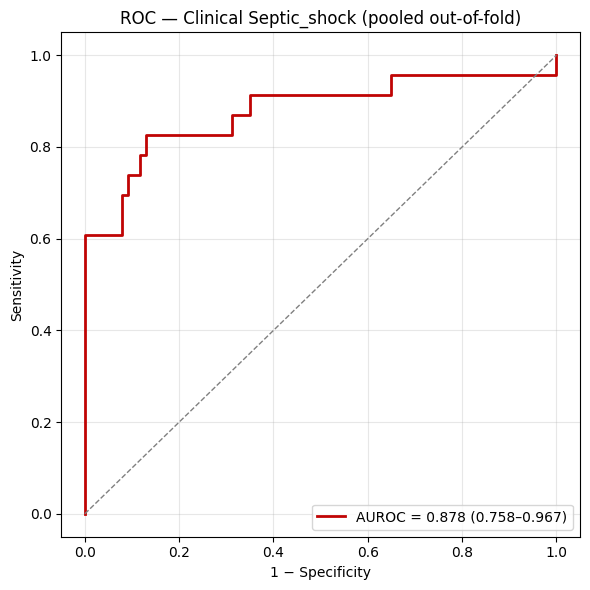

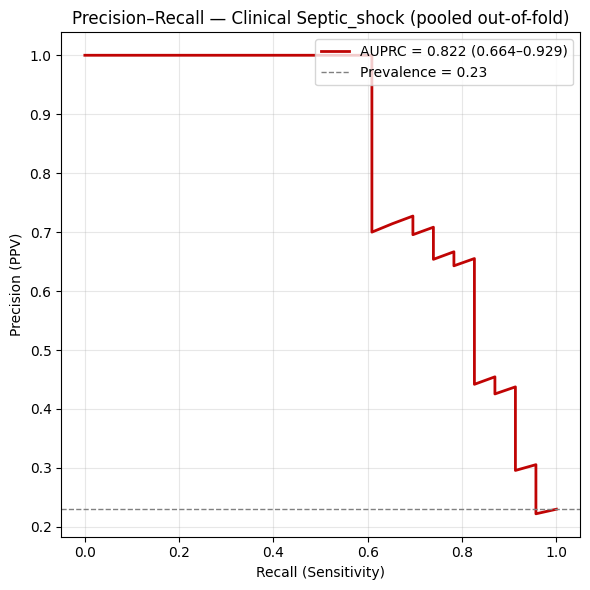

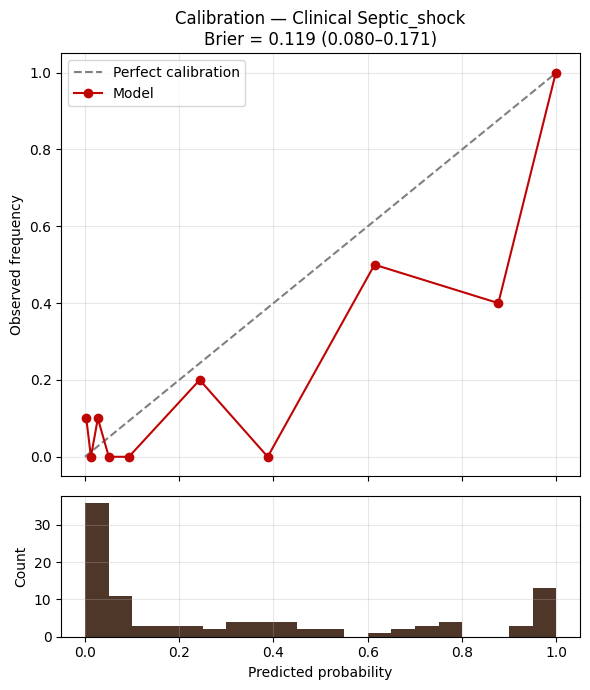

In [ ]:
# 8. FIGURES  (all driven by the same pooled-OOF arrays + bootstrap CIs)
auroc_pt, auroc_lo, auroc_hi = boot_ci["AUROC"]
prauc_pt, prauc_lo, prauc_hi = boot_ci["AUPRC"]
brier_pt, brier_lo, brier_hi = boot_ci["Brier"]
prevalence = y_true_all.mean()

# --- 8a. ROC (label = same value as the table) -------------------------------
fpr, tpr, _ = roc_curve(y_true_all, y_proba_all)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color=COLOR, lw=2,
         label=f"AUROC = {auroc_pt:.3f} ({auroc_lo:.3f}\u2013{auroc_hi:.3f})")
plt.plot([0, 1], [0, 1], '--', color="gray", lw=1)
plt.xlabel("1 \u2212 Specificity"); plt.ylabel("Sensitivity")
plt.title(f"ROC \u2014 {FEATURE_SET_NAME} {TARGET} (pooled out-of-fold)")
plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"ROC_{FEATURE_SET_NAME}_{TARGET}.png", dpi=300, bbox_inches="tight"); plt.show()

# --- 8b. Precision-Recall (with prevalence baseline) -------------------------
prec, rec, _ = precision_recall_curve(y_true_all, y_proba_all)
plt.figure(figsize=(6, 6))
plt.plot(rec, prec, color=COLOR, lw=2,
         label=f"AUPRC = {prauc_pt:.3f} ({prauc_lo:.3f}\u2013{prauc_hi:.3f})")
plt.axhline(prevalence, ls='--', color="gray", lw=1, label=f"Prevalence = {prevalence:.2f}")
plt.xlabel("Recall (Sensitivity)"); plt.ylabel("Precision (PPV)")
plt.title(f"Precision\u2013Recall \u2014 {FEATURE_SET_NAME} {TARGET} (pooled out-of-fold)")
plt.legend(loc="upper right"); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"PR_{FEATURE_SET_NAME}_{TARGET}.png", dpi=300, bbox_inches="tight"); plt.show()

# --- 8c. Calibration (pooled OOF, not in-sample) + probability histogram ------
prob_true, prob_pred = calibration_curve(y_true_all, y_proba_all, n_bins=10, strategy="quantile")
fig, (a1, a2) = plt.subplots(2, 1, figsize=(6, 7), height_ratios=[3, 1], sharex=True)
a1.plot([0, 1], [0, 1], '--', color="gray", label="Perfect calibration")
a1.plot(prob_pred, prob_true, 'o-', color=COLOR, label="Model")
a1.set_ylabel("Observed frequency"); a1.legend(loc="upper left"); a1.grid(alpha=0.3)
a1.set_title(f"Calibration \u2014 {FEATURE_SET_NAME} {TARGET}\n"
             f"Brier = {brier_pt:.3f} ({brier_lo:.3f}\u2013{brier_hi:.3f})")
a2.hist(y_proba_all, bins=20, color="#4E3629")
a2.set_xlabel("Predicted probability"); a2.set_ylabel("Count"); a2.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"Calibration_{FEATURE_SET_NAME}_{TARGET}.png", dpi=300, bbox_inches="tight"); plt.show()



--- Standardized logistic regression coefficients (Table 4) ---
                Feature  Coefficient (log-odds)  Coef 2.5%  Coef 97.5%  Odds Ratio (per 1 SD)  OR 2.5%  OR 97.5%
Systolic Blood Pressure                  -2.513     -4.304      -0.722                  0.081    0.014     0.486
        SpO2:FiO2 Ratio                  -1.458     -2.357      -0.558                  0.233    0.095     0.572
           Age (months)                   0.895      0.190       1.601                  2.448    1.209     4.959
       Respiratory Rate                   0.621     -0.266       1.509                  1.861    0.766     4.523
     Glasgow Coma Scale                  -0.402     -1.167       0.362                  0.669    0.311     1.436
             Heart Rate                  -0.104     -0.906       0.699                  0.902    0.404     2.012
            Temperature                  -0.100     -0.954       0.755                  0.905    0.385     2.127


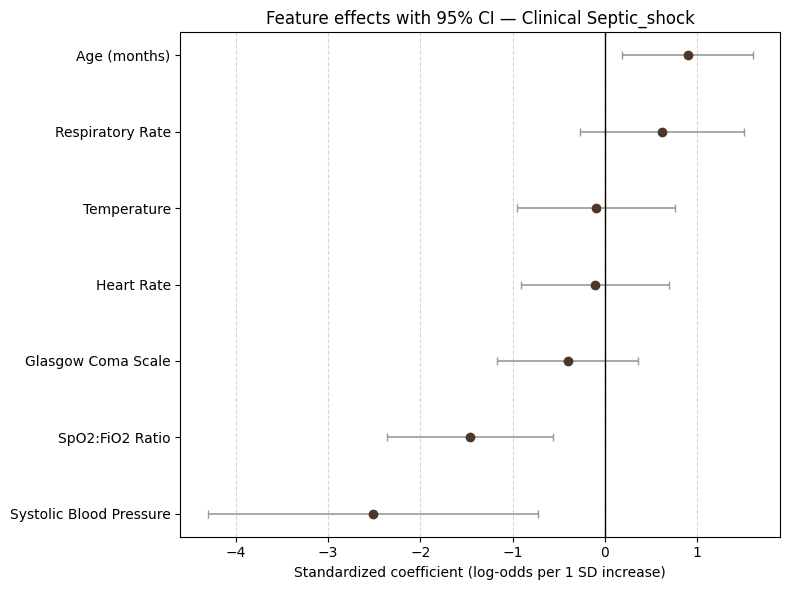


logit(p) = -0.884 + (-1.458 × SpO2:FiO2 Ratio) + (-0.100 × Temperature) + (-0.104 × Heart Rate) + (0.621 × Respiratory Rate) + (-2.513 × Systolic Blood Pressure) + (0.895 × Age (months)) + (-0.402 × Glasgow Coma Scale)


In [ ]:
# 9. Standardized logistic regression: coefficients, ORs, 95% CI  (Table 4)
#    Wald CIs feed BOTH the table and the forest plot (single source of truth).
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
lr_params = best_params_dict.get('Logistic Regression', {})
final_lr = LogisticRegression(**lr_params, class_weight="balanced",
                              max_iter=1000, random_state=RANDOM_STATE).fit(X_std, y)

# Wald covariance for CIs
Xd = np.column_stack([np.ones(X_std.shape[0]), X_std])
p_hat = final_lr.predict_proba(X_std)[:, 1]
W = np.diag(p_hat * (1 - p_hat))
cov = np.linalg.inv(Xd.T @ W @ Xd)
coef = final_lr.coef_[0]
se = np.sqrt(np.diag(cov))[1:]
coef_lo, coef_hi = coef - 1.96 * se, coef + 1.96 * se

coef_df = pd.DataFrame({
    "Feature": [READABLE.get(f, f) for f in FEATURES],
    "Coefficient (log-odds)": coef,
    "Coef 2.5%": coef_lo, "Coef 97.5%": coef_hi,
    "Odds Ratio (per 1 SD)": np.exp(coef),
    "OR 2.5%": np.exp(coef_lo), "OR 97.5%": np.exp(coef_hi),
}).sort_values("Coefficient (log-odds)", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
coef_df_pub = coef_df.round(3)
print("\n--- Standardized logistic regression coefficients (Table 4) ---")
print(coef_df_pub.to_string(index=False))
coef_df_pub.to_csv(f"{FEATURE_SET_NAME}_{TARGET}_logreg_coefficients.csv", index=False)

# --- 9b. Coefficient FOREST plot with 95% CI (C2 fix: no false precision) -----
pdf = coef_df.sort_values("Coefficient (log-odds)").reset_index(drop=True)
plt.figure(figsize=(8, 6))
xerr = [pdf["Coefficient (log-odds)"] - pdf["Coef 2.5%"],
        pdf["Coef 97.5%"] - pdf["Coefficient (log-odds)"]]
plt.errorbar(pdf["Coefficient (log-odds)"], range(len(pdf)), xerr=xerr,
             fmt='o', color="#4E3629", ecolor="#999999", capsize=3, lw=1.2)
plt.axvline(0, color="black", lw=1)
plt.yticks(range(len(pdf)), pdf["Feature"])
plt.xlabel("Standardized coefficient (log-odds per 1 SD increase)")
plt.title(f"Feature effects with 95% CI \u2014 {FEATURE_SET_NAME} {TARGET}")
plt.grid(axis='x', ls='--', alpha=0.5); plt.tight_layout()
plt.savefig(f"Coefficients_{FEATURE_SET_NAME}_{TARGET}.png", dpi=300, bbox_inches="tight"); plt.show()

# --- 9c. Logistic regression equation (Supplemental Table 3) ------------------
intercept = final_lr.intercept_[0]
equation = f"logit(p) = {intercept:.3f} + " + " + ".join(
    f"({c:.3f} \u00D7 {READABLE.get(f, f)})" for c, f in zip(coef, FEATURES))
print("\n" + equation)

In [ ]:

import os

OUTPUT_DIR = "/content/drive/MyDrive/Pediatric Sepsis ML Model/csv"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# 10. Export Results to Google Drive
# ============================================================

cv_results_df.to_csv(
    os.path.join(OUTPUT_DIR,
                 f"{FEATURE_SET_NAME}_{TARGET}_model_comparison.csv"),
    index=False
)

hyperparam_table.to_csv(
    os.path.join(OUTPUT_DIR,
                 f"{FEATURE_SET_NAME}_{TARGET}_hyperparameters.csv"),
    index=False
)

thr_table.to_csv(
    os.path.join(OUTPUT_DIR,
                 f"{FEATURE_SET_NAME}_{TARGET}_fixed_threshold_metrics.csv"),
    index=False
)

cv_results_opt_df.to_csv(
    os.path.join(OUTPUT_DIR,
                 f"{FEATURE_SET_NAME}_{TARGET}_inner_cv_threshold_metrics.csv"),
    index=False
)

pd.DataFrame([
    {"metric": k,
     "point": v[0],
     "lo95": v[1],
     "hi95": v[2]}
    for k, v in boot_ci.items()
]).to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"{FEATURE_SET_NAME}_{TARGET}_bootstrap_CIs.csv"
    ),
    index=False
)

pd.DataFrame([
    {
        "Feature Set": FEATURE_SET_NAME,
        "Outcome": TARGET,
        "Intercept": intercept,
        "Model Specification": equation
    }
]).to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"{FEATURE_SET_NAME}_{TARGET}_equation.csv"
    ),
    index=False
)

print(f"\n✅ Files exported to: {OUTPUT_DIR}")


✅ Files exported to: /content/drive/MyDrive/Pediatric Sepsis ML Model/csv


##Export to Tables

In [ ]:
pip install python-docx

In [ ]:

INPUT_DIR  = "/content/drive/MyDrive/Pediatric Sepsis ML Model/csv"   # where the per-analysis CSVs live

print(f"\nSearching directory: {INPUT_DIR}\n")

files = sorted(os.listdir(INPUT_DIR))

print("Files found:")
for f in files:
    print("  ", f)


Searching directory: /content/drive/MyDrive/Pediatric Sepsis ML Model/csv

Files found:
   Clinical+Lab_Sepsis_bootstrap_CIs.csv
   Clinical+Lab_Sepsis_equation.csv
   Clinical+Lab_Sepsis_fixed_threshold_metrics.csv
   Clinical+Lab_Sepsis_hyperparameters.csv
   Clinical+Lab_Sepsis_inner_cv_threshold_metrics.csv
   Clinical+Lab_Sepsis_logreg_coefficients.csv
   Clinical+Lab_Sepsis_model_comparison.csv
   Clinical+Lab_Septic_shock_bootstrap_CIs.csv
   Clinical+Lab_Septic_shock_equation.csv
   Clinical+Lab_Septic_shock_fixed_threshold_metrics.csv
   Clinical+Lab_Septic_shock_hyperparameters.csv
   Clinical+Lab_Septic_shock_inner_cv_threshold_metrics.csv
   Clinical+Lab_Septic_shock_logreg_coefficients.csv
   Clinical+Lab_Septic_shock_model_comparison.csv
   Clinical_Sepsis_bootstrap_CIs.csv
   Clinical_Sepsis_equation.csv
   Clinical_Sepsis_fixed_threshold_metrics.csv
   Clinical_Sepsis_hyperparameters.csv
   Clinical_Sepsis_inner_cv_threshold_metrics.csv
   Clinical_Sepsis_logreg_coeffi

In [ ]:
for fs, tg, label in COMBOS:
    for suffix in ["hyperparameters", "model_comparison",
                   "fixed_threshold_metrics", "equation"]:
        p = os.path.join(INPUT_DIR, f"{fs}_{tg}_{suffix}.csv")
        print(p, os.path.exists(p))

/content/drive/MyDrive/Pediatric Sepsis ML Model/csv/Clinical+Lab_Sepsis_hyperparameters.csv True
/content/drive/MyDrive/Pediatric Sepsis ML Model/csv/Clinical+Lab_Sepsis_model_comparison.csv True
/content/drive/MyDrive/Pediatric Sepsis ML Model/csv/Clinical+Lab_Sepsis_fixed_threshold_metrics.csv True
/content/drive/MyDrive/Pediatric Sepsis ML Model/csv/Clinical+Lab_Sepsis_equation.csv True
/content/drive/MyDrive/Pediatric Sepsis ML Model/csv/Clinical_Sepsis_hyperparameters.csv True
/content/drive/MyDrive/Pediatric Sepsis ML Model/csv/Clinical_Sepsis_model_comparison.csv True
/content/drive/MyDrive/Pediatric Sepsis ML Model/csv/Clinical_Sepsis_fixed_threshold_metrics.csv True
/content/drive/MyDrive/Pediatric Sepsis ML Model/csv/Clinical_Sepsis_equation.csv True
/content/drive/MyDrive/Pediatric Sepsis ML Model/csv/Clinical+Lab_Septic_shock_hyperparameters.csv True
/content/drive/MyDrive/Pediatric Sepsis ML Model/csv/Clinical+Lab_Septic_shock_model_comparison.csv True
/content/drive/MyDr

In [ ]:
import os, pandas as pd, numpy as np

OUTPUT_DIR = INPUT_DIR
COMBOS = [
    ("Clinical+Lab", "Sepsis", "Clinical+Lab Sepsis"),
    ("Clinical", "Sepsis", "Clinical Sepsis"),
    ("Clinical+Lab", "Septic_shock", "Clinical+Lab Septic Shock"),
    ("Clinical", "Septic_shock", "Clinical Septic Shock"),
]
WRITE_DOCX = True
os.makedirs(OUTPUT_DIR, exist_ok=True)

def _read(fs, tg, suffix):
    p = os.path.join(INPUT_DIR, f"{fs}_{tg}_{suffix}.csv")
    return pd.read_csv(p) if os.path.exists(p) else None

def _fmt_hp(v):
    if pd.isna(v): return None
    if isinstance(v, str): return v
    f = float(v)
    return str(int(f)) if f.is_integer() else f"{f:.4g}"

def collapse_hyperparameters(hp):
    out = []

    keep_cols = [c for c in hp.columns if c in ["Feature Set", "Outcome"]]

    for _, row in hp.iterrows():

        parts = [
            f"{c} = {_fmt_hp(row[c])}"
            for c in hp.columns
            if c not in ["Model", "Feature Set", "Outcome"]
            and not pd.isna(row[c])
        ]

        rec = {
            "Model": row["Model"],
            "Hyperparameters": ", ".join(parts) if parts else "—"
        }

        for c in keep_cols:
            rec[c] = row[c]

        out.append(rec)

    return pd.DataFrame(out)

def stack(suffix, transform=None, label_col="Feature Set"):
    frames = []
    for fs, tg, label in COMBOS:
        d = _read(fs, tg, suffix)
        if d is None:
            print(f"  [skip] missing {fs}_{tg}_{suffix}.csv"); continue
        if transform: d = transform(d)
        if label_col not in d.columns:           # equation files already carry Feature Set/Outcome
            d = d.copy(); d.insert(0, label_col, label)
        frames.append(d)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def blank_repeats(df, col):
    df = df.copy(); prev = None; vals = []
    for v in df[col]:
        vals.append("" if v == prev else v); prev = v
    df[col] = vals; return df

def to_docx(df, title, path):
    try:
        from docx import Document
    except ImportError:
        print("  (python-docx not installed; run: pip install python-docx)"); return
    doc = Document(); doc.add_paragraph(title)
    t = doc.add_table(rows=1, cols=len(df.columns)); t.style = "Light Grid Accent 1"
    for j, c in enumerate(df.columns): t.rows[0].cells[j].text = str(c)
    for _, row in df.iterrows():
        cells = t.add_row().cells
        for j, c in enumerate(df.columns): cells[j].text = "" if pd.isna(row[c]) else str(row[c])
    doc.save(path)

st1  = stack("hyperparameters", transform=collapse_hyperparameters)
st2  = stack("model_comparison")
stft = stack("fixed_threshold_metrics")
st3  = stack("equation")
if not st3.empty and {"Feature Set","Outcome","Model Specification"}.issubset(st3.columns):
    st3 = st3[["Feature Set","Outcome","Model Specification"]]

st1.to_csv(f"{OUTPUT_DIR}/Combined_ST1_hyperparameters.csv", index=False)
st2.to_csv(f"{OUTPUT_DIR}/Combined_ST2_model_comparison.csv", index=False)
stft.to_csv(f"{OUTPUT_DIR}/Combined_fixed_threshold_metrics.csv", index=False)
st3.to_csv(f"{OUTPUT_DIR}/Combined_ST3_equations.csv", index=False)

if WRITE_DOCX:
    to_docx(blank_repeats(st1, "Feature Set"),
            "Supplemental Table 1. Optimized hyperparameters by feature set and outcome.",
            f"{OUTPUT_DIR}/Combined_ST1_hyperparameters.docx")
    to_docx(st2, "Supplemental Table 2. Model performance (patient-level bootstrap 95% CIs, threshold = 0.50).",
            f"{OUTPUT_DIR}/Combined_ST2_model_comparison.docx")
    to_docx(blank_repeats(stft, "Feature Set"),
            "Supplemental Table. Fixed-threshold performance (out-of-fold, bootstrap 95% CIs).",
            f"{OUTPUT_DIR}/Combined_fixed_threshold_metrics.docx")
    to_docx(st3, "Supplemental Table 3. Logistic regression specifications (standardized predictors).",
            f"{OUTPUT_DIR}/Combined_ST3_equations.docx")
print("Done.")

Done.
